In [1]:
%%time
import polars as pl

with open("../data/BatchSystemOutcomes.txt", "r") as f:
    outcome_cols = [line.strip().strip("'").strip('"') for line in f if line.strip()]

print(f"Loaded {len(outcome_cols)} columns from file.")

path = "../data/processed_job_data_0[1-6].parquet"
job_data = pl.scan_parquet(path)
outcome_df = job_data.select(outcome_cols).collect()
print(outcome_df.shape) 

Loaded 8 columns from file.
(41079913, 8)
CPU times: user 827 ms, sys: 621 ms, total: 1.45 s
Wall time: 237 ms


In [10]:
outcome_df.head()[4]["LastHoldReason"][0]

'Error from slot1_18@fnpc9028.fnal.gov: Docker job has gone over memory limit of 5990 Mb'

In [11]:
outcome_df.head()[4]["LastHoldReasonCode"][0]

34

In [12]:
with pl.Config(set_tbl_rows=-1):
    print(outcome_df["LastHoldReasonCode"].unique().sort())

shape: (12,)
Series: 'LastHoldReasonCode' [i64]
[
	null
	1
	3
	4
	6
	7
	12
	16
	26
	33
	34
	35
]


In [109]:
with pl.Config(fmt_str_lengths=500, set_tbl_rows=100):
    print(outcome_df.filter(pl.col("LastHoldReasonCode") == 35)
                    .select("LastHoldReason").unique())

shape: (9_067, 1)
┌──────────────────────────────────────────────────────────────────────────────────────────────────┐
│ LastHoldReason                                                                                   │
│ ---                                                                                              │
│ str                                                                                              │
╞══════════════════════════════════════════════════════════════════════════════════════════════════╡
│ Error from slot1_37@fnpc22027.fnal.gov:                                                          │
│ Error from slot1_19@fnpc7536.fnal.gov:                                                           │
│ Error from slot1_42@fnpc19142.fnal.gov:                                                          │
│ Error from slot1_53@fnpc23101.fnal.gov: Error response from daemon: Requested CPUs are not       │
│ available - requested 64,65,67,70,88,90,91,92, available: 0-63,65-127  

In [14]:
with pl.Config(fmt_str_lengths=400, set_tbl_rows=100):
    print(outcome_df.filter(pl.col("LastHoldReasonCode") == 6).filter(pl.col("ExitCode") == 1).select("LastHoldReason"))

shape: (1, 1)
┌──────────────────────────────────────────────────────────────────────────────────────────────────┐
│ LastHoldReason                                                                                   │
│ ---                                                                                              │
│ str                                                                                              │
╞══════════════════════════════════════════════════════════════════════════════════════════════════╡
│ Error from slot1_12@fnpc17102.fnal.gov: Error running docker job: failed to create task for      │
│ container: failed to create shim task: OCI runtime create failed: runc create failed: unable to  │
│ start container process: unable to apply cgroup configuration: unable to start unit              │
│ 'docker-24e18652cd89a3f9659b35a33bc23b294d7ecfb42d7bdc7184d0778a694d9c57.scope' (properties      │
│ [{Name:Description Value:'libcontain…                                      

In [23]:
with pl.Config(fmt_str_lengths=800, set_tbl_rows=100):
    print(outcome_df.filter(pl.col("LastHoldReasonCode") == 6).filter(pl.col("ExitSignal") == 122).select("LastHoldReason"))

shape: (1, 1)
┌──────────────────────────────────────────────────────────────────────────────────────────────────┐
│ LastHoldReason                                                                                   │
│ ---                                                                                              │
│ str                                                                                              │
╞══════════════════════════════════════════════════════════════════════════════════════════════════╡
│ Error from slot1_43@fnpc9033.fnal.gov: Error running docker job: failed to create shim task: OCI │
│ runtime create failed: runc create failed: unable to start container process: error during       │
│ container init: error mounting '/etc/docker.group' to rootfs at '/etc/group': change mount       │
│ propagation through procfd: possibly malicious path detected -- refusing to operate on /storage/ │
│ local/data1/docker/overlay2/87e8e091eaaab0e09a24f59720ec6e83cb1108bc0955607

### LastHoldReason --> ExitCode outcome distribution

In [4]:
xtab = (outcome_df
  .with_columns(
      pl.when(pl.col("ExitCode").is_null()).then(pl.lit("no exit code"))
        .otherwise(pl.col("ExitCode").cast(pl.Utf8))
        .alias("exit_bucket")
  )
  .group_by("LastHoldReasonCode", "exit_bucket")
  .len()
  .sort(["LastHoldReasonCode", "len"], descending=[False, True]))

with pl.Config(set_tbl_rows=-1):
    print(xtab)

shape: (212, 3)
┌────────────────────┬──────────────┬──────────┐
│ LastHoldReasonCode ┆ exit_bucket  ┆ len      │
│ ---                ┆ ---          ┆ ---      │
│ i64                ┆ str          ┆ u32      │
╞════════════════════╪══════════════╪══════════╡
│ null               ┆ 0            ┆ 15209364 │
│ null               ┆ 1            ┆ 1275408  │
│ null               ┆ no exit code ┆ 299542   │
│ null               ┆ 21           ┆ 282105   │
│ null               ┆ 20           ┆ 258608   │
│ null               ┆ 2            ┆ 100860   │
│ null               ┆ 127          ┆ 28085    │
│ null               ┆ 90           ┆ 25797    │
│ null               ┆ 124          ┆ 24810    │
│ null               ┆ 88           ┆ 14599    │
│ null               ┆ 139          ┆ 10052    │
│ null               ┆ 89           ┆ 10025    │
│ null               ┆ 24           ┆ 7077     │
│ null               ┆ 112          ┆ 4311     │
│ null               ┆ 65           ┆ 3752     │
│ nu

shape: (12, 5)
┌────────────────────┬──────────┬──────────┬──────────┬──────────┐
│ LastHoldReasonCode ┆ n_jobs   ┆ none     ┆ zero     ┆ nonzero  │
│ ---                ┆ ---      ┆ ---      ┆ ---      ┆ ---      │
│ i64                ┆ u32      ┆ f64      ┆ f64      ┆ f64      │
╞════════════════════╪══════════╪══════════╪══════════╪══════════╡
│ 16                 ┆ 20925783 ┆ 0.06569  ┆ 0.83458  ┆ 0.099731 │
│ null               ┆ 17574544 ┆ 0.017044 ┆ 0.86542  ┆ 0.117536 │
│ 26                 ┆ 1154966  ┆ 0.802309 ┆ 0.127965 ┆ 0.069726 │
│ 34                 ┆ 807566   ┆ 0.444556 ┆ 0.534261 ┆ 0.021183 │
│ 35                 ┆ 300517   ┆ 0.409165 ┆ 0.548887 ┆ 0.041948 │
│ …                  ┆ …        ┆ …        ┆ …        ┆ …        │
│ 3                  ┆ 18144    ┆ 0.948633 ┆ 0.047288 ┆ 0.004078 │
│ 4                  ┆ 872      ┆ 0.988532 ┆ 0.010321 ┆ 0.001147 │
│ 6                  ┆ 37       ┆ 0.27027  ┆ 0.675676 ┆ 0.054054 │
│ 33                 ┆ 7        ┆ 0.571429 ┆ 0.

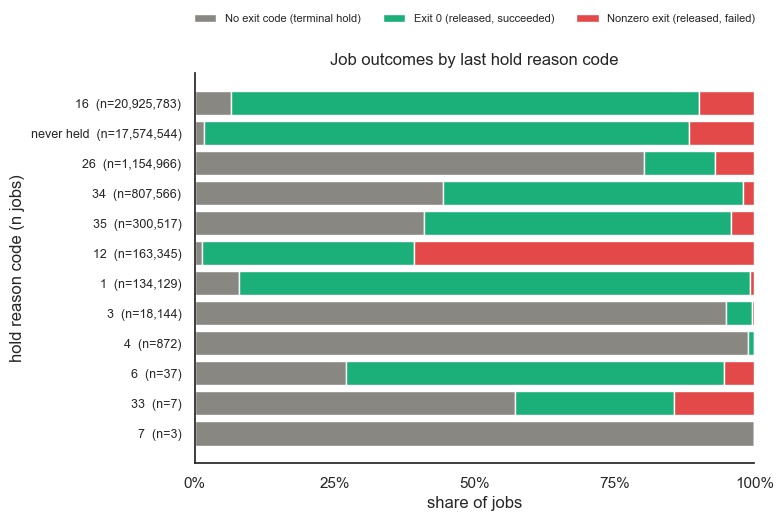

In [5]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

# three-way exit bucket per job
buckets = outcome_df.with_columns(
    pl.when(pl.col("ExitCode").is_null()).then(pl.lit("none"))
      .when(pl.col("ExitCode") == 0).then(pl.lit("zero"))
      .otherwise(pl.lit("nonzero"))
      .alias("exit_bucket")
)

summary = (buckets
    .group_by("LastHoldReasonCode")
    .agg(
        pl.len().alias("n_jobs"),
        (pl.col("exit_bucket") == "none").mean().alias("none"),
        (pl.col("exit_bucket") == "zero").mean().alias("zero"),
        (pl.col("exit_bucket") == "nonzero").mean().alias("nonzero"),
    )
    .sort("n_jobs", descending=True)
)

print(summary)

# plot
labels = [
    f"{c if c is not None else 'never held'}  (n={n:,})"
    for c, n in zip(summary["LastHoldReasonCode"].to_list(),
                    summary["n_jobs"].to_list())
]
none    = np.array(summary["none"].to_list())
zero    = np.array(summary["zero"].to_list())
nonzero = np.array(summary["nonzero"].to_list())

fig, ax = plt.subplots(figsize=(8, 0.45 * len(labels)))
y = np.arange(len(labels))

ax.barh(y, none,    color="#898781", label="No exit code (terminal hold)")
ax.barh(y, zero,    left=none, color="#1baf7a", label="Exit 0 (released, succeeded)")
ax.barh(y, nonzero, left=none + zero, color="#e34948", label="Nonzero exit (released, failed)")

ax.set_yticks(y, labels, fontsize=9)
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.set_xticks(np.arange(0, 1.01, 0.25),
              [f"{int(v*100)}%" for v in np.arange(0, 1.01, 0.25)])
ax.set_xlabel("share of jobs")
ax.set_ylabel ("hold reason code (n jobs)")
ax.set_title("Job outcomes by last hold reason code", fontsize=12)
ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.1),
    ncol=4,
    fontsize=8,
    frameon=False,
)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

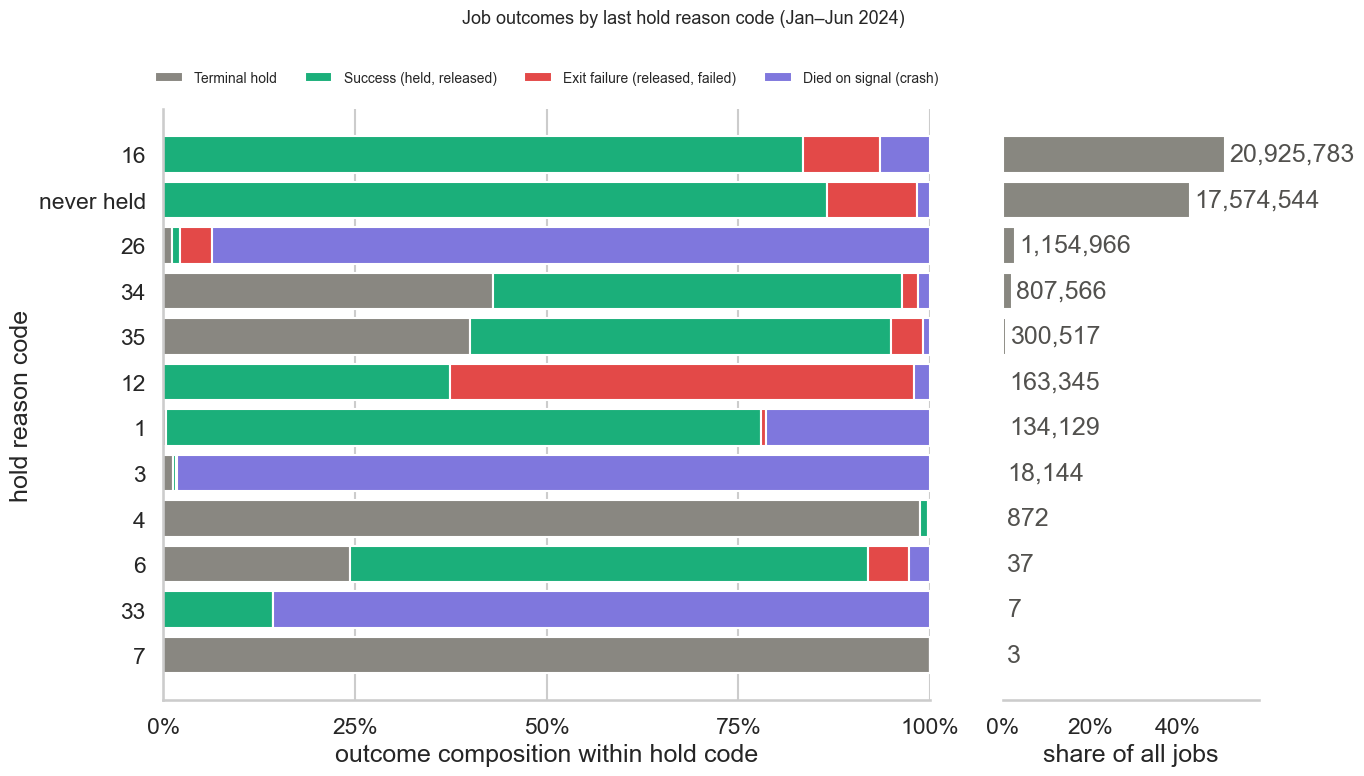

In [14]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", context="talk")

# four-way outcome bucket per job
buckets = outcome_df.with_columns(
    pl.when(pl.col("ExitSignal").is_not_null()).then(pl.lit("signal"))
      .when(pl.col("ExitCode").is_null()).then(pl.lit("none"))
      .when(pl.col("ExitCode") == 0).then(pl.lit("zero"))
      .otherwise(pl.lit("nonzero"))
      .alias("exit_bucket")
)

summary = (buckets
    .group_by("LastHoldReasonCode")
    .agg(
        pl.len().alias("n_jobs"),
        (pl.col("exit_bucket") == "none").mean().alias("none"),
        (pl.col("exit_bucket") == "zero").mean().alias("zero"),
        (pl.col("exit_bucket") == "nonzero").mean().alias("nonzero"),
        (pl.col("exit_bucket") == "signal").mean().alias("signal"),
    )
    .sort("n_jobs", descending=True)
)

total_jobs = summary["n_jobs"].sum()

labels = [
    f"{c if c is not None else 'never held'}"
    for c in summary["LastHoldReasonCode"].to_list()
]
n_jobs  = np.array(summary["n_jobs"].to_list())
none    = np.array(summary["none"].to_list())
zero    = np.array(summary["zero"].to_list())
nonzero = np.array(summary["nonzero"].to_list())
signal  = np.array(summary["signal"].to_list())
share   = n_jobs / total_jobs

y = np.arange(len(labels))

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(14, 0.5 * len(labels) + 2),
    sharey=True, gridspec_kw={"width_ratios": [3, 1]}
)

# ---- left: outcome composition within each hold code -------------------
pal = {"none": "#898781", "zero": "#1baf7a", "nonzero": "#e34948", "signal": "#7f77dd"}

ax1.barh(y, none,    color=pal["none"],    label="Terminal hold")
ax1.barh(y, zero,    left=none, color=pal["zero"],    label="Success (held, released)")
ax1.barh(y, nonzero, left=none + zero, color=pal["nonzero"], label="Exit failure (released, failed)")
ax1.barh(y, signal,  left=none + zero + nonzero, color=pal["signal"], label="Died on signal (crash)")

ax1.set_xlim(0, 1)
ax1.set_xticks(np.arange(0, 1.01, 0.25))
ax1.set_xticklabels([f"{int(v*100)}%" for v in np.arange(0, 1.01, 0.25)])
ax1.set_xlabel("outcome composition within hold code")
ax1.set_ylabel("hold reason code")
ax1.set_yticks(y)
ax1.set_yticklabels(labels)
ax1.invert_yaxis()
ax1.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02),
           ncol=4, fontsize=10, frameon=False)

# ---- right: share of all jobs accounted for by each hold code -----------
ax2.barh(y, share, color="#888780")
ax2.set_xlabel("share of all jobs")
ax2.set_xlim(0, max(share) * 1.15)
ax2.xaxis.set_major_formatter(lambda v, _: f"{v*100:.0f}%")

for yi, (s, n) in enumerate(zip(share, n_jobs)):
    ax2.text(s + max(share) * 0.02, yi, f"{n:,}",
             va="center", color="#52514e")

sns.despine(ax=ax1)
sns.despine(ax=ax2, left=True)
ax2.grid(axis="x", visible=False)
ax2.grid(axis="y", visible=False)

fig.suptitle("Job outcomes by last hold reason code (Jan–Jun 2024)",
             fontsize=13)
plt.tight_layout()
plt.show()

#### Around half of all jobs are held at some point in their lifecycle (23.5 million out of 41 million)

In [16]:
outcome_df.filter(pl.col("LastHoldReasonCode").is_not_null())

CompletionDate_ms,DAG_NodesTotal,ExitCode,ExitSignal,JobStatus,LastHoldReason,LastHoldReasonCode,RemoveReason
i64,str,i64,i64,i64,str,i64,str
1704103465000,null,0,null,4,"""Error from slot1_18@fnpc9028.f…",34,null
1704103466000,null,1,null,4,"""Spooling input data files""",16,null
1704103473000,null,1,null,4,"""Spooling input data files""",16,null
1704103499000,null,1,null,4,"""Spooling input data files""",16,null
1704103343000,null,0,null,4,"""Error from slot1_2@fnpc19140.f…",34,null
…,…,…,…,…,…,…,…
1719791976000,null,1,null,4,"""Spooling input data files""",16,null
1719791954000,null,1,null,4,"""Spooling input data files""",16,null
1719791957000,null,1,null,4,"""Spooling input data files""",16,null


#### There are a significant number of jobs that fail without LastHoldReasons (2.1 million out of 7.6 million)

In [17]:
failures = outcome_df.filter((pl.col("ExitCode") != 0) | (pl.col("ExitSignal").is_not_null()) | (pl.col("JobStatus") == 3))
print("Total failures:", failures.shape[0])

Total failures: 7676794


In [18]:
failures.filter(pl.col("LastHoldReasonCode").is_null())

CompletionDate_ms,DAG_NodesTotal,ExitCode,ExitSignal,JobStatus,LastHoldReason,LastHoldReasonCode,RemoveReason
i64,str,i64,i64,i64,str,i64,str
1704103100000,null,1,null,4,null,null,null
1704095206000,null,1,null,4,null,null,null
1704097125000,null,204,null,4,null,null,null
1704107912000,null,1,null,4,null,null,null
1704108108000,null,1,null,4,null,null,null
…,…,…,…,…,…,…,…
1719768957000,null,1,null,4,null,null,null
1719786004000,null,1,null,4,null,null,null
1719786001000,null,1,null,4,null,null,null


#### However, the majority of jobs that fail have LastHoldReasons (4 million out of 7.6 million total failures)

In [19]:
failures.filter(pl.col("LastHoldReasonCode").is_not_null())

CompletionDate_ms,DAG_NodesTotal,ExitCode,ExitSignal,JobStatus,LastHoldReason,LastHoldReasonCode,RemoveReason
i64,str,i64,i64,i64,str,i64,str
1704103466000,null,1,null,4,"""Spooling input data files""",16,null
1704103473000,null,1,null,4,"""Spooling input data files""",16,null
1704103499000,null,1,null,4,"""Spooling input data files""",16,null
1704103381000,null,1,null,4,"""Spooling input data files""",16,null
0,null,null,null,3,"""Error from slot1_18@fnpc17135.…",34,"""via condor_rm (by user uboonep…"
…,…,…,…,…,…,…,…
1719791976000,null,1,null,4,"""Spooling input data files""",16,null
1719791954000,null,1,null,4,"""Spooling input data files""",16,null
1719791957000,null,1,null,4,"""Spooling input data files""",16,null


#### But the term "failure" includes removed jobs, so the number of jobs with non-zero exit codes or non-null exit signals is actually around half (3.4 million out of 7.6 million)

In [20]:
failures.filter(pl.col("JobStatus") == 4).filter(pl.col("LastHoldReasonCode").is_not_null())

CompletionDate_ms,DAG_NodesTotal,ExitCode,ExitSignal,JobStatus,LastHoldReason,LastHoldReasonCode,RemoveReason
i64,str,i64,i64,i64,str,i64,str
1704103466000,null,1,null,4,"""Spooling input data files""",16,null
1704103473000,null,1,null,4,"""Spooling input data files""",16,null
1704103499000,null,1,null,4,"""Spooling input data files""",16,null
1704103381000,null,1,null,4,"""Spooling input data files""",16,null
1704103274000,null,1,null,4,"""Spooling input data files""",16,null
…,…,…,…,…,…,…,…
1719791976000,null,1,null,4,"""Spooling input data files""",16,null
1719791954000,null,1,null,4,"""Spooling input data files""",16,null
1719791957000,null,1,null,4,"""Spooling input data files""",16,null


#### Most of the LastHoldReasonCodes actually point to jobs that recover (exit cleanly)
- 18.3 million (successful jobs with LastHoldReasons) out of 23.5 million (jobs with LastHoldReasons)

In [22]:
outcome_df.filter(pl.col("LastHoldReasonCode") > 0).filter(pl.col("ExitCode") == 0)

CompletionDate_ms,DAG_NodesTotal,ExitCode,ExitSignal,JobStatus,LastHoldReason,LastHoldReasonCode,RemoveReason
i64,str,i64,i64,i64,str,i64,str
1704103465000,null,0,null,4,"""Error from slot1_18@fnpc9028.f…",34,null
1704103343000,null,0,null,4,"""Error from slot1_2@fnpc19140.f…",34,null
1704103348000,null,0,null,4,"""Spooling input data files""",16,null
1704103383000,null,0,null,4,"""Error from slot1_5@fnpc22009.f…",34,null
1704103385000,null,0,null,4,"""Error from slot1_18@fnpc17146.…",34,null
…,…,…,…,…,…,…,…
1719791815000,null,0,null,4,"""Spooling input data files""",16,null
1719791757000,null,0,null,4,"""Spooling input data files""",16,null
1719791753000,null,0,null,4,"""Spooling input data files""",16,null


#### Is hold code redundant with outcome? 
- Low entropy = code determines the outcome
- High entropy = the code tells you nothing

In [13]:
import polars as pl
import numpy as np
from scipy.stats import chi2_contingency

ct = (buckets
    .group_by(["LastHoldReasonCode", "exit_bucket"])
    .len()
    .pivot(values="len", index="LastHoldReasonCode",
           on="exit_bucket", aggregate_function="sum")
    .fill_null(0))

M = ct.drop("LastHoldReasonCode").to_numpy()
chi2, p, dof, _ = chi2_contingency(M)
n = M.sum()
cramers_v = np.sqrt(chi2 / (n * (min(M.shape) - 1)))
print(f"Cramér's V = {cramers_v:.3f}   (0 = independent, 1 = redundant)")

# per-code: how concentrated is its outcome distribution? (normalized entropy)
P = M / M.sum(axis=1, keepdims=True)
ent = -(np.where(P > 0, P * np.log(P), 0)).sum(axis=1) / np.log(M.shape[1])
for code, e, tot in zip(ct["LastHoldReasonCode"].to_list(), ent, M.sum(axis=1)):
    print(f"code {str(code):>10}  n={tot:>9,}  outcome entropy={e:.3f}")

Cramér's V = 0.388   (0 = independent, 1 = redundant)
code          1  n=  134,129  outcome entropy=0.297
code          4  n=      872  outcome entropy=0.060
code         33  n=        7  outcome entropy=0.870
code          7  n=        3  outcome entropy=-0.000
code         26  n=1,154,966  outcome entropy=0.569
code         16  n=20,925,783  outcome entropy=0.509
code         35  n=  300,517  outcome entropy=0.754
code          6  n=       37  outcome entropy=0.707
code          0  n=17,574,544  outcome entropy=0.406
code         12  n=  163,345  outcome entropy=0.663
code         34  n=  807,566  outcome entropy=0.707
code          3  n=   18,144  outcome entropy=0.197


/var/folders/cf/4gvf1xvn2d5d2txbc84b_0880000gn/T/ipykernel_7485/1541736213.py:20: RuntimeWarning: divide by zero encountered in log
  ent = -(np.where(P > 0, P * np.log(P), 0)).sum(axis=1) / np.log(M.shape[1])
/var/folders/cf/4gvf1xvn2d5d2txbc84b_0880000gn/T/ipykernel_7485/1541736213.py:20: RuntimeWarning: invalid value encountered in multiply
  ent = -(np.where(P > 0, P * np.log(P), 0)).sum(axis=1) / np.log(M.shape[1])


### Cramer's V

The percentage % is the row-normalized composition: of all jobs with hold code Y, what share ended in outcome X. Code 3 → 98% signal crash just says "almost all code-3 jobs died on a signal."

The residual (color) is $\frac {(observed − expected)}{\sqrt expected}$, where "expected" is the count you'd see if hold code and outcome were completely independent — i.e. if every code had the same outcome mix as the dataset overall.

**Red** (positive residual) = this outcome happens more than chance would predict for this code. The code is enriched for that outcome.

**Blue** (negative residual) = this outcome happens less than chance predicts. The code is depleted of it.

**White** (≈0) = the code behaves like the dataset average for this outcome — tells you nothing.

/var/folders/cf/4gvf1xvn2d5d2txbc84b_0880000gn/T/ipykernel_7485/3971130122.py:42: RuntimeWarning: divide by zero encountered in log
  ent = -(np.where(P > 0, P * np.log(P), 0)).sum(axis=1) / np.log(len(cats))
/var/folders/cf/4gvf1xvn2d5d2txbc84b_0880000gn/T/ipykernel_7485/3971130122.py:42: RuntimeWarning: invalid value encountered in multiply
  ent = -(np.where(P > 0, P * np.log(P), 0)).sum(axis=1) / np.log(len(cats))


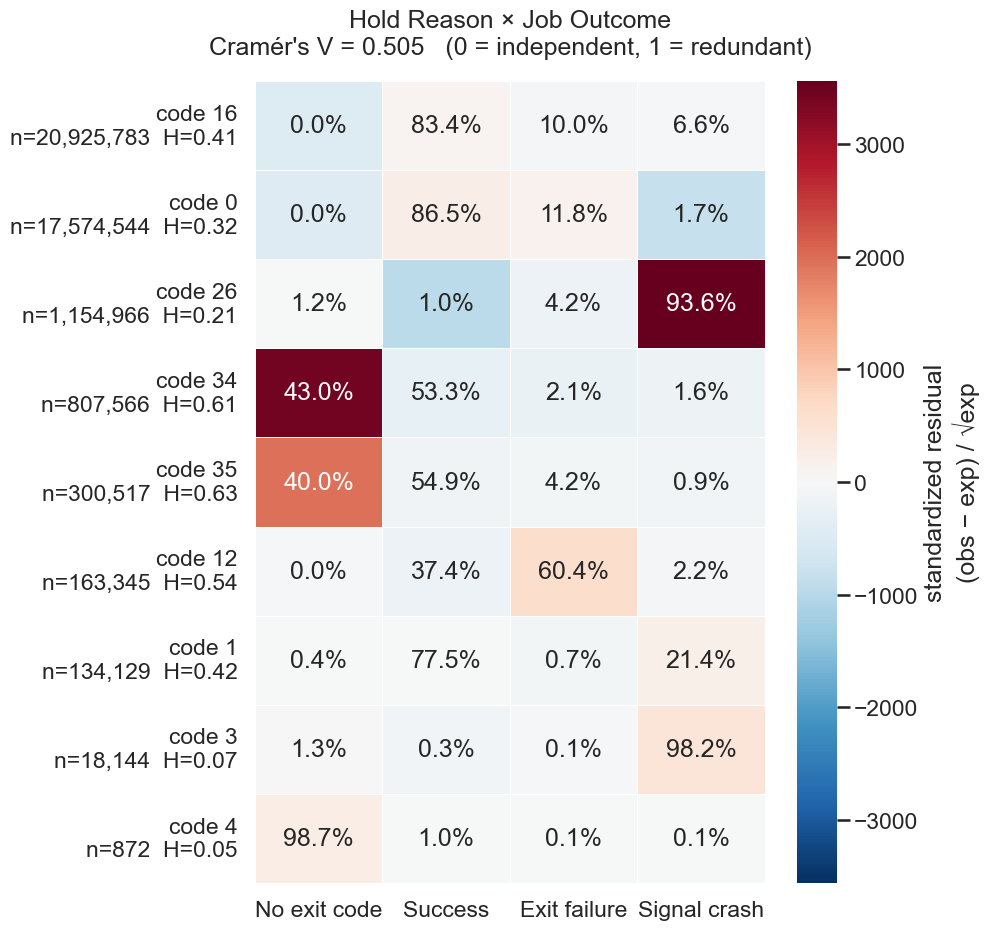

In [30]:
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

sns.set_theme(style="white", context="talk")

ct = (buckets
    .group_by(["LastHoldReasonCode", "exit_bucket"])
    .len()
    .pivot(values="len", index="LastHoldReasonCode",
           on="exit_bucket", aggregate_function="sum")
    .fill_null(0))

codes = ct["LastHoldReasonCode"].to_list()
cats  = [c for c in ["none", "zero", "nonzero", "signal"] if c in ct.columns]
M = ct.select(cats).to_numpy().astype(float)

chi2, p, dof, expected = chi2_contingency(M)
n = M.sum()
V = np.sqrt(chi2 / (n * (min(M.shape) - 1)))

# standardized (Pearson) residuals: (observed - expected) / sqrt(expected)
resid = (M - expected) / np.sqrt(expected)

# --- FILTER OUT ROWS CLOSE TO 0 ---
# Define a threshold. Rows where ALL residuals are between -0.5 and 0.5 will be dropped.
threshold = 20
significant_rows = np.any(np.abs(resid) >= threshold, axis=1)

# Apply the filter mask across all parallel arrays/matrices
M = M[significant_rows]
resid = resid[significant_rows]
expected = expected[significant_rows]
codes = [codes[i] for i, keep in enumerate(significant_rows) if keep]
# ----------------------------------

# normalized entropy + row totals for annotation
P = M / M.sum(axis=1, keepdims=True)
ent = -(np.where(P > 0, P * np.log(P), 0)).sum(axis=1) / np.log(len(cats))
tot = M.sum(axis=1)

# sort by volume, descending
order = np.argsort(-tot)
resid, P, ent, tot = resid[order], P[order], ent[order], tot[order]
codes = [codes[i] for i in order]

labels = [
    f"code {c}\nn={int(t):,}  H={e:.2f}"
    for c, t, e in zip(codes, tot, ent)
]
annot = np.array([[f"{p*100:.1f}%" for p in row] for row in P])

vmax = np.abs(resid).max()
fig, ax = plt.subplots(figsize=(10, 0.85 * len(codes) + 2))

sns.heatmap(
    resid, cmap="RdBu_r", center=0, vmin=-vmax, vmax=vmax,
    annot=annot, fmt="",
    xticklabels=["No exit code", "Success", "Exit failure", "Signal crash"][:len(cats)],
    yticklabels=labels,
    linewidths=0.5, linecolor="white",
    cbar_kws={"label": "standardized residual\n(obs − exp) / √exp"},
    ax=ax,
)

ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="y", rotation=0)
ax.tick_params(axis="x")
ax.set_title(
    f"Hold Reason × Job Outcome\nCramér's V = {V:.3f}   (0 = independent, 1 = redundant)", pad=20,
)
plt.tight_layout()
plt.show()

#### Reading job data

In [5]:
%%time
with open("../data/BatchSystemTrain.txt", "r") as f:
    columns = [line.strip().strip("'").strip('"') for line in f if line.strip()]

print(f"Loaded {len(columns)} columns from file.")
job_data = pl.scan_parquet(path)
job_df = job_data.select(columns).collect()
print(job_df.shape) 

Loaded 30 columns from file.
(41079913, 30)
CPU times: user 3.25 s, sys: 2.61 s, total: 5.86 s
Wall time: 694 ms


In [7]:
job_df.head()

Group,ClusterId,CpusProvisioned,DiskProvisioned,ExecutableSize,JOB_EXPECTED_MAX_LIFETIME,JobCurrentStartExecutingDate_ms,JobCurrentWaitTime,JobPrio,JobUniverse,MATCH_EXP_JOB_GLIDEIN_Site,MemoryProvisioned,MinCores,MinHosts,Owner,POMS_LAUNCHER,POMS_TASK_ID,POMS4_CAMPAIGN_ID,POMS4_CAMPAIGN_NAME,POMS4_CAMPAIGN_STAGE_ID,POMS4_CAMPAIGN_STAGE_NAME,ProcId,QDate_ms,RequestCpus,RequestDisk,Requestioslots,RequestMemory,RequestSlots,TotalSubmitProcs,TransferInputSizeMB
str,i64,str,str,i64,i64,i64,i64,i64,i64,str,str,str,i64,str,str,i64,str,str,str,str,i64,i64,i64,i64,str,i64,i64,str,i64
"""group_uboone""",7126611,"""1""","""36607673""",15,86400,1704102734000,246,0,5,"""FermiGrid""","""2000""",null,1,"""uboonepro""","""pgreen""",1688108,"""7864""","""prod_numi_extunbiased_nu_overl…","""19197""","""wiremod_x""",0,1704102488000,1,31457280,null,2000,1,"""1""",0
"""group_uboone""",75269579,"""1""","""36604362""",15,43200,1704102014000,72,0,5,"""FermiGrid""","""3500""",null,1,"""uboonepro""","""mguzzo""",1688106,"""7879""","""prod_numi_wirecell_run4_fhc_mg…","""19253""","""ly_down""",0,1704101942000,1,31457280,null,3500,1,"""1""",0
"""group_uboone""",7126606,"""1""","""34787476""",15,86400,1704102740000,252,0,5,"""FermiGrid""","""2000""",null,1,"""uboonepro""","""pgreen""",1688108,"""7864""","""prod_numi_extunbiased_nu_overl…","""19197""","""wiremod_x""",0,1704102488000,1,31457280,null,2000,1,"""1""",0
"""group_uboone""",7126447,"""1""","""35124245""",15,86400,1704102630000,160,0,5,"""FermiGrid""","""2000""",null,1,"""uboonepro""","""pgreen""",1688108,"""7864""","""prod_numi_extunbiased_nu_overl…","""19197""","""wiremod_x""",0,1704102470000,1,31457280,null,2000,1,"""1""",0
"""group_icarus""",66506724,"""1""","""21209214""",75,43200,1704103406000,5833,0,5,"""FermiGrid""","""9990""",null,1,"""icaruspro""","""icaruspro""",1688063,"""7404""","""icarus_keepup_production_Offbe…","""18311""","""stage1_caf_larcv_auto""",0,1704097573000,1,20971520,null,2000,1,"""1""",0


In [12]:
wait_by_group = (job_df
    .group_by("Group")
    .agg(
        (pl.col("JobCurrentWaitTime").mean() / 60).alias("mean_min"),
        (pl.col("JobCurrentWaitTime").median() / 60).alias("median_min"),
        pl.len().alias("n"),
    )
    .sort("mean_min", descending=True))
print(wait_by_group)

shape: (26, 4)
┌────────────────┬─────────────┬────────────┬─────────┐
│ Group          ┆ mean_min    ┆ median_min ┆ n       │
│ ---            ┆ ---         ┆ ---        ┆ ---     │
│ str            ┆ f64         ┆ f64        ┆ u32     │
╞════════════════╪═════════════╪════════════╪═════════╡
│ group_des_ncsa ┆ 3466.932003 ┆ 1826.425   ┆ 17336   │
│ group_genie    ┆ 676.796083  ┆ 208.933333 ┆ 60337   │
│ group_accel    ┆ 619.497998  ┆ 74.2       ┆ 216930  │
│ group_mu2e     ┆ 433.253399  ┆ 48.15      ┆ 1774225 │
│ group_sbnd     ┆ 269.743462  ┆ 47.233333  ┆ 1788778 │
│ …              ┆ …           ┆ …          ┆ …       │
│ group_minos    ┆ 15.625598   ┆ 0.383333   ┆ 81962   │
│ group_fermilab ┆ 13.72308    ┆ 0.5        ┆ 2469    │
│ null           ┆ 7.533333    ┆ 0.6        ┆ 29      │
│ group_hypot    ┆ 0.758333    ┆ 0.558333   ┆ 10      │
│ group_next     ┆ 0.394444    ┆ 0.383333   ┆ 3       │
└────────────────┴─────────────┴────────────┴─────────┘


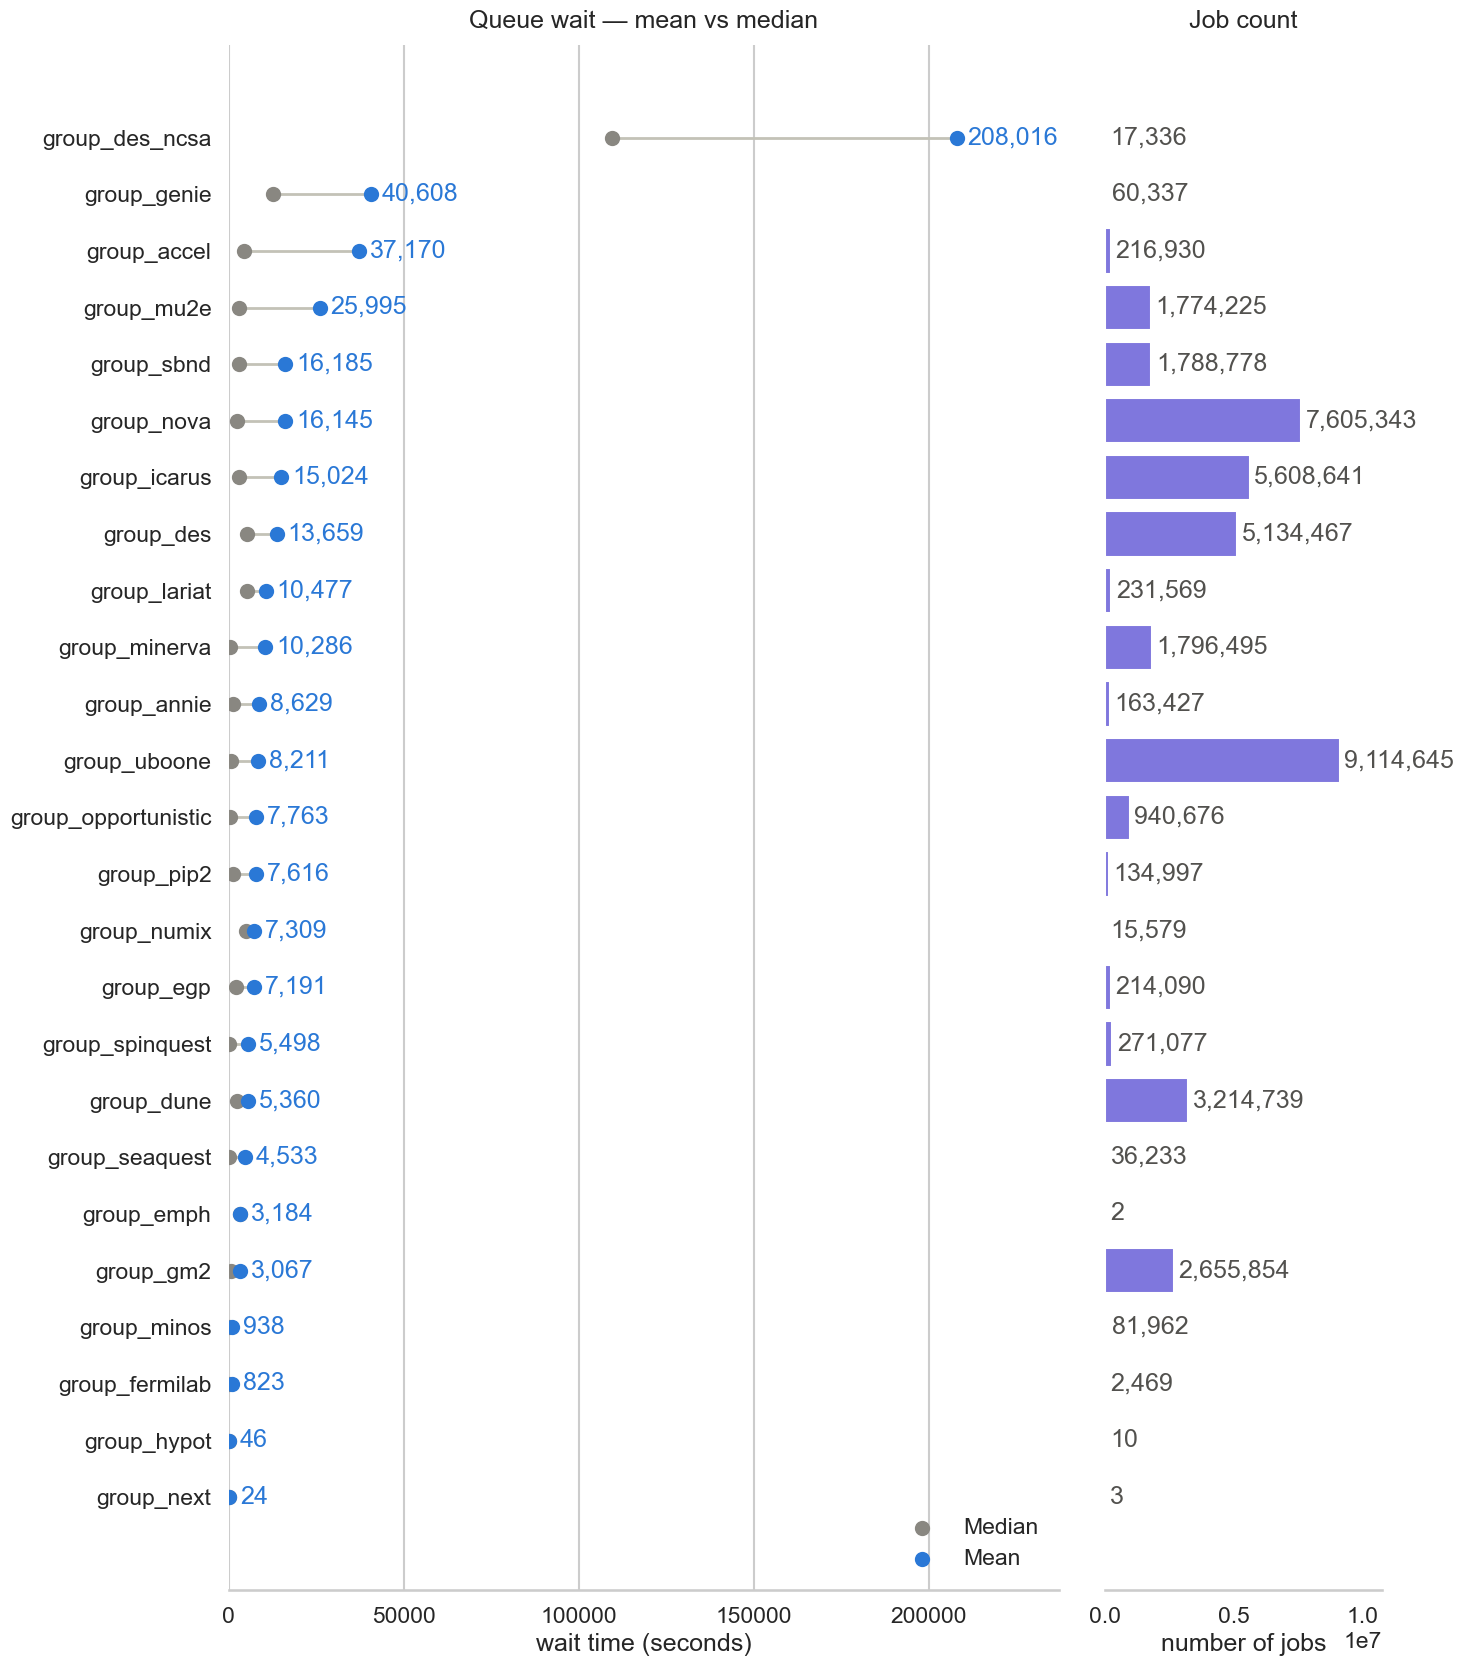

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", context="talk")

clean = (job_df
    .filter(
        pl.col("Group").is_not_null()
        & (pl.col("Group") != "")
#         & (pl.col("Group") != "group_des_ncsa")
        & (pl.col("JobCurrentStartExecutingDate_ms") > 0)   # started => has a real wait
    ))

wait_by_group = (clean
    .group_by("Group")
    .agg(
        pl.col("JobCurrentWaitTime").mean().alias("mean_wait"),
        pl.col("JobCurrentWaitTime").median().alias("median_wait"),
        pl.len().alias("n"),
    )
    .sort("mean_wait", descending=True))

d = wait_by_group.to_pandas()
groups = d["Group"].tolist()
median = d["median_wait"].to_numpy()
mean   = d["mean_wait"].to_numpy()
n      = d["n"].to_numpy()
y = np.arange(len(groups))

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(15, 0.6 * len(groups) + 2),
    sharey=True, gridspec_kw={"width_ratios": [3, 1]})

# --- left: dumbbell (mean vs median wait) -------------------------------
ax1.hlines(y, median, mean, color="#c3c2b7", lw=2, zorder=1)
ax1.scatter(median, y, s=90, color="#898781", zorder=2, label="Median")
ax1.scatter(mean,   y, s=90, color="#2a78d6", zorder=2, label="Mean")
for yi, m in zip(y, mean):
    ax1.text(m + max(mean) * 0.015, yi, f"{m:,.0f}", va="center",
             color="#2a78d6")
ax1.set_yticks(y)
ax1.set_yticklabels(groups)
ax1.invert_yaxis()
ax1.set_xlabel("wait time (seconds)")
ax1.set_xlim(0, max(mean) * 1.14)
ax1.legend(loc="lower right", frameon=False)
ax1.grid(axis="y", visible=False)
sns.despine(ax=ax1, left=True)
ax1.set_title("Queue wait — mean vs median", pad=12)

# --- right: job count per group -----------------------------------------
ax2.barh(y, n, color="#7f77dd")
for yi, c in zip(y, n):
    ax2.text(c + max(n) * 0.02, yi, f"{int(c):,}", va="center",
             color="#52514e")
ax2.set_xlabel("number of jobs")
ax2.set_xlim(0, max(n) * 1.18)
ax2.grid(False)
sns.despine(ax=ax2, left=True)
ax2.set_title("Job count", pad=12)

plt.tight_layout()
plt.show()

In [3]:
job_data_clean = job_df.with_columns([
    pl.col("CpusProvisioned").cast(pl.Int32, strict=False),
    pl.col("DiskProvisioned").cast(pl.Int32, strict=False),
    pl.col("MemoryProvisioned").cast(pl.Int32, strict=False),
    pl.col("TotalSubmitProcs").cast(pl.Int32, strict=False)
])

cols_to_keep = [
    col_name for col_name in job_data_clean.columns
    if job_data_clean.select(pl.col(col_name).n_unique()).item() > 1
]
removed_cols = set(job_data_clean.columns) - set(cols_to_keep)
job_data_clean = job_data_clean.select(cols_to_keep)

print(f"Dropped {len(removed_cols)} columns with only one unique value:")
print(list(removed_cols))

job_data_clean.head()

Dropped 4 columns with only one unique value:
['MinCores', 'Requestioslots', 'MinHosts', 'JobUniverse']


Group,ClusterId,CpusProvisioned,DiskProvisioned,ExecutableSize,JOB_EXPECTED_MAX_LIFETIME,JobCurrentStartExecutingDate_ms,JobCurrentWaitTime,JobPrio,MATCH_EXP_JOB_GLIDEIN_Site,MemoryProvisioned,Owner,POMS_LAUNCHER,POMS_TASK_ID,POMS4_CAMPAIGN_ID,POMS4_CAMPAIGN_NAME,POMS4_CAMPAIGN_STAGE_ID,POMS4_CAMPAIGN_STAGE_NAME,ProcId,QDate_ms,RequestCpus,RequestDisk,RequestMemory,RequestSlots,TotalSubmitProcs,TransferInputSizeMB
str,i64,i32,i32,i64,i64,i64,i64,i64,str,i32,str,str,i64,str,str,str,str,i64,i64,i64,i64,i64,i64,i32,i64
"""group_uboone""",7126611,1,36607673,15,86400,1704102734000,246,0,"""FermiGrid""",2000,"""uboonepro""","""pgreen""",1688108,"""7864""","""prod_numi_extunbiased_nu_overl…","""19197""","""wiremod_x""",0,1704102488000,1,31457280,2000,1,1,0
"""group_uboone""",75269579,1,36604362,15,43200,1704102014000,72,0,"""FermiGrid""",3500,"""uboonepro""","""mguzzo""",1688106,"""7879""","""prod_numi_wirecell_run4_fhc_mg…","""19253""","""ly_down""",0,1704101942000,1,31457280,3500,1,1,0
"""group_uboone""",7126606,1,34787476,15,86400,1704102740000,252,0,"""FermiGrid""",2000,"""uboonepro""","""pgreen""",1688108,"""7864""","""prod_numi_extunbiased_nu_overl…","""19197""","""wiremod_x""",0,1704102488000,1,31457280,2000,1,1,0
"""group_uboone""",7126447,1,35124245,15,86400,1704102630000,160,0,"""FermiGrid""",2000,"""uboonepro""","""pgreen""",1688108,"""7864""","""prod_numi_extunbiased_nu_overl…","""19197""","""wiremod_x""",0,1704102470000,1,31457280,2000,1,1,0
"""group_icarus""",66506724,1,21209214,75,43200,1704103406000,5833,0,"""FermiGrid""",9990,"""icaruspro""","""icaruspro""",1688063,"""7404""","""icarus_keepup_production_Offbe…","""18311""","""stage1_caf_larcv_auto""",0,1704097573000,1,20971520,2000,1,1,0


## Job characteristics vs holds and outcomes

The cells above established that hold codes are far from interchangeable: code 26
(SYSTEM_PERIODIC_HOLD limits) is a 99.3%-certain death sentence, code 3 is always fatal, 34/35
are coin flips, and code 16 (input spooling, 20.9M jobs) fails at 16.6% — barely above the
never-held rate (13.5%), i.e. a routine lifecycle marker rather than a warning sign.

This section asks whether **submission-time job characteristics** explain who ends up in each
bucket:

1. Which resource-request shapes go with which hold code (median fold-change heatmap)?
2. Which experiment groups collect which hold codes (composition heatmap)?
3. Can a model **predict** a problematic hold — and failure — from submission characteristics
   alone? Trained rolling-origin (2-month windows) rather than one big temporal split, per the
   evaluation protocol used across this repo.

shape: (3, 3)
┌───────────────┬──────────┬───────────┐
│ hold_bucket   ┆ n_jobs   ┆ fail_rate │
│ ---           ┆ ---      ┆ ---       │
│ str           ┆ u32      ┆ f64       │
╞═══════════════╪══════════╪═══════════╡
│ spooling_only ┆ 20925783 ┆ 0.16583   │
│ never_held    ┆ 17574544 ┆ 0.1347    │
│ problem_hold  ┆ 2579586  ┆ 0.713049  │
└───────────────┴──────────┴───────────┘


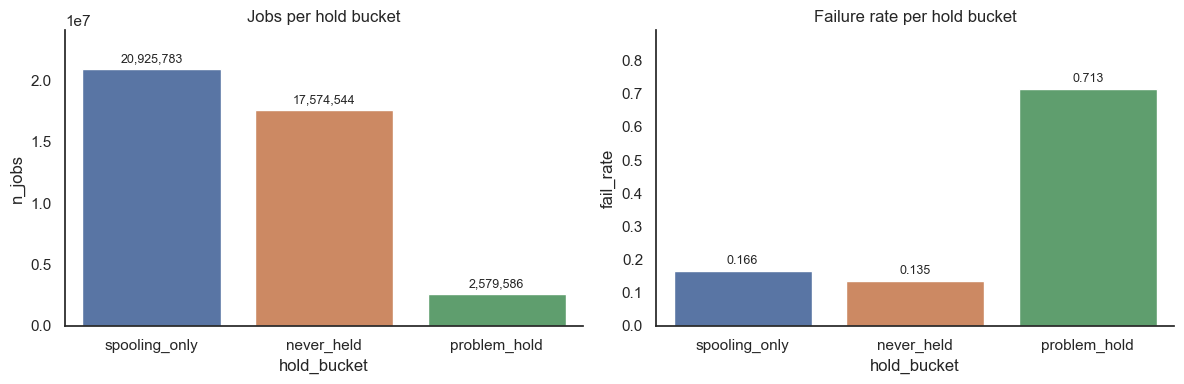

In [4]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="white", context="notebook")

analysis_df = pl.concat([job_data_clean, outcome_df], how="horizontal")
analysis_df = analysis_df.with_columns([
    ((pl.col("ExitCode").is_not_null() & (pl.col("ExitCode") != 0)) |
     pl.col("ExitSignal").is_not_null() | (pl.col("JobStatus") == 3))
    .cast(pl.Int8).alias("Failed"),
    pl.when(pl.col("LastHoldReasonCode").is_null()).then(pl.lit("never_held"))
      .when(pl.col("LastHoldReasonCode") == 16).then(pl.lit("spooling_only"))
      .otherwise(pl.lit("problem_hold")).alias("hold_bucket"),
    pl.from_epoch(pl.col("QDate_ms"), time_unit="ms").dt.month().alias("qmonth"),
])

bstats = (analysis_df.group_by("hold_bucket")
          .agg(pl.len().alias("n_jobs"), pl.col("Failed").mean().alias("fail_rate"))
          .sort("n_jobs", descending=True))
print(bstats)

bp = bstats.to_pandas()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=bp, x="hold_bucket", y="n_jobs", hue="hold_bucket", ax=ax1, legend=False)
for c in ax1.containers:
    ax1.bar_label(c, fmt="{:,.0f}", padding=3, fontsize=9)
ax1.set_ylim(0, bp["n_jobs"].max() * 1.15)
ax1.set_title("Jobs per hold bucket")
sns.barplot(data=bp, x="hold_bucket", y="fail_rate", hue="hold_bucket", ax=ax2, legend=False)
for c in ax2.containers:
    ax2.bar_label(c, fmt="%.3f", padding=3, fontsize=9)
ax2.set_ylim(0, bp["fail_rate"].max() * 1.25)
ax2.set_title("Failure rate per hold bucket")
sns.despine()
plt.tight_layout()
plt.show()

### Which resource-request shapes go with which hold code?

$log_{2}$ fold-change = $\log_{2}(\frac{med(code) + 1}{median(never-held) + 1})$

Ratio against a baseline of jobs that were never held. Median of each submission characteristic per hold code, shown as log2 fold-change relative to never-held jobs (0 = same as never-held; +1 = double; -1 = half).

**Red** = this code's jobs requested/waited more than never-held jobs. 

**Blue** = less. 

**White** = no difference.

            RequestCpus  RequestMemory  RequestDisk  JOB_EXPECTED_MAX_LIFETIME  ExecutableSize  TransferInputSizeMB  TotalSubmitProcs  JobCurrentWaitTime    n_jobs
hold_code                                                                                                                                                          
never_held            1          3,500   31,457,280                     43,200              15                    0                 1               1,935  17574544
code 16               1          3,500   10,485,760                     28,800              15                    0             1,000               1,763  20925783
code 26               1          3,500   20,971,520                     28,800              15                    0               137               3,627   1154966
code 34               1          2,000   20,971,520                     28,800              50                    0                 1              11,764    807566
code 35         

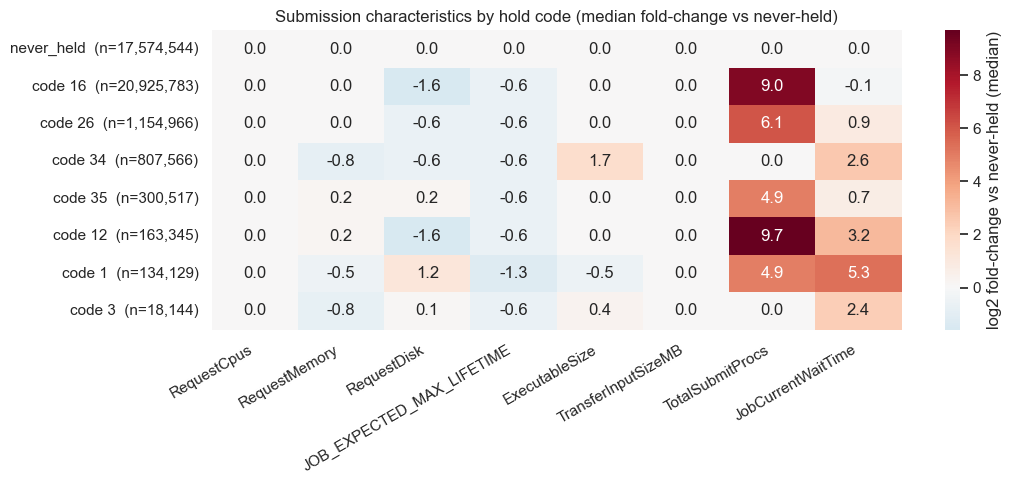

In [40]:
NUM_CHARS = ["RequestCpus", "RequestMemory", "RequestDisk", "JOB_EXPECTED_MAX_LIFETIME",
             "ExecutableSize", "TransferInputSizeMB", "TotalSubmitProcs", "JobCurrentWaitTime"]
TOP_CODES = [16, 26, 34, 35, 12, 1, 3]

hc = (pl.when(pl.col("LastHoldReasonCode").is_null()).then(pl.lit("never_held"))
        .otherwise(pl.lit("code ") + pl.col("LastHoldReasonCode").cast(pl.Utf8)).alias("hold_code"))
med = (analysis_df.with_columns(hc)
       .filter(pl.col("hold_code").is_in(["never_held"] + [f"code {c}" for c in TOP_CODES]))
       .group_by("hold_code")
       .agg([pl.col(c).cast(pl.Float64).median().alias(c) for c in NUM_CHARS] +
            [pl.len().alias("n_jobs")]))
med_pd = med.to_pandas().set_index("hold_code")
order = ["never_held"] + [f"code {c}" for c in TOP_CODES]
med_pd = med_pd.loc[[o for o in order if o in med_pd.index]]
print(med_pd.to_string(float_format=lambda v: f"{v:,.0f}"))

ref = med_pd.loc["never_held", NUM_CHARS].astype(float)
fold = np.log2((med_pd[NUM_CHARS].astype(float) + 1) / (ref + 1))
fold.index = [f"{i}  (n={med_pd.loc[i, 'n_jobs']:,})" for i in fold.index]

plt.figure(figsize=(11, 5))
ax = sns.heatmap(fold, annot=True, fmt=".1f", center=0, cmap="RdBu_r",
                 cbar_kws={"label": "log2 fold-change vs never-held (median)"})
ax.set_title("Submission characteristics by hold code (median fold-change vs never-held)")
ax.set_ylabel("")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### Which groups collect which hold codes?

In [45]:
print("Total groups: ", analysis_df.select("Group").unique().shape[0])

Total groups:  26


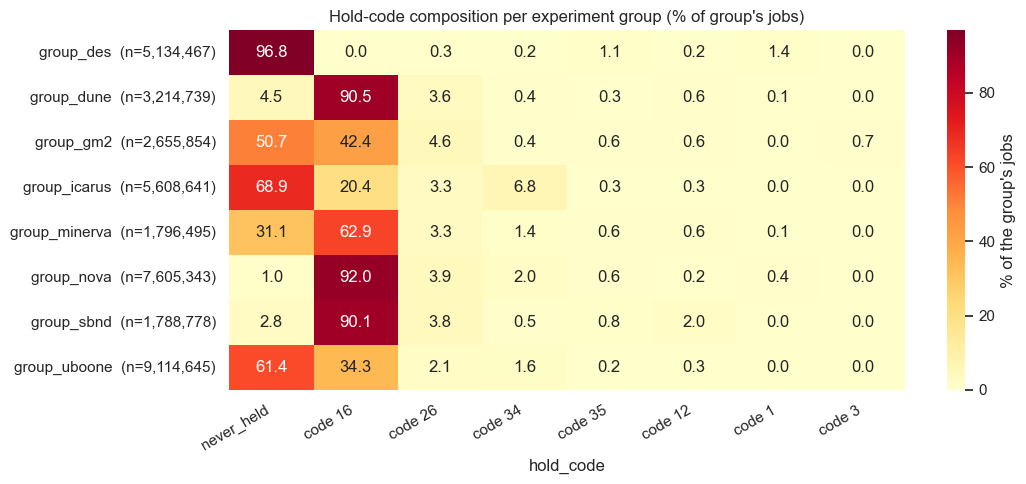

In [46]:
top_groups = (analysis_df.group_by("Group").len().sort("len", descending=True)
              .head(8)["Group"].to_list())
comp = (analysis_df.filter(pl.col("Group").is_in(top_groups))
        .with_columns(hc)
        .group_by("Group", "hold_code").len()
        .with_columns((pl.col("len") / pl.col("len").sum().over("Group") * 100).alias("pct"))
        .filter(pl.col("hold_code").is_in(["never_held"] + [f"code {c}" for c in TOP_CODES])))
comp_pd = (comp.to_pandas().pivot(index="Group", columns="hold_code", values="pct")
           .reindex(columns=[o for o in order])
           .fillna(0.0))
gsize = analysis_df.group_by("Group").len().to_pandas().set_index("Group")["len"]
comp_pd = comp_pd.loc[comp_pd.index.sort_values()]
comp_pd.index = [f"{g}  (n={gsize[g]:,})" for g in comp_pd.index]

plt.figure(figsize=(11, 5))
ax = sns.heatmap(comp_pd, annot=True, fmt=".1f", cmap="YlOrRd",
                 cbar_kws={"label": "% of the group's jobs"})
ax.set_title("Hold-code composition per experiment group (% of group's jobs)")
ax.set_ylabel("")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

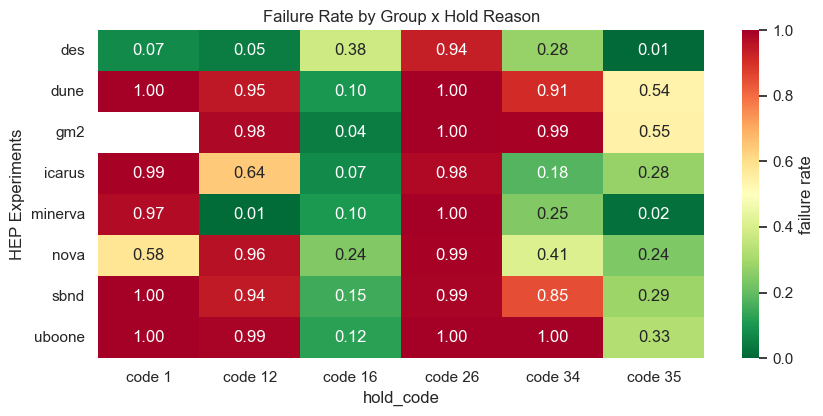

In [51]:
frate = (analysis_df.filter(pl.col("Group").is_in(top_groups))
         .with_columns(hc)
         .filter(pl.col("hold_code").is_in([f"code {c}" for c in [16, 26, 34, 35, 12, 1]]))
         .group_by("Group", "hold_code")
         .agg(pl.col("Failed").mean().alias("fail_rate"), pl.len().alias("n"))
         # .filter(pl.col("n") >= 1000)
         )

fr_pd = frate.to_pandas().pivot(index="Group", columns="hold_code", values="fail_rate")

fr_pd.index = fr_pd.index.str.replace("group_", "", case=False)

plt.figure(figsize=(9, 4.5))
ax = sns.heatmap(fr_pd, annot=True, fmt=".2f", cmap="RdYlGn_r", vmin=0, vmax=1,
                 cbar_kws={"label": "failure rate"})

ax.set_title("Failure Rate by Group x Hold Reason")
ax.set_ylabel("HEP Experiments") 
sns.set_context("talk")
plt.tight_layout()
plt.show()

## Three-target benchmark: with vs without concurrency (subset run)

Targets, all evaluated rolling-origin (2-month train windows, 4 folds):

1. **problem_hold** — will the job hit a hold other than routine spooling (code 16)?
2. **failed** — the repo-standard binary failure label.
3. **failure_type** — among failed jobs, Application / System / User per the README label
   cascade (3-class, balanced class weights).

Feature settings (cyclical time features are part of the baseline — no with/without-cyclical
comparison):

- **baseline** = job characteristics + cyclical (sin/cos hour, day-of-week, day-of-month, month)
  for **both clocks**: submission time (`QDate`) and start-executing time.
- **baseline+concurrency** = baseline + running job count at the same site and same group at the
  job's start instant (sweep-line features, brute-force-validated below).

`JobPrio` is **excluded** from both settings: priority can be adjusted (by users or POMS) in
reaction to job state, making it a suspected leak. Identifiers and raw timestamps are excluded
as before.

This is a **30% subset run** (seeded, sampled after computing concurrency on the full data) to
get initial results quickly; the full-data run alongside CatBoost/LightGBM on GPU comes later.
All 24 fitted models are saved to `../models/hold-failure/` (`.ubj`).

**Decision thresholds are tuned inside the training procedure**, never on the test month: a
calibration model fits on the first training month, the F1-maximizing threshold is read off the
second (held-out-in-time), the final model refits on both months, and that frozen threshold
produces the precision/recall/F1/accuracy/MCC columns on the test month. PR-AUC/ROC-AUC stay
threshold-free.

In [5]:
%%time
import gc
import math

# --- extra columns needed for concurrency + failure-type labels ---
# CompletionDate_ms is already present via the outcome columns.
# The second block are the match-time/submission-time columns from the BatchSystem.txt audit:
# populated, non-constant, and knowable before the job produces any outcome.
AUDIT_COLS = ["Jobsub_Group", "SingularityImage", "POMS4_CAMPAIGN_TYPE", "POMS4_TEST_LAUNCH",
              "Drain", "MATCH_GLIDEIN_Entry_Name", "MATCH_GLIDEIN_SiteWMS_Queue",
              "MachineAttrGLIDEIN_ResourceName0", "MachineAttrCpus0", "Blacklist_Sites",
              "x509UserProxyExpiration_ms"]
side = pl.scan_parquet(path).select(
    ["MATCH_EXP_JOB_Site", "RemoteWallClockTime"] + AUDIT_COLS
).collect()
feat_df = pl.concat([analysis_df, side], how="horizontal").with_row_index("job_row_id")
del side

start_col = pl.col("JobCurrentStartExecutingDate_ms")
end_ms = pl.max_horizontal(pl.col("CompletionDate_ms"), start_col + pl.col("RemoteWallClockTime") * 1000)
end_ms = pl.when(end_ms > start_col).then(end_ms).otherwise(start_col + 1)
feat_df = feat_df.with_columns(end_ms.alias("end_ms"))


def running_count(df, key, out_name):
    """Jobs of the same `key` running at this job's start instant (own job excluded).
    Same event-series construction validated in concurrency-context-modeling.ipynb."""
    d = df.filter(pl.col(key).is_not_null() & pl.col("JobCurrentStartExecutingDate_ms").is_not_null())
    ev = pl.concat([
        d.select(pl.col(key).alias("k"),
                 pl.col("JobCurrentStartExecutingDate_ms").alias("t"),
                 pl.lit(1).alias("delta"), pl.lit(0).alias("ok")),
        d.select(pl.col(key).alias("k"), pl.col("end_ms").alias("t"),
                 pl.lit(-1).alias("delta"), pl.lit(1).alias("ok")),
    ]).sort(["k", "t", "ok"], descending=[False, False, True])
    # ends sort before starts at equal t -> matches brute-force `end > t` semantics
    ev = ev.with_columns(pl.col("delta").cum_sum().over("k").alias("running"))
    ev = ev.group_by("k", "t", maintain_order=True).agg(pl.col("running").last()).sort("t")
    out = (df.select("job_row_id", pl.col(key).alias("k"),
                     pl.col("JobCurrentStartExecutingDate_ms").alias("t")).sort("t")
             .join_asof(ev, left_on="t", right_on="t", by="k", strategy="backward"))
    own = (pl.col("k").is_not_null() & pl.col("t").is_not_null()).cast(pl.Int32)
    return out.with_columns(
        (pl.col("running").fill_null(0) - own).alias(out_name)
    ).select("job_row_id", out_name)


CONC_COLS = ["concurrent_running_same_site", "concurrent_running_same_group"]
for key, name in [("MATCH_EXP_JOB_Site", CONC_COLS[0]), ("Group", CONC_COLS[1])]:
    feat_df = feat_df.join(running_count(feat_df, key, name), on="job_row_id", how="left")
feat_df = feat_df.with_columns([pl.col(c).fill_null(0) for c in CONC_COLS])

# brute-force validation on sampled jobs, same discipline as always
_ok = True
for row in (feat_df.filter(pl.col("MATCH_EXP_JOB_Site").is_not_null() &
                           pl.col("JobCurrentStartExecutingDate_ms").is_not_null())
            .sample(n=3, seed=11).iter_rows(named=True)):
    bf = feat_df.filter(
        (pl.col("MATCH_EXP_JOB_Site") == row["MATCH_EXP_JOB_Site"]) &
        (pl.col("job_row_id") != row["job_row_id"]) &
        (pl.col("JobCurrentStartExecutingDate_ms") <= row["JobCurrentStartExecutingDate_ms"]) &
        (pl.col("end_ms") > row["JobCurrentStartExecutingDate_ms"])
    ).height
    _ok &= bf == row["concurrent_running_same_site"]
print("concurrency validation:", "ALL MATCH" if _ok else "MISMATCH")
assert _ok

# --- cyclical time features for BOTH clocks: submission (QDate) and start-executing ---
def cyclical(col_expr, period, prefix):
    return [(2 * math.pi * col_expr / period).sin().alias(f"{prefix}_sin"),
            (2 * math.pi * col_expr / period).cos().alias(f"{prefix}_cos")]

cyc_exprs = []
for src_col, tag in [("QDate_ms", "qdate"), ("JobCurrentStartExecutingDate_ms", "jstart")]:
    dt = pl.from_epoch(pl.col(src_col), time_unit="ms")
    cyc_exprs += (cyclical(dt.dt.hour(), 24, f"{tag}_hour") +
                  cyclical(dt.dt.weekday(), 7, f"{tag}_dow") +
                  cyclical(dt.dt.day(), 31, f"{tag}_dom") +
                  cyclical(dt.dt.month(), 12, f"{tag}_month"))
feat_df = feat_df.with_columns(cyc_exprs)
CYC_COLS = [f"{t}_{p}_{tr}" for t in ["qdate", "jstart"]
            for p in ["hour", "dow", "dom", "month"] for tr in ["sin", "cos"]]

# --- failure-type label: the README cascade (same as baseline-prediction.ipynb) ---
# 0 Success, 1 Application, 2 System, 3 User
EXIT_CODE_USER = [1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14, 22, 23, 28, 31, 32, 33,
                  65, 67, 68, 69, 71, 88, 90, 91, 124, 137]
SIGNAL_APP = [4, 6, 7, 8, 9, 11, 24]
rr = pl.col("RemoveReason").fill_null("")
feat_df = feat_df.with_columns(
    pl.when((pl.col("ExitCode") == 0) & pl.col("ExitSignal").is_null() &
            (pl.col("JobStatus") != 3)).then(0)
    .when(pl.col("ExitSignal").is_in(SIGNAL_APP)).then(1)
    .when(pl.col("ExitSignal").is_not_null()).then(2)
    .when(pl.col("ExitCode").is_in(EXIT_CODE_USER)).then(3)
    .when(pl.col("ExitCode").is_not_null() & (pl.col("ExitCode") != 0)).then(1)
    .when(rr.str.contains("OtherJobRemoveRequirements") |
          rr.str.contains("Node Error: DAG node")).then(1)
    .when(rr.str.contains(r"via condor_rm \(by user")).then(3)
    .when(rr.str.contains("SYSTEM_PERIODIC_REMOVE") | rr.str.contains("PeriodicRemove")).then(3)
    .when(rr.str.contains("JobRouter")).then(2)
    .when(pl.col("LastHoldReasonCode") == 34).then(3)
    .when(pl.col("LastHoldReasonCode").is_in([6, 14, 22, 45])).then(2)
    .when(pl.col("JobStatus") == 3).then(2)
    .otherwise(0).cast(pl.Int8).alias("failure_type")
)

# derived feature: hours of x509 proxy lifetime remaining at submission. A proxy that is
# already expired (negative) or nearly expired at submit time is a plausible auth-failure cause.
# Clipped to +/-30 days because a few raw values are nonsense (minimum ~ -474,000 hours).
feat_df = feat_df.with_columns(
    ((pl.col("x509UserProxyExpiration_ms") - pl.col("QDate_ms")) / 3.6e6)
    .clip(-720, 720).alias("proxy_hours_left")
)

# campaign stage type per the README "Campaign Stages" table (same regex as
# baseline-prediction.ipynb): null for jobs with no campaign/stage at all
_lc_stage = pl.col("POMS4_CAMPAIGN_STAGE_NAME").str.to_lowercase()
feat_df = feat_df.with_columns(
    pl.when(pl.col("POMS4_CAMPAIGN_STAGE_NAME").is_null() &
            pl.col("POMS4_CAMPAIGN_NAME").is_null()).then(pl.lit(None, dtype=pl.Utf8))
    .when(_lc_stage.str.contains(
        "gen|g4|sim|dio|endpoint|leadinglog|corsika|resample|wire_mod|wiremod|ly_|lyattn|"
        "lydown|sce|theta|tpc|offset|mix|ensemble|rpc|spill|cv|run[0-9]+")).then(pl.lit("generation"))
    .when(_lc_stage.str.contains(
        "reco|track|stage0|stage1|digi|decode|recluster|fullproduction|ndlar|compress|convert"
    )).then(pl.lit("reconstruction"))
    .when(_lc_stage.str.contains(
        "merge|skim|hadd|filter|scrub|watchdog|sleep|test|fclless")).then(pl.lit("merging"))
    .when(_lc_stage.str.contains("ana|caf|ntuple|larcv")).then(pl.lit("analysis"))
    .otherwise(pl.lit("other_production")).alias("stage_type")
)

SUBSET_FRACTION = 0.30
sub = feat_df.sample(fraction=SUBSET_FRACTION, seed=42)
print(f"subset: {sub.height:,} of {feat_df.height:,} jobs")
print("failure_type distribution in subset (0=Success, 1=App, 2=System, 3=User):")
print(sub.group_by("failure_type").len().sort("failure_type"))
del feat_df
gc.collect()

<timed exec>:40: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided


concurrency validation: ALL MATCH


subset: 12,323,973 of 41,079,913 jobs
failure_type distribution in subset (0=Success, 1=App, 2=System, 3=User):
shape: (4, 2)
┌──────────────┬──────────┐
│ failure_type ┆ len      │
│ ---          ┆ ---      │
│ i8           ┆ u32      │
╞══════════════╪══════════╡
│ 0            ┆ 10021333 │
│ 1            ┆ 532194   │
│ 2            ┆ 708171   │
│ 3            ┆ 1062275  │
└──────────────┴──────────┘


CPU times: user 2min 11s, sys: 1min 18s, total: 3min 30s
Wall time: 1min 3s


0

In [6]:
%%time
import os
from xgboost import XGBClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             precision_recall_fscore_support, precision_recall_curve,
                             accuracy_score, matthews_corrcoef)

MODELS_DIR = "../models/hold-failure"
os.makedirs(MODELS_DIR, exist_ok=True)

FEAT_CAT = ["Group", "Owner", "POMS_LAUNCHER", "POMS4_CAMPAIGN_NAME", "POMS4_CAMPAIGN_STAGE_NAME",
            "POMS4_CAMPAIGN_ID", "POMS4_CAMPAIGN_STAGE_ID", "MATCH_EXP_JOB_GLIDEIN_Site"]
# JobPrio deliberately absent: suspected leakage (can be adjusted in reaction to job state)
FEAT_NUM = ["RequestCpus", "RequestDisk", "RequestMemory", "RequestSlots",
            "CpusProvisioned", "DiskProvisioned", "MemoryProvisioned", "ExecutableSize",
            "TransferInputSizeMB", "JOB_EXPECTED_MAX_LIFETIME", "JobCurrentWaitTime",
            "TotalSubmitProcs"]
FEATURE_SETS = {"baseline": FEAT_CAT + FEAT_NUM + CYC_COLS,
                "baseline+concurrency": FEAT_CAT + FEAT_NUM + CYC_COLS + CONC_COLS}
ALL_FEATS = FEATURE_SETS["baseline+concurrency"]

enc = sub.select(
    [pl.col(c).cast(pl.Utf8).fill_null("__MISSING__").cast(pl.Categorical)
       .to_physical().cast(pl.Float32).alias(c) for c in FEAT_CAT] +
    [pl.col(c).cast(pl.Float32, strict=False).alias(c) for c in FEAT_NUM + CYC_COLS + CONC_COLS]
)
X_all = enc.select(ALL_FEATS).to_numpy()
y_bin = {"problem_hold": (sub["hold_bucket"] == "problem_hold").cast(pl.Int8).to_numpy(),
         "failed": sub["Failed"].to_numpy()}
ftype = sub["failure_type"].to_numpy()
month_arr = sub["qmonth"].to_numpy()
groups_all = sub["Group"].to_numpy()
del enc
gc.collect()

CLASS_NAMES3 = ["Application", "System", "User"]   # failure_type 1 / 2 / 3
FOLDS = [((1, 2), 3), ((2, 3), 4), ((3, 4), 5), ((4, 5), 6)]
XGB_KW = dict(tree_method="hist", n_estimators=200, max_depth=8, learning_rate=0.1, n_jobs=-1)


def f1_max_threshold(y_true, p):
    prec, rec, thr = precision_recall_curve(y_true, p)
    f1s = 2 * prec * rec / np.clip(prec + rec, 1e-12, None)
    return float(thr[np.argmax(f1s[:-1])])


binary_rows, type_rows, class_rows, comp_rows = [], [], [], []
global_probs = {}
for fs_name, cols in FEATURE_SETS.items():
    fs_tag = fs_name.replace("+", "-")
    col_idx = np.array([ALL_FEATS.index(c) for c in cols])
    for train_months, test_month in FOLDS:
        m1, m2 = train_months
        tr = np.where(np.isin(month_arr, train_months))[0]
        te = np.where(month_arr == test_month)[0]
        cal_tr = np.where(month_arr == m1)[0]
        cal_va = np.where(month_arr == m2)[0]

        for tname in ["problem_hold", "failed"]:
            y = y_bin[tname]
            # threshold tuning inside training: fit on m1, pick F1-max threshold on m2,
            # refit on m1+m2, apply the frozen threshold to the test month
            spw_c = float((y[cal_tr] == 0).sum() / max((y[cal_tr] == 1).sum(), 1))
            cal = XGBClassifier(eval_metric="aucpr", scale_pos_weight=spw_c, **XGB_KW)
            cal.fit(X_all[np.ix_(cal_tr, col_idx)], y[cal_tr])
            thr = f1_max_threshold(y[cal_va],
                                   cal.predict_proba(X_all[np.ix_(cal_va, col_idx)])[:, 1])
            del cal
            gc.collect()

            spw = float((y[tr] == 0).sum() / max((y[tr] == 1).sum(), 1))
            m = XGBClassifier(eval_metric="aucpr", scale_pos_weight=spw, **XGB_KW)
            m.fit(X_all[np.ix_(tr, col_idx)], y[tr])
            p = m.predict_proba(X_all[np.ix_(te, col_idx)])[:, 1]
            if fs_name == "baseline+concurrency":
                global_probs[(tname, test_month)] = p
            y_pred = (p >= thr).astype(np.int8)
            pr_, rc_, f1_, _ = precision_recall_fscore_support(
                y[te], y_pred, average="binary", zero_division=0)
            binary_rows.append({
                "target": tname, "features": fs_name, "train": f"{m1:02d}+{m2:02d}",
                "test_month": test_month, "n_train": len(tr), "n_test": len(te),
                "base_rate": float(y[te].mean()),
                "pr_auc": average_precision_score(y[te], p),
                "roc_auc": roc_auc_score(y[te], p), "threshold": thr,
                "precision": pr_, "recall": rc_, "f1": f1_,
                "accuracy": accuracy_score(y[te], y_pred),
                "mcc": matthews_corrcoef(y[te], y_pred),
            })
            m.save_model(f"{MODELS_DIR}/xgb_{tname}_{fs_tag}_test{test_month:02d}.ubj")
            del m
            gc.collect()

        # failure_type: 3-class among failed jobs only, balanced class weights
        trf = tr[ftype[tr] > 0]
        tef = te[ftype[te] > 0]
        y3_tr, y3_te = ftype[trf] - 1, ftype[tef] - 1
        cw = len(y3_tr) / (3.0 * np.bincount(y3_tr, minlength=3))
        m3 = XGBClassifier(eval_metric="mlogloss", **XGB_KW)
        m3.fit(X_all[np.ix_(trf, col_idx)], y3_tr, sample_weight=cw[y3_tr])
        p3 = m3.predict_proba(X_all[np.ix_(tef, col_idx)])
        pred3 = p3.argmax(axis=1)
        pr3, rc3, f13, sup3 = precision_recall_fscore_support(y3_te, pred3, labels=[0, 1, 2],
                                                              zero_division=0)
        type_rows.append({
            "target": "failure_type", "features": fs_name, "train": f"{m1:02d}+{m2:02d}",
            "test_month": test_month, "n_train": len(trf), "n_test": len(tef),
            "macro_f1": f1_score(y3_te, pred3, average="macro"),
            "ovr_roc_auc": roc_auc_score(y3_te, p3, multi_class="ovr", average="macro"),
            "f1_Application": f13[0], "f1_System": f13[1], "f1_User": f13[2],
        })
        for k, cname in enumerate(CLASS_NAMES3):
            class_rows.append({"features": fs_name, "test_month": test_month, "class": cname,
                               "precision": pr3[k], "recall": rc3[k], "f1": f13[k],
                               "support": int(sup3[k])})
            if fs_name == "baseline+concurrency":
                comp_rows.append({"test_month": test_month, "class": cname,
                                  "true": int(sup3[k]), "pred": int((pred3 == k).sum())})
        m3.save_model(f"{MODELS_DIR}/xgb_failure_type_{fs_tag}_test{test_month:02d}.ubj")
        print(f"{fs_name:22s} test {test_month:02d}: done")
        del m3
        gc.collect()

import pandas as pd
binary_res = pd.DataFrame(binary_rows)
type_res = pd.DataFrame(type_rows)
cls = pd.DataFrame(class_rows)
comp = pd.DataFrame(comp_rows)

pd.set_option("display.width", 220)
print()
print("=== binary targets, every fold (threshold tuned on the 2nd train month) ===")
print(binary_res.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
print()
print("=== failure_type, every fold ===")
print(type_res.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
print()
print("=== fold means, binary ===")
print(binary_res.groupby(["target", "features"])[
    ["pr_auc", "roc_auc", "precision", "recall", "f1", "accuracy", "mcc"]].mean().round(3))
print()
print("=== fold means, failure_type ===")
print(type_res.groupby(["target", "features"])[
    ["macro_f1", "ovr_roc_auc", "f1_Application", "f1_System", "f1_User"]].mean().round(3))

baseline               test 03: done


baseline               test 04: done


baseline               test 05: done


baseline               test 06: done


baseline+concurrency   test 03: done


baseline+concurrency   test 04: done


baseline+concurrency   test 05: done


baseline+concurrency   test 06: done

=== binary targets, every fold (threshold tuned on the 2nd train month) ===
      target             features train  test_month  n_train  n_test  base_rate  pr_auc  roc_auc  threshold  precision  recall    f1  accuracy    mcc
problem_hold             baseline 01+02           3  4779333 1607726      0.065   0.372    0.751      0.772      0.472   0.285 0.356     0.933  0.334
      failed             baseline 01+02           3  4779333 1607726      0.202   0.415    0.646      0.479      0.368   0.424 0.394     0.736  0.227
problem_hold             baseline 02+03           4  3785715 1805201      0.098   0.332    0.679      0.825      0.631   0.190 0.292     0.910  0.313
      failed             baseline 02+03           4  3785715 1805201      0.162   0.163    0.483      0.311      0.147   0.508 0.228     0.442 -0.046
problem_hold             baseline 03+04           5  3412927 2289391      0.042   0.332    0.675      0.635      0.217   0.352 0.268    

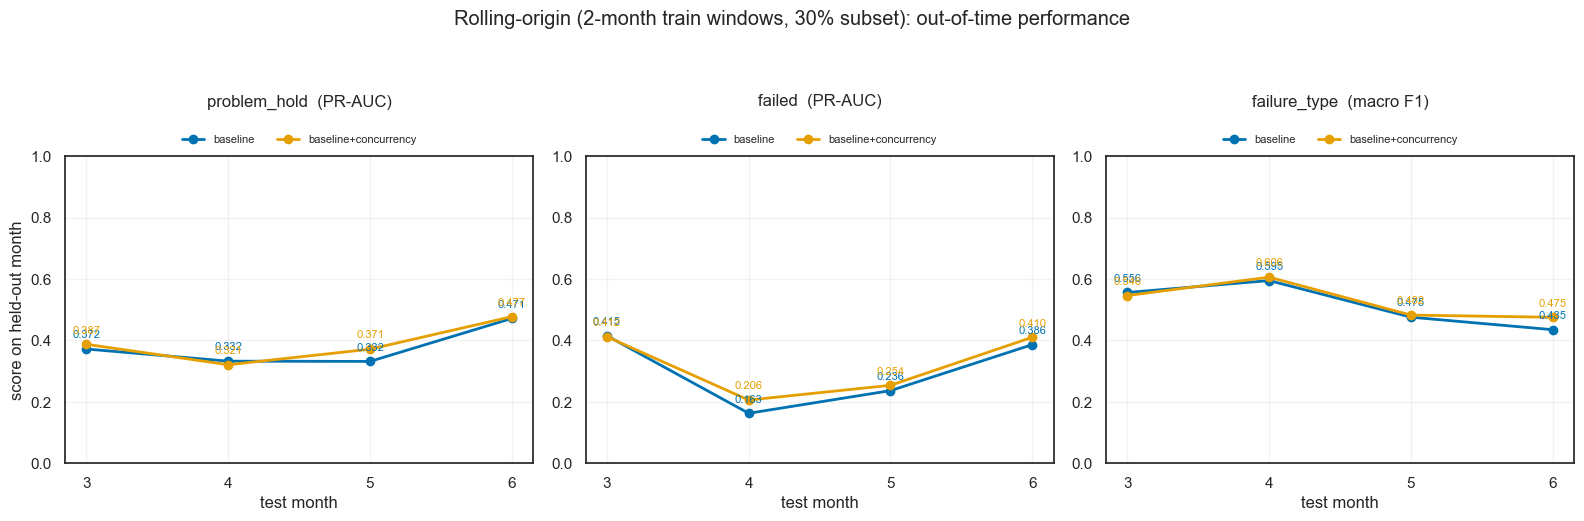

In [7]:
PAL_FS = {"baseline": "#0072B2", "baseline+concurrency": "#E69F00"}
PANELS = [("problem_hold", "pr_auc", "PR-AUC"), ("failed", "pr_auc", "PR-AUC"),
          ("failure_type", "macro_f1", "macro F1")]


def panel_data(target, metric):
    d = type_res if target == "failure_type" else binary_res
    return d[d["target"] == target][["features", "test_month", metric]].rename(
        columns={metric: "value"})


fig, axes = plt.subplots(1, 3, figsize=(16, 4.9))
for ax, (target, metric, mlabel) in zip(axes, PANELS):
    d = panel_data(target, metric)
    for fs_name, g in d.groupby("features"):
        g = g.sort_values("test_month")
        ax.plot(g.test_month, g.value, "-o", color=PAL_FS[fs_name], lw=2, ms=6, label=fs_name)
        for x, v in zip(g.test_month, g.value):
            ax.annotate(f"{v:.3f}", (x, v), textcoords="offset points", xytext=(0, 8),
                        ha="center", fontsize=8, color=PAL_FS[fs_name])
    ax.set_title(f"{target}  ({mlabel})", pad=36)
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.005), ncol=2, frameon=False, fontsize=8)
    ax.set_xlabel("test month")
    ax.set_xticks([3, 4, 5, 6])
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.25)
axes[0].set_ylabel("score on held-out month")
plt.suptitle("Rolling-origin (2-month train windows, 30% subset): out-of-time performance",
             y=1.06)
plt.tight_layout()
plt.show()

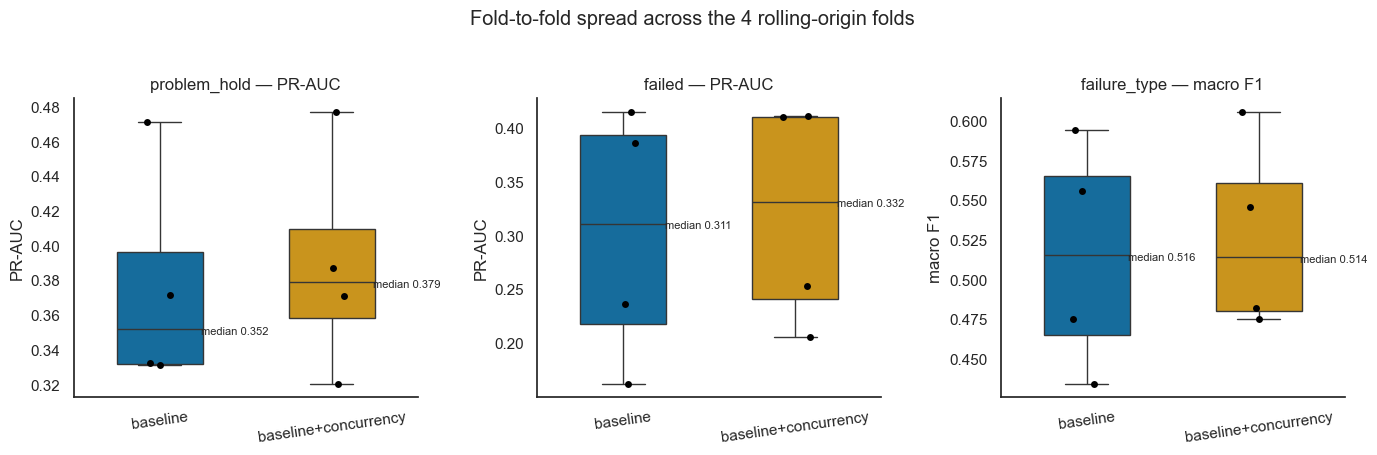

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))
for ax, (target, metric, mlabel) in zip(axes, PANELS):
    d = panel_data(target, metric)
    sns.boxplot(data=d, x="features", y="value", hue="features", palette=PAL_FS,
                width=0.5, ax=ax, legend=False)
    sns.stripplot(data=d, x="features", y="value", color="black", size=5, ax=ax)
    for i, (fs_name, v) in enumerate(d.groupby("features").value.median().items()):
        ax.annotate(f"median {v:.3f}", (i, v), textcoords="offset points", xytext=(30, -4),
                    fontsize=8)
    ax.set_title(f"{target} — {mlabel}")
    ax.set_xlabel("")
    ax.set_ylabel(mlabel)
    ax.tick_params(axis="x", rotation=8)
sns.despine()
plt.suptitle("Fold-to-fold spread across the 4 rolling-origin folds", y=1.03)
plt.tight_layout()
plt.show()

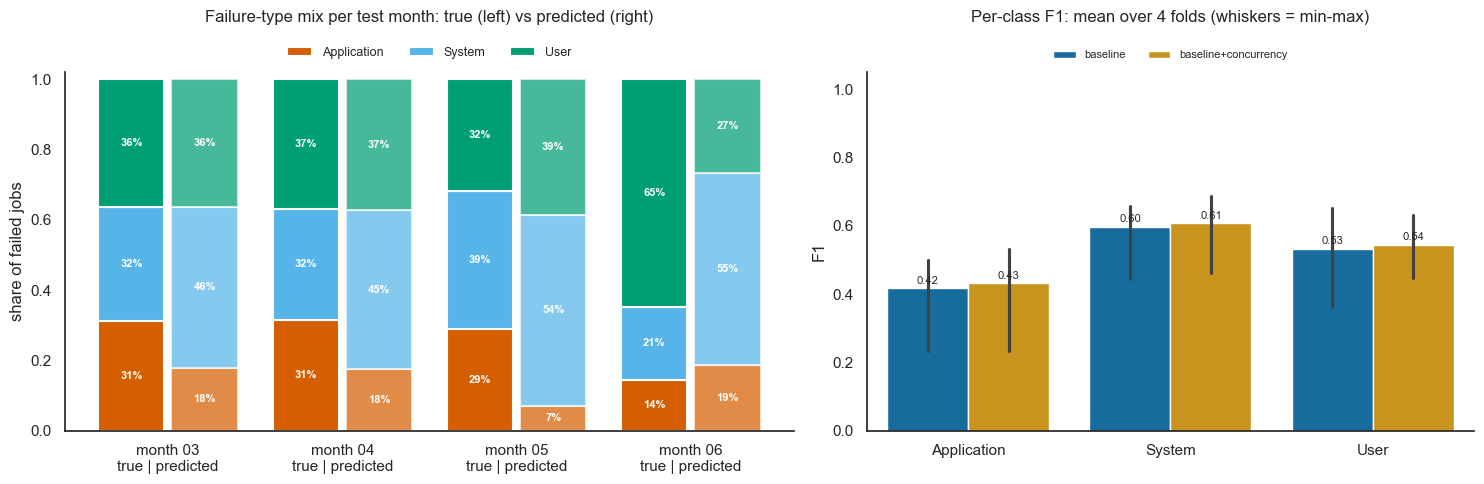

In [9]:
PAL_CLS = {"Application": "#D55E00", "System": "#56B4E9", "User": "#009E73"}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={"width_ratios": [1.2, 1]})

months = sorted(comp.test_month.unique())
width = 0.38
for j, kind in enumerate(["true", "pred"]):
    bottoms = np.zeros(len(months))
    for cname in CLASS_NAMES3:
        vals = np.array([
            comp[(comp.test_month == mth) & (comp["class"] == cname)][kind].iloc[0] /
            comp[comp.test_month == mth][kind].sum()
            for mth in months
        ])
        xs = np.arange(len(months)) + (j - 0.5) * (width + 0.04)
        ax1.bar(xs, vals, width, bottom=bottoms, color=PAL_CLS[cname],
                edgecolor="white", linewidth=1.5,
                label=cname if j == 0 else None, alpha=1.0 if j == 0 else 0.72)
        for x, v, b in zip(xs, vals, bottoms):
            if v > 0.07:
                ax1.text(x, b + v / 2, f"{v:.0%}", ha="center", va="center",
                         fontsize=8, color="white", fontweight="bold")
        bottoms += vals
ax1.set_xticks(np.arange(len(months)), [f"month {m:02d}\ntrue | predicted" for m in months])
ax1.set_ylim(0, 1.02)
ax1.set_ylabel("share of failed jobs")
ax1.set_title("Failure-type mix per test month: true (left) vs predicted (right)", pad=36)
ax1.legend(loc="lower center", bbox_to_anchor=(0.5, 1.005), ncol=3, frameon=False, fontsize=9)

sns.barplot(data=cls, x="class", y="f1", hue="features", palette=PAL_FS,
            errorbar=lambda v: (v.min(), v.max()), ax=ax2)
for c in ax2.containers:
    ax2.bar_label(c, fmt="%.2f", padding=2, fontsize=8)
ax2.set_ylim(0, 1.05)
ax2.set_title("Per-class F1: mean over 4 folds (whiskers = min-max)", pad=36)
ax2.set_xlabel("")
ax2.set_ylabel("F1")
ax2.legend(loc="lower center", bbox_to_anchor=(0.5, 1.005), ncol=2, frameon=False, fontsize=8)
sns.despine()
plt.tight_layout()
plt.show()

### Does a per-group model beat the global model?

Each experiment group has its own workload and failure modes, so a model trained only on that
group's jobs might out-predict the global one. For the 6 largest groups: train a per-group model
(baseline+concurrency features) on the group's rows in each rolling-origin window, and compare
against the **global** model evaluated on the *same group slice* of the test month. Group/fold
cells with too few positives to learn or score reliably are skipped.

In [10]:
%%time
TOP_GROUPS = sub.group_by("Group").len().sort("len", descending=True).head(6)["Group"].to_list()
pg_cols = FEATURE_SETS["baseline+concurrency"]
pg_idx = np.array([ALL_FEATS.index(c) for c in pg_cols])

pg_rows = []
for tname in ["problem_hold", "failed"]:
    y = y_bin[tname]
    for train_months, test_month in FOLDS:
        tr = np.where(np.isin(month_arr, train_months))[0]
        te = np.where(month_arr == test_month)[0]
        p_global = global_probs[(tname, test_month)]
        gte = groups_all[te]
        for g in TOP_GROUPS:
            g_tr = tr[groups_all[tr] == g]
            mask = gte == g
            y_te_g = y[te][mask]
            if (mask.sum() < 2000 or y_te_g.sum() < 50 or (y_te_g == 0).sum() < 50 or
                    y[g_tr].sum() < 50 or (y[g_tr] == 0).sum() < 50):
                continue
            spw = float((y[g_tr] == 0).sum() / max((y[g_tr] == 1).sum(), 1))
            mg = XGBClassifier(eval_metric="aucpr", scale_pos_weight=spw, **XGB_KW)
            mg.fit(X_all[np.ix_(g_tr, pg_idx)], y[g_tr])
            p_pg = mg.predict_proba(X_all[np.ix_(te[mask], pg_idx)])[:, 1]
            pg_rows.append({
                "target": tname, "group": g, "test_month": test_month,
                "n_train": len(g_tr), "n_test": int(mask.sum()),
                "base_rate": float(y_te_g.mean()),
                "pr_auc_global": average_precision_score(y_te_g, p_global[mask]),
                "pr_auc_pergroup": average_precision_score(y_te_g, p_pg),
                "roc_auc_global": roc_auc_score(y_te_g, p_global[mask]),
                "roc_auc_pergroup": roc_auc_score(y_te_g, p_pg),
            })
            del mg
            gc.collect()

pg = pd.DataFrame(pg_rows)
pg["pr_auc_delta"] = pg["pr_auc_pergroup"] - pg["pr_auc_global"]
print("=== per-group vs global, every group x fold ===")
print(pg.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
print()
print("=== fold means (delta = per-group minus global PR-AUC) ===")
print(pg.groupby(["target", "group"])[
    ["base_rate", "pr_auc_global", "pr_auc_pergroup", "pr_auc_delta",
     "roc_auc_global", "roc_auc_pergroup"]].mean().round(3))

=== per-group vs global, every group x fold ===
      target        group  test_month  n_train  n_test  base_rate  pr_auc_global  pr_auc_pergroup  roc_auc_global  roc_auc_pergroup  pr_auc_delta
problem_hold group_uboone           3  1389583  490468      0.032          0.143            0.078           0.758             0.723        -0.065
problem_hold   group_nova           3  1131980  366759      0.077          0.454            0.454           0.723             0.741         0.000
problem_hold group_icarus           3   552196  148834      0.107          0.666            0.660           0.847             0.813        -0.006
problem_hold    group_des           3   244278   40358      0.004          0.658            0.312           0.875             0.896        -0.346
problem_hold   group_dune           3   346252  128648      0.079          0.368            0.198           0.679             0.604        -0.169
problem_hold    group_gm2           3   262441  166555      0.094          0

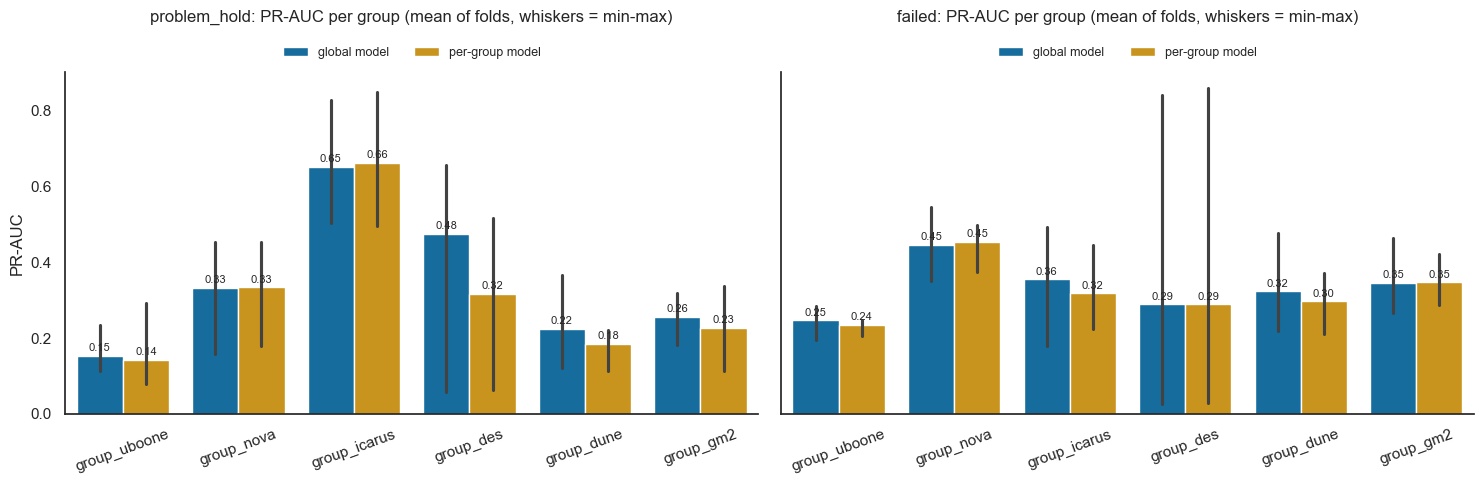

In [11]:
PAL_MODEL = {"global model": "#0072B2", "per-group model": "#E69F00"}

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, tname in zip(axes, ["problem_hold", "failed"]):
    d = (pg[pg.target == tname]
         .melt(id_vars=["group", "test_month"],
               value_vars=["pr_auc_global", "pr_auc_pergroup"],
               var_name="model", value_name="pr_auc"))
    d["model"] = d["model"].map({"pr_auc_global": "global model",
                                 "pr_auc_pergroup": "per-group model"})
    sns.barplot(data=d, x="group", y="pr_auc", hue="model", palette=PAL_MODEL,
                errorbar=lambda v: (v.min(), v.max()), ax=ax)
    for c in ax.containers:
        ax.bar_label(c, fmt="%.2f", padding=2, fontsize=8)
    ax.set_title(f"{tname}: PR-AUC per group (mean of folds, whiskers = min-max)", pad=36)
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.005), ncol=2, frameon=False, fontsize=9)
    ax.tick_params(axis="x", rotation=20)
    ax.set_xlabel("")
axes[0].set_ylabel("PR-AUC")
sns.despine()
plt.tight_layout()
plt.show()

### Three-target verdict (30% subset, no JobPrio, thresholds tuned in-training)

Fold means (full per-fold tables above):

| target | metric | baseline | baseline+concurrency |
|---|---|---|---|
| problem_hold | PR-AUC / ROC-AUC | 0.377 / 0.719 | **0.389 / 0.738** |
| problem_hold | MCC @ tuned threshold | 0.329 | **0.351** |
| failed | PR-AUC / ROC-AUC | 0.300 / 0.614 | **0.320 / 0.640** |
| failure_type | macro F1 / OvR ROC-AUC | 0.515 / **0.740** | **0.527** / 0.737 |

- **Concurrency features help in most folds on every target** (binary PR-AUC up in 3 of 4 folds
  each; failure-type macro F1 up in 3 of 4). The biggest single effect stays the June fold of
  `failed` (ROC-AUC 0.694 → 0.727).
- **Doubling the subset (15% → 30%) barely moved the means** (e.g. problem_hold PR-AUC
  0.386 → 0.389). The binding constraint is distribution shift, not data volume — worth keeping
  expectations calibrated for the full-data GPU runs.
- **Tuned thresholds work for problem_hold, and are fragile for failed.** For problem_hold the
  second-train-month calibration picks high thresholds (0.64-0.94) that deliver precision
  0.40-0.73 at accuracy 0.91-0.96 and MCC up to 0.44. For `failed` the picked thresholds swing
  wildly (0.010-0.479); the May fold's 0.010 threshold degenerates to flag-almost-everything
  (recall 0.996, accuracy 0.189). Thresholds inherit the regime shift — deploy with monthly
  recalibration, and judge folds by MCC, not accuracy alone.
- **Per-group models do not beat the global model.** Mean PR-AUC delta (per-group minus global,
  same group slice) ranges from **-0.159** (group_des, problem_hold) to **+0.011** (group_icarus);
  most cells are ~0 or negative. The global model already conditions on `Group` and keeps
  cross-group statistical strength, so specialization only sheds training data. The interesting
  side-finding: **group_icarus problem_holds are the most predictable cell in the dataset**
  (PR-AUC ~0.65 at base rate 0.14, ROC-AUC ~0.81).
- Failure-type class asymmetry persists: System is most recallable, Application weakest in
  spring, and the June User-failure surge (condor_rm/policy mix drift) still drags every model
  down on that fold.

Models: `../models/hold-failure/` (24 global). Per-group models were not kept — the
comparison tables and chart above are the record.

## Expanded benchmark: four targets, richer match-time features

This section replaces the earlier split experiments and extends the benchmark. What changes:

- **Features**: the audited match-time columns join the feature set — `Drain` (is the matched
  slot draining), glidein entry / remote queue / resource pool, node core count, `Jobsub_Group`,
  `SingularityImage`, `Blacklist_Sites`, `POMS4_CAMPAIGN_TYPE`, `POMS4_TEST_LAUNCH`, and the
  derived `proxy_hours_left` (x509 proxy lifetime remaining at submission). All are recorded at
  or before the job's match to a slot, so none can encode the job's outcome. Missing values mean
  "job was never matched" (or "not a production job") and are kept as their own category.
- **Targets**: four now — `failed` (binary), `problem_hold` (binary), `failure_type` (3-class
  User/System/Application among failed jobs), and **`hold_type`** (new: among problem-held jobs,
  *which* hold will it be — classes are the five high-volume hold codes plus "other").
- **Protocol**: unchanged — rolling-origin, 2-month train windows, 4 folds, class weighting,
  decision thresholds for the binary targets tuned on the second train month, never on test.
- **Outputs**: full per-fold tables; grouped precision/recall/F1 bars for all four targets;
  confusion matrices and ROC curves from **pooled out-of-fold predictions** (each test month
  scored by the model that never saw it, then concatenated — so one chart summarizes all four
  folds honestly); per-model training-loss curves; a **campaign-aware** split decomposition; and
  a three-referee hyperparameter-selection test including temporal validation.
- **Models** are saved to `../models/hold-failure/`, overwriting the previous files.

### Cell: targets and feature matrix (revised labels)

Feature changes: `stage_type` (the README Campaign Stages taxonomy) joins the categorical list.
Encoding is unchanged: each categorical column's distinct strings become integer ids (nulls →
`__MISSING__` as their own category); numerics are cast to float32 with NaN for nulls.

**`failure_type`** (0=Application, 1=System, 2=User; -1 = not in the task's population) now
follows the updated README tables exactly, top-down:

1. Exit code 0 with no signal and not removed → Success (excluded from the task).
2. A non-null **exit signal** maps through the exit-code table's `128+n` rows (there is no
   separate signal table anymore): signals 2,3,4,5,8,9 → User; 1,6,7,11,13,15 → System; every
   other signal (74, 76, 94, 117, 121, 122, ...) → Application per the "Other ExitSignals" table.
3. A non-zero **exit code** maps through the code table; codes not listed → Application.
4. A **removed** job with no code/signal is typed by its **hold evidence first**: the
   `LastHoldReasonCode` maps through the hold table's Hold Type column (3, 6, 16 → Application;
   1, 4, 7, 8, 12, 13, 26, 32, 33, 34, 35 → User). Only if no hold code exists does
   `RemoveReason` decide: DAG-cascade → Application; `SYSTEM_PERIODIC_REMOVE ... exceeding job
   limits` (and the >24h opportunistic policy) → User (exceeding requested limits);
   `Held 14 days` / other `PeriodicRemove` "sat held too long" policies → **Application** (an
   HTCondor hold-policy consequence, not a user mistake); `JobRouter` → System. A manual
   `condor_rm (by user ...)` with **no** hold evidence is a pure user action we cannot predict —
   those jobs (only 198 in the dataset; 335,698 of 335,896 condor_rm removals do carry a hold
   code) are **excluded** (-1).

**`hold_type`** (predict *which* problem hold a job will hit) — population = jobs whose last
hold code is not null and not 16 (routine spooling), **not 1** (a manual user hold — an
unpredictable human action, per the same logic as condor_rm), and **not 12** (output-transfer
holds fire because the job already failed to produce output — an outcome, not a predictable
condition). Never-held jobs are *not* in the population at all, so the model cannot score an
"other" prediction as correct on a job that was never held. Classes:

| class | codes | note |
|---|---|---|
| memory/disk limit | 34, and 26 where the reason text matches memory/disk | the dominant 26 text is a compound policy (memory OR disk OR restarts OR lifetime in one expression) — it is assigned here by its leading clauses |
| runtime limit | 26 where the reason text matches "run time" | |
| node failure | 6, 35 | |
| other policy | 26 `Shadows/limit`/`Starts/limit` (restart-limit policy, ~369k jobs), 3, 4, 7, 8, 13, 32, 33 | |

Class imbalance is handled in the training cell with balanced per-class sample weights
`n/(K*n_class)`, so each class contributes equally to the loss regardless of size.

In [6]:
import os
import pandas as pd

FEAT_CAT2 = ["Group", "Owner", "POMS_LAUNCHER", "POMS4_CAMPAIGN_NAME", "POMS4_CAMPAIGN_STAGE_NAME",
             "POMS4_CAMPAIGN_ID", "POMS4_CAMPAIGN_STAGE_ID", "MATCH_EXP_JOB_GLIDEIN_Site",
             "Jobsub_Group", "SingularityImage", "POMS4_CAMPAIGN_TYPE", "POMS4_TEST_LAUNCH",
             "Drain", "MATCH_GLIDEIN_Entry_Name", "MATCH_GLIDEIN_SiteWMS_Queue",
             "MachineAttrGLIDEIN_ResourceName0", "MachineAttrCpus0", "Blacklist_Sites",
             "stage_type"]
FEAT_NUM2 = ["RequestCpus", "RequestDisk", "RequestMemory", "RequestSlots",
             "CpusProvisioned", "DiskProvisioned", "MemoryProvisioned", "ExecutableSize",
             "TransferInputSizeMB", "JOB_EXPECTED_MAX_LIFETIME", "JobCurrentWaitTime",
             "TotalSubmitProcs", "proxy_hours_left"]
FEATURE_SETS2 = {"baseline": FEAT_CAT2 + FEAT_NUM2 + CYC_COLS,
                 "baseline+concurrency": FEAT_CAT2 + FEAT_NUM2 + CYC_COLS + CONC_COLS}
ALL2 = FEATURE_SETS2["baseline+concurrency"]

enc = sub.select(
    [pl.col(c).cast(pl.Utf8).fill_null("__MISSING__").cast(pl.Categorical)
       .to_physical().cast(pl.Float32).alias(c) for c in FEAT_CAT2] +
    [pl.col(c).cast(pl.Float32, strict=False).alias(c) for c in FEAT_NUM2 + CYC_COLS + CONC_COLS]
)
X2 = enc.select(ALL2).to_numpy()
del enc
gc.collect()

y2 = {"problem_hold": (sub["hold_bucket"] == "problem_hold").cast(pl.Int8).to_numpy(),
      "failed": sub["Failed"].to_numpy()}
month2 = sub["qmonth"].to_numpy()

# ---- failure_type per the updated README tables
# (0=Application, 1=Hardware, 2=Submission, -1=excluded)
EXIT_SUBMISSION = [9, 65, 90, 91, 124, 126, 127, 130, 131, 137]
EXIT_HARDWARE = [129, 143]                                # everything else non-zero -> Application
SIG_SUBMISSION = [2, 3, 9]                             # SIGINT, SIGQUIT, SIGKILL via 128+n rows
SIG_HARDWARE = [1, 15]                                    # SIGHUP, SIGTERM; other signals -> Application
HOLD_FT_APP = [3, 6, 16]                               # hold table "Hold Type" column
HOLD_FT_SUBMISSION = [1, 4, 7, 8, 12, 13, 26, 32, 33, 34, 35]

rr = pl.col("RemoveReason").fill_null("")
lhr = pl.col("LastHoldReasonCode")
ftype_expr = (
    pl.when((pl.col("ExitCode") == 0) & pl.col("ExitSignal").is_null() &
            (pl.col("JobStatus") != 3)).then(-1)                     # Success
    .when(pl.col("ExitSignal").is_in(SIG_SUBMISSION)).then(2)
    .when(pl.col("ExitSignal").is_in(SIG_HARDWARE)).then(1)
    .when(pl.col("ExitSignal").is_not_null()).then(0)
    .when(pl.col("ExitCode").is_in(EXIT_SUBMISSION)).then(2)
    .when(pl.col("ExitCode").is_in(EXIT_HARDWARE)).then(1)
    .when(pl.col("ExitCode").is_not_null() & (pl.col("ExitCode") != 0)).then(0)
    # removed with no code/signal: hold evidence first
    .when(lhr.is_in(HOLD_FT_APP)).then(0)
    .when(lhr.is_in(HOLD_FT_SUBMISSION)).then(2)
    # no hold evidence: RemoveReason
    .when(rr.str.contains("OtherJobRemoveRequirements") |
          rr.str.contains("Node Error: DAG node")).then(0)
    .when(rr.str.contains("exceeding job limits") |
          rr.str.contains("opportunistic")).then(2)                  # exceeded requested limits
    .when(rr.str.contains("Held 14 days") | rr.str.contains("PeriodicRemove")).then(0)
    .when(rr.str.contains("JobRouter")).then(1)
    .when(rr.str.contains(r"via condor_rm \(by user")).then(-1)      # pure user action: excluded
    .when(pl.col("JobStatus") == 3).then(1)
    .otherwise(-1)
).cast(pl.Int8).alias("ft")
y_ftype = sub.select(ftype_expr)["ft"].to_numpy()
FTYPE_NAMES = ["Application", "Hardware", "Submission"]

# ---- hold_type: which problem hold will fire (population excludes 16 spooling,
# 1 manual user hold, 12 output-transfer outcome hold, and all never-held jobs)
lhr_txt = pl.col("LastHoldReason").fill_null("").str.to_lowercase()
htype_expr = (
    pl.when(lhr.is_null() | lhr.is_in([16, 1, 12])).then(-1)
    .when(lhr == 34).then(0)
    .when((lhr == 26) & lhr_txt.str.contains("shadows/limit|starts/limit")).then(3)
    .when((lhr == 26) & lhr_txt.str.contains("run ?time")).then(1)
    .when((lhr == 26) & lhr_txt.str.contains("memory|disk")).then(0)
    .when(lhr.is_in([6, 35])).then(2)
    .otherwise(3)
).cast(pl.Int8).alias("ht")
y_htype = sub.select(htype_expr)["ht"].to_numpy()
HOLD_NAMES = ["memory/disk limit", "runtime limit", "node failure", "other policy"]

# campaign-aware group key: campaign id for production jobs, submission batch for user jobs
gkey = (sub.select(
    pl.when(pl.col("POMS4_CAMPAIGN_ID").is_not_null())
      .then(pl.lit("c:") + pl.col("POMS4_CAMPAIGN_ID").cast(pl.Utf8))
      .otherwise(pl.lit("b:") + pl.col("ClusterId").cast(pl.Utf8))
      .cast(pl.Categorical).to_physical().cast(pl.UInt32).alias("g")
))["g"].to_numpy()

print(f"X2: {X2.shape[0]:,} jobs x {X2.shape[1]} features")
print("failure_type population:", f"{(y_ftype >= 0).sum():,}",
      dict(zip(FTYPE_NAMES, np.bincount(y_ftype[y_ftype >= 0], minlength=3))))
print("hold_type population:   ", f"{(y_htype >= 0).sum():,}",
      dict(zip(HOLD_NAMES, np.bincount(y_htype[y_htype >= 0], minlength=4))))
print(f"campaign-aware groups: {len(np.unique(gkey)):,}")

X2: 12,323,973 jobs x 50 features
failure_type population: 2,302,357 {'Application': np.int64(1544410), 'Hardware': np.int64(375616), 'Submission': np.int64(382331)}
hold_type population:    685,332 {'memory/disk limit': np.int64(390427), 'runtime limit': np.int64(87354), 'node failure': np.int64(90487), 'other policy': np.int64(117064)}
campaign-aware groups: 1,439,907


### Cell: the main experiment — 4 targets x 2 feature sets x 4 folds

For every feature set and every rolling-origin fold (train two months, test the next):

1. **Binary targets** (`problem_hold`, `failed`). A *calibration* model trains on the first
   train month; the decision threshold that maximizes F1 is read off the second train month
   (data the calibration model never saw, but still inside the training window — the test month
   is untouched). The *final* model then retrains on both months with `scale_pos_weight` =
   (negatives/positives), and its scores are thresholded at the calibrated value to produce
   precision/recall/F1/accuracy/MCC. PR-AUC and ROC-AUC are computed from the raw scores and do
   not depend on the threshold.
2. **Multiclass targets** (`failure_type`, `hold_type`). Rows outside the target's population
   are dropped; balanced per-class sample weights `n/(K*n_class)` stop the largest class from
   dominating; predictions are the argmax over class probabilities. Metrics: macro precision /
   recall / F1 (unweighted mean over classes, so small classes count equally) and a macro
   one-vs-rest ROC-AUC (each class scored as "this class vs everything else").
3. **Training-loss capture.** Every final model is fit with an evaluation set attached — a fixed
   500,000-row random sample of its own training rows — and XGBoost records the loss (logloss
   for binary, mlogloss for multiclass) on that sample after every boosting round. This is the
   curve plotted later; a sample is used because evaluating all ~4M training rows on all 200
   rounds would roughly double training time.
4. **Pooled out-of-fold predictions.** Each fold's test-month probabilities are stored; after
   the loop they are concatenated so that every job in Mar-Jun has exactly one prediction, made
   by a model that never trained on its month. Confusion matrices and ROC curves below use this
   pooled set.
5. Every final model is saved to `../models/hold-failure/`, overwriting earlier files of the
   same name.

In [7]:
%%time
from xgboost import XGBClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             precision_recall_fscore_support, precision_recall_curve,
                             accuracy_score, matthews_corrcoef)

MODELS_DIR = "../models/hold-failure"
os.makedirs(MODELS_DIR, exist_ok=True)
XGB_KW2 = dict(tree_method="hist", n_estimators=200, max_depth=8, learning_rate=0.1, n_jobs=-1)
FOLDS = [((1, 2), 3), ((2, 3), 4), ((3, 4), 5), ((4, 5), 6)]
LOSS_EVAL_N = 500_000
rng_loss = np.random.default_rng(3)


def f1_max_threshold(y_true, p):
    prec, rec, thr = precision_recall_curve(y_true, p)
    f1s = 2 * prec * rec / np.clip(prec + rec, 1e-12, None)
    return float(thr[np.argmax(f1s[:-1])])


def fit_with_loss(kw, eval_metric, X_tr, y_tr, sample_weight=None):
    ev = rng_loss.choice(len(y_tr), size=min(LOSS_EVAL_N, len(y_tr)), replace=False)
    m = XGBClassifier(eval_metric=eval_metric, **kw)
    m.fit(X_tr, y_tr, sample_weight=sample_weight,
          eval_set=[(X_tr[ev], y_tr[ev])], verbose=False)
    return m, list(m.evals_result()["validation_0"][eval_metric])


def macro_ovr_auc(y_true, proba):
    aucs = [roc_auc_score((y_true == k).astype(np.int8), proba[:, k])
            for k in range(proba.shape[1]) if (y_true == k).any() and not (y_true == k).all()]
    return float(np.mean(aucs))


bin2_rows, multi2_rows = [], []
pooled = {}      # (target, features) -> {"y": [...], "p": [...]}
loss_curves = {}  # (target, features, test_month) -> [loss per round]
MULTI = {"failure_type": (y_ftype, FTYPE_NAMES), "hold_type": (y_htype, HOLD_NAMES)}

for fs_name, cols in FEATURE_SETS2.items():
    fs_tag = fs_name.replace("+", "-")
    ci = np.array([ALL2.index(c) for c in cols])
    for (m1, m2), tm in FOLDS:
        tr = np.where(np.isin(month2, (m1, m2)))[0]
        te = np.where(month2 == tm)[0]
        cal_tr = np.where(month2 == m1)[0]
        cal_va = np.where(month2 == m2)[0]

        for tname in ["problem_hold", "failed"]:
            y = y2[tname]
            spw_c = float((y[cal_tr] == 0).sum() / max((y[cal_tr] == 1).sum(), 1))
            cal = XGBClassifier(eval_metric="logloss", scale_pos_weight=spw_c, **XGB_KW2)
            cal.fit(X2[np.ix_(cal_tr, ci)], y[cal_tr])
            thr = f1_max_threshold(y[cal_va], cal.predict_proba(X2[np.ix_(cal_va, ci)])[:, 1])
            del cal
            gc.collect()

            spw = float((y[tr] == 0).sum() / max((y[tr] == 1).sum(), 1))
            m, loss = fit_with_loss({**XGB_KW2, "scale_pos_weight": spw}, "logloss",
                                    X2[np.ix_(tr, ci)], y[tr])
            loss_curves[(tname, fs_name, tm)] = loss
            p = m.predict_proba(X2[np.ix_(te, ci)])[:, 1]
            pooled.setdefault((tname, fs_name), {"y": [], "p": []})
            pooled[(tname, fs_name)]["y"].append(y[te])
            pooled[(tname, fs_name)]["p"].append(p)
            yp = (p >= thr).astype(np.int8)
            pr_, rc_, f1_, _ = precision_recall_fscore_support(y[te], yp, average="binary",
                                                               zero_division=0)
            bin2_rows.append({"target": tname, "features": fs_name, "train": f"{m1:02d}+{m2:02d}",
                              "test_month": tm, "n_train": len(tr), "n_test": len(te),
                              "base_rate": float(y[te].mean()),
                              "pr_auc": average_precision_score(y[te], p),
                              "roc_auc": roc_auc_score(y[te], p), "threshold": thr,
                              "precision": pr_, "recall": rc_, "f1": f1_,
                              "accuracy": accuracy_score(y[te], yp),
                              "mcc": matthews_corrcoef(y[te], yp)})
            m.save_model(f"{MODELS_DIR}/xgb_{tname}_{fs_tag}_test{tm:02d}.ubj")
            del m
            gc.collect()

        for tname, (yt, names) in MULTI.items():
            K = len(names)
            trm = tr[yt[tr] >= 0]
            tem = te[yt[te] >= 0]
            y_tr3, y_te3 = yt[trm].astype(np.int64), yt[tem].astype(np.int64)
            cw = len(y_tr3) / (K * np.bincount(y_tr3, minlength=K).astype(float))
            m3, loss = fit_with_loss(XGB_KW2, "mlogloss",
                                     X2[np.ix_(trm, ci)], y_tr3, sample_weight=cw[y_tr3])
            loss_curves[(tname, fs_name, tm)] = loss
            p3 = m3.predict_proba(X2[np.ix_(tem, ci)])
            pooled.setdefault((tname, fs_name), {"y": [], "p": []})
            pooled[(tname, fs_name)]["y"].append(y_te3)
            pooled[(tname, fs_name)]["p"].append(p3)
            pred3 = p3.argmax(axis=1)
            mp, mr, mf, _ = precision_recall_fscore_support(y_te3, pred3, average="macro",
                                                            zero_division=0)
            _, _, f1k, _ = precision_recall_fscore_support(y_te3, pred3, labels=range(K),
                                                           zero_division=0)
            row = {"target": tname, "features": fs_name, "train": f"{m1:02d}+{m2:02d}",
                   "test_month": tm, "n_train": len(trm), "n_test": len(tem),
                   "macro_precision": mp, "macro_recall": mr, "macro_f1": mf,
                   "ovr_roc_auc": macro_ovr_auc(y_te3, p3)}
            row.update({f"f1_{n.split()[0]}": v for n, v in zip(names, f1k)})
            multi2_rows.append(row)
            m3.save_model(f"{MODELS_DIR}/xgb_{tname}_{fs_tag}_test{tm:02d}.ubj")
            del m3
            gc.collect()
        print(f"{fs_name:22s} test {tm:02d}: done", flush=True)

for key in pooled:
    pooled[key]["y"] = np.concatenate(pooled[key]["y"])
    pooled[key]["p"] = np.concatenate(pooled[key]["p"])

bin2 = pd.DataFrame(bin2_rows)
multi2 = pd.DataFrame(multi2_rows)
pd.set_option("display.width", 230)
print()
print("=== binary targets, every fold ===")
print(bin2.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
print()
print("=== multiclass targets, every fold ===")
print(multi2.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
print()
print("=== fold means ===")
print(bin2.groupby(["target", "features"])[
    ["pr_auc", "roc_auc", "precision", "recall", "f1", "mcc"]].mean().round(3))
print()
print(multi2.groupby(["target", "features"])[
    ["macro_precision", "macro_recall", "macro_f1", "ovr_roc_auc"]].mean().round(3))

baseline               test 03: done


baseline               test 04: done


baseline               test 05: done


baseline               test 06: done


baseline+concurrency   test 03: done


baseline+concurrency   test 04: done


baseline+concurrency   test 05: done


baseline+concurrency   test 06: done



=== binary targets, every fold ===
      target             features train  test_month  n_train  n_test  base_rate  pr_auc  roc_auc  threshold  precision  recall    f1  accuracy   mcc
problem_hold             baseline 01+02           3  4779333 1607726      0.065   0.360    0.757      0.727      0.386   0.307 0.342     0.923 0.304
      failed             baseline 01+02           3  4779333 1607726      0.202   0.430    0.649      0.440      0.376   0.443 0.406     0.738 0.241
problem_hold             baseline 02+03           4  3785715 1805201      0.098   0.352    0.697      0.894      0.901   0.168 0.283     0.917 0.368
      failed             baseline 02+03           4  3785715 1805201      0.162   0.259    0.556      0.268      0.168   0.726 0.273     0.374 0.026
problem_hold             baseline 03+04           5  3412927 2289391      0.042   0.328    0.688      0.636      0.159   0.357 0.220     0.893 0.188
      failed             baseline 03+04           5  3412927 2289391  

### Cell: precision / recall / F1 for all four targets

One panel per target. For the binary targets the bars are precision, recall, and F1 at the
tuned threshold; for the multiclass targets they are the macro versions (unweighted average over
classes). Bar height is the mean over the 4 folds; the whiskers span the minimum and maximum
fold, so a long whisker means the metric is unstable across months. Blue = baseline features,
orange = baseline+concurrency; values are printed on the bars.

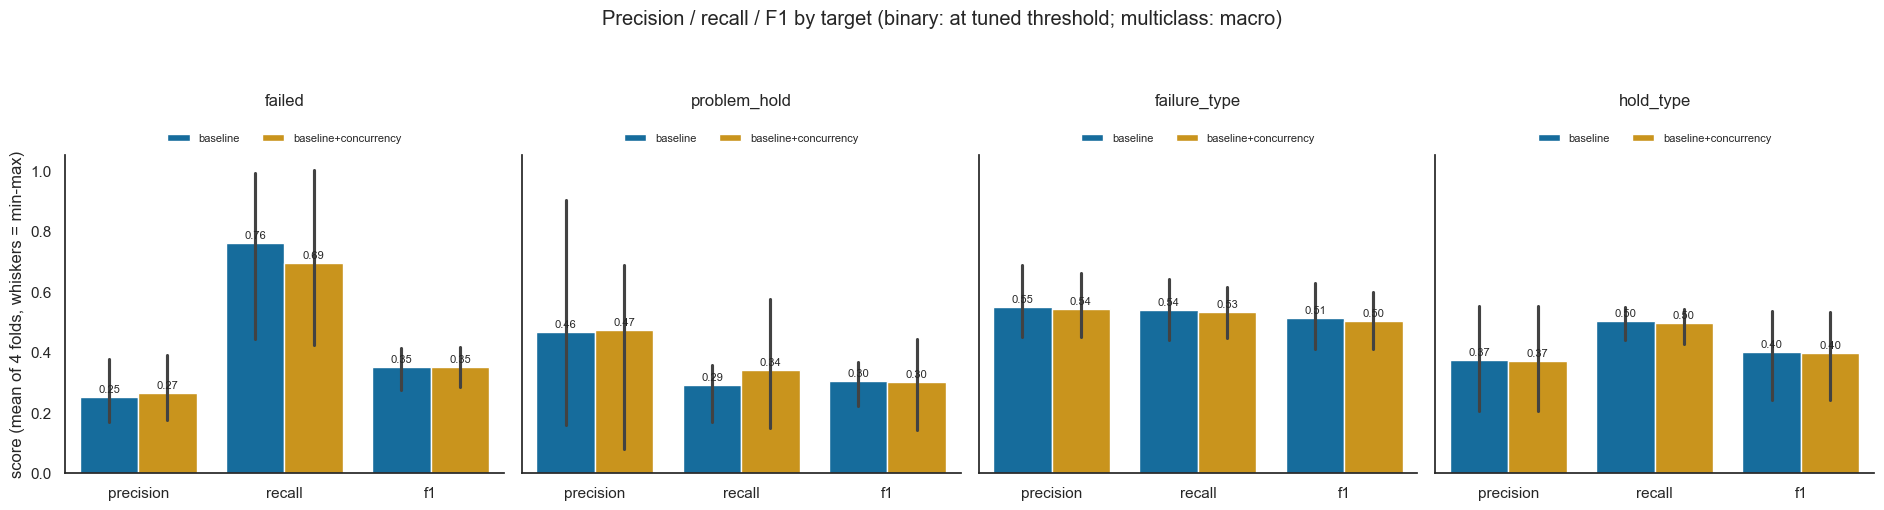

In [8]:
PAL_FS = {"baseline": "#0072B2", "baseline+concurrency": "#E69F00"}
TARGET_ORDER = ["failed", "problem_hold", "failure_type", "hold_type"]

fig, axes = plt.subplots(1, 4, figsize=(19, 4.8), sharey=True)
for ax, tname in zip(axes, TARGET_ORDER):
    if tname in ("failed", "problem_hold"):
        d = bin2[bin2.target == tname].melt(
            id_vars=["features", "test_month"],
            value_vars=["precision", "recall", "f1"], var_name="metric", value_name="value")
    else:
        d = multi2[multi2.target == tname].melt(
            id_vars=["features", "test_month"],
            value_vars=["macro_precision", "macro_recall", "macro_f1"],
            var_name="metric", value_name="value")
        d["metric"] = d["metric"].str.replace("macro_", "")
    sns.barplot(data=d, x="metric", y="value", hue="features", palette=PAL_FS,
                errorbar=lambda v: (v.min(), v.max()), ax=ax)
    for cont in ax.containers:
        ax.bar_label(cont, fmt="%.2f", padding=2, fontsize=8)
    ax.set_title(tname, pad=36)
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.005), ncol=2, frameon=False, fontsize=8)
    ax.set_xlabel("")
    ax.set_ylim(0, 1.05)
axes[0].set_ylabel("score (mean of 4 folds, whiskers = min-max)")
sns.despine()
plt.suptitle("Precision / recall / F1 by target (binary: at tuned threshold; multiclass: macro)",
             y=1.06)
plt.tight_layout()
plt.show()

### Cell: confusion matrices (pooled out-of-fold, baseline+concurrency)

Rows are the true class, columns the predicted class. Left panel: raw job counts. Right panel:
each row divided by its total, so the diagonal is that class's recall and off-diagonal cells
show where its members leak. Built from the pooled out-of-fold predictions, so every Mar-Jun job
appears exactly once, predicted by a model that never trained on its month.

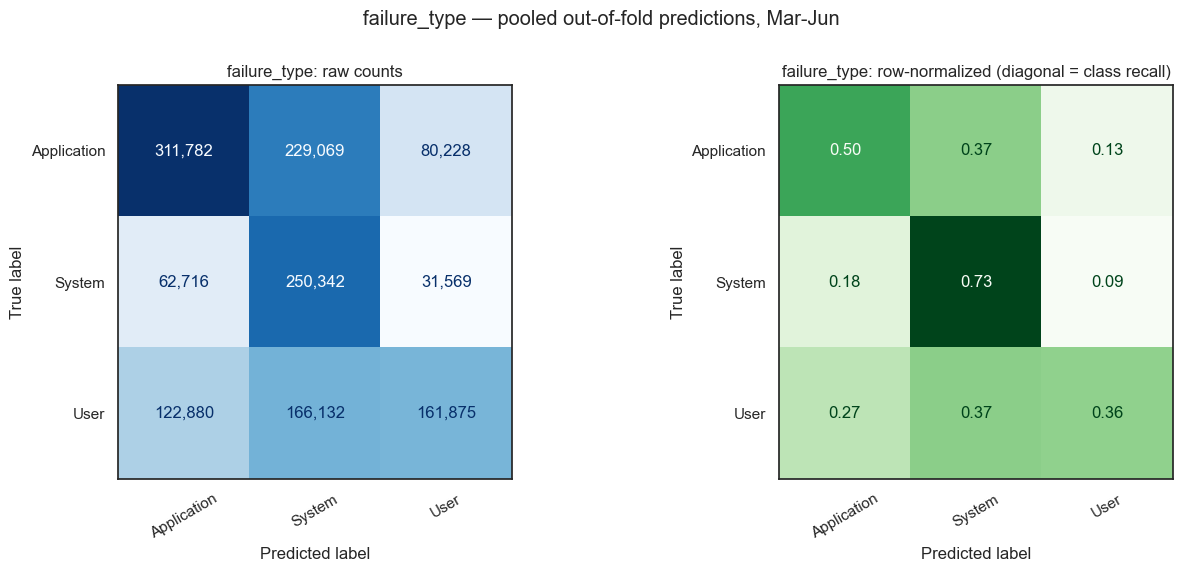

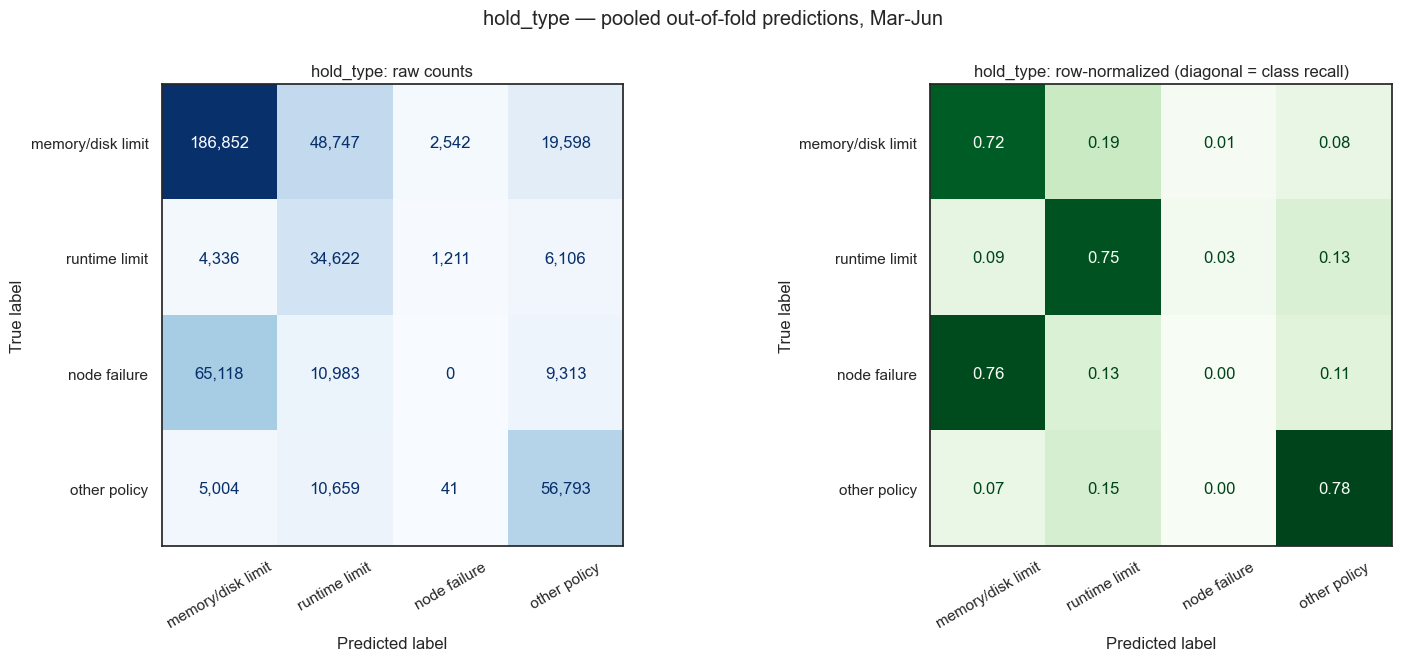

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

for tname, names in [("failure_type", FTYPE_NAMES), ("hold_type", HOLD_NAMES)]:
    y_pool = pooled[(tname, "baseline+concurrency")]["y"]
    pred_pool = pooled[(tname, "baseline+concurrency")]["p"].argmax(axis=1)
    cm = confusion_matrix(y_pool, pred_pool, labels=range(len(names)))
    cmn = confusion_matrix(y_pool, pred_pool, labels=range(len(names)), normalize="true")
    fig, ax = plt.subplots(1, 2, figsize=(7 + 2.2 * len(names), 3 + 0.9 * len(names)))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=names).plot(
        ax=ax[0], cmap="Blues", values_format=",d", xticks_rotation=30, colorbar=False)
    ax[0].set_title(f"{tname}: raw counts")
    ConfusionMatrixDisplay(confusion_matrix=cmn, display_labels=names).plot(
        ax=ax[1], cmap="Greens", values_format=".2f", xticks_rotation=30, colorbar=False)
    ax[1].set_title(f"{tname}: row-normalized (diagonal = class recall)")
    plt.suptitle(f"{tname} — pooled out-of-fold predictions, Mar-Jun", y=1.0)
    plt.tight_layout()
    plt.show()

### Cell: ROC curves (pooled out-of-fold)

A ROC curve sweeps the decision threshold from high to low and plots, at each point, the true
positive rate (recall) against the false positive rate. The area under it (AUC) is the
probability that a randomly chosen positive gets a higher score than a randomly chosen negative
— 0.5 is coin-flipping, 1.0 is perfect ranking. For the binary targets both feature sets are
drawn; for the multiclass targets each class gets a one-vs-rest curve (that class as positive,
all others as negative) from the baseline+concurrency model. Curves are downsampled for drawing
speed; the AUCs in the legends are computed on the full data.

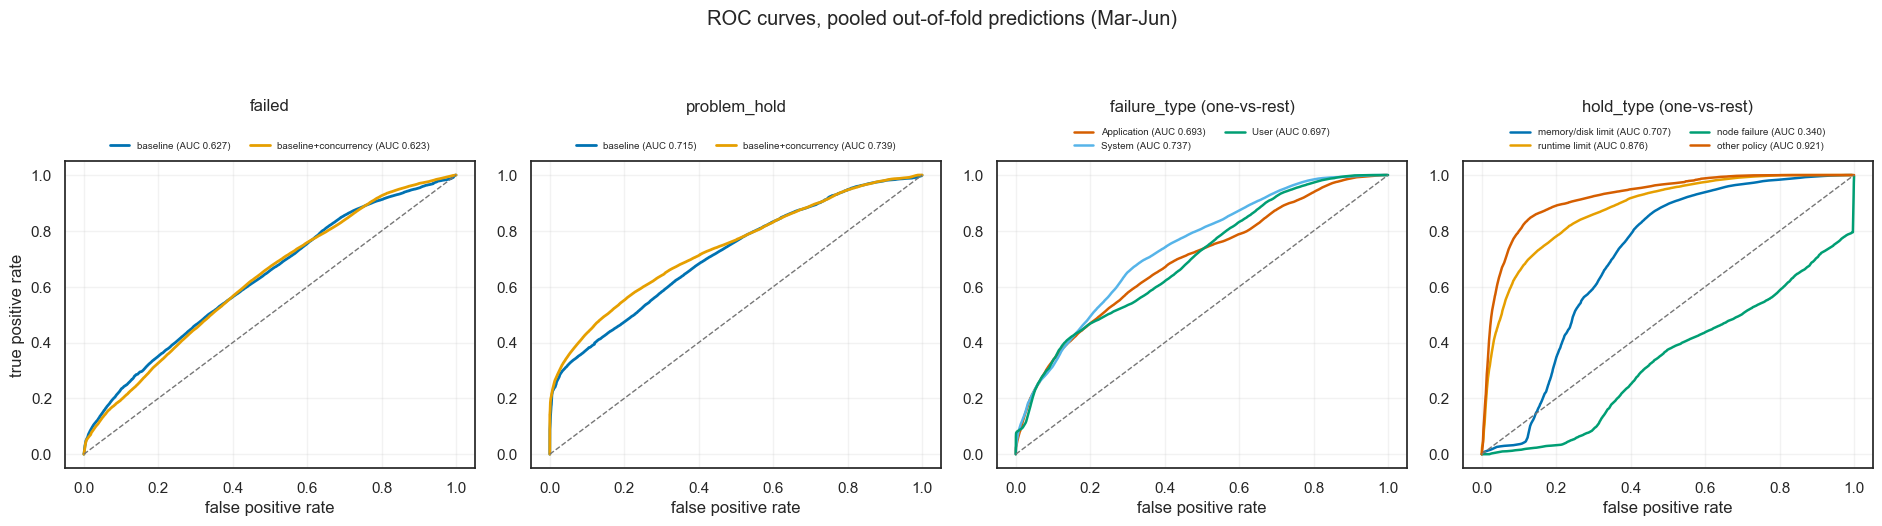

In [10]:
from sklearn.metrics import roc_curve, auc

PAL_FTYPE = {"Application": "#D55E00", "Hardware": "#56B4E9", "Submission": "#009E73"}
PAL_HOLD = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#56B4E9"]

fig, axes = plt.subplots(1, 4, figsize=(19, 4.9))
for ax, tname in zip(axes[:2], ["failed", "problem_hold"]):
    for fs_name in ["baseline", "baseline+concurrency"]:
        y_pool = pooled[(tname, fs_name)]["y"]
        p_pool = pooled[(tname, fs_name)]["p"]
        fpr, tpr, _ = roc_curve(y_pool, p_pool)
        ax.plot(fpr[::300], tpr[::300], lw=2, color=PAL_FS[fs_name],
                label=f"{fs_name} (AUC {auc(fpr, tpr):.3f})")
    ax.set_title(tname, pad=36)

for ax, (tname, names, pal) in zip(axes[2:], [("failure_type", FTYPE_NAMES, None),
                                              ("hold_type", HOLD_NAMES, PAL_HOLD)]):
    y_pool = pooled[(tname, "baseline+concurrency")]["y"]
    p_pool = pooled[(tname, "baseline+concurrency")]["p"]
    for k, cname in enumerate(names):
        y_k = (y_pool == k).astype(np.int8)
        fpr, tpr, _ = roc_curve(y_k, p_pool[:, k])
        color = PAL_FTYPE[cname] if pal is None else pal[k]
        ax.plot(fpr[::300], tpr[::300], lw=1.8, color=color,
                label=f"{cname} (AUC {auc(fpr, tpr):.3f})")
    ax.set_title(f"{tname} (one-vs-rest)", pad=36)

for ax in axes:
    ax.plot([0, 1], [0, 1], "--", color="#767676", lw=1)
    ax.set_xlabel("false positive rate")
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.005), ncol=2, frameon=False,
              fontsize=7)
    ax.grid(alpha=0.25)
axes[0].set_ylabel("true positive rate")
plt.suptitle("ROC curves, pooled out-of-fold predictions (Mar-Jun)", y=1.07)
plt.tight_layout()
plt.show()

### Cell: training-loss curves

Each line is one final model's loss on a fixed 500k-row sample of its own training data, recorded
after every boosting round — logloss for the binary targets, mlogloss for the multiclass ones
(lower is better; these measure fit to the *training* months, not test performance). Four lines
per color: one per rolling-origin fold, with the fold's test month labeled at the line's end.
Read them for two things: (1) all curves should decrease smoothly — spikes or plateaus would
indicate an optimization problem; (2) curves still falling steeply at round 200 suggest more
rounds could fit the training window better, which — per the hyperparameter experiment below —
does not necessarily transfer to the next month.

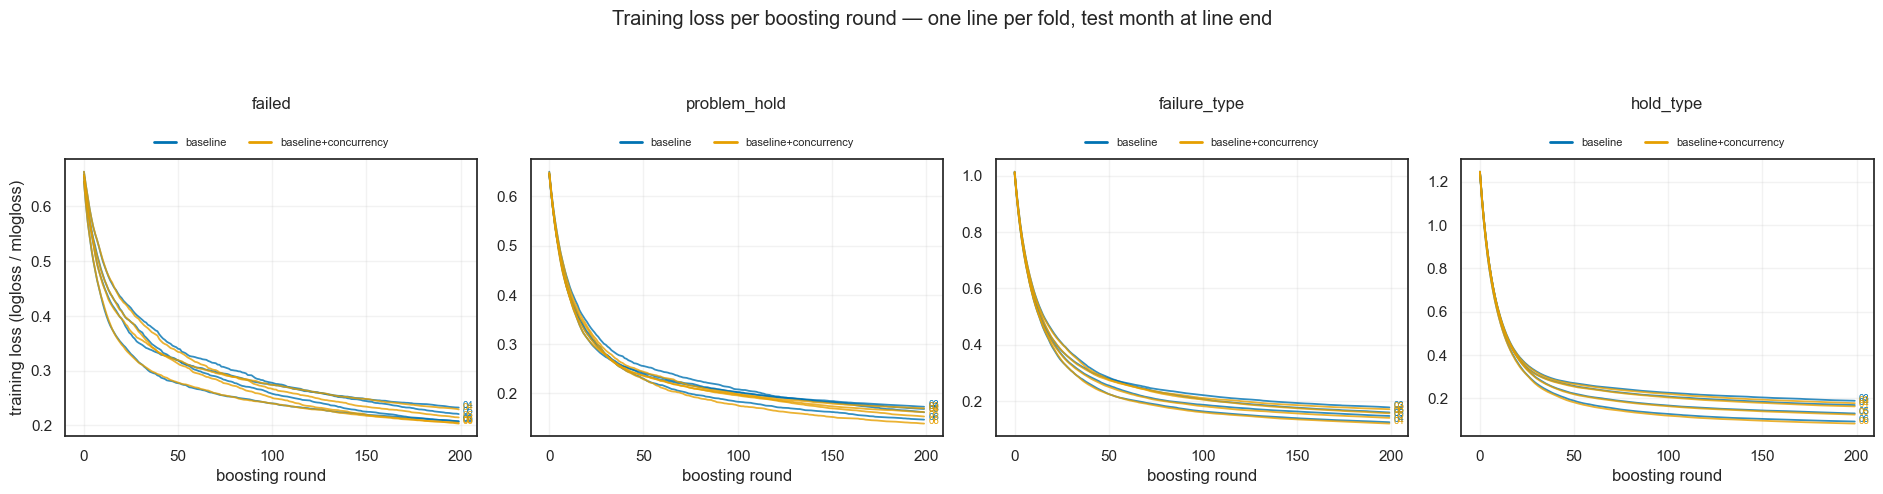

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(19, 4.6), sharex=True)
for ax, tname in zip(axes, TARGET_ORDER):
    for fs_name in ["baseline", "baseline+concurrency"]:
        for (_, _), tm in [((0, 0), t) for t in [3, 4, 5, 6]]:
            loss = loss_curves[(tname, fs_name, tm)]
            ax.plot(loss, color=PAL_FS[fs_name], lw=1.3, alpha=0.8)
            ax.annotate(f"{tm:02d}", (len(loss) - 1, loss[-1]), fontsize=7,
                        color=PAL_FS[fs_name], xytext=(3, 0), textcoords="offset points")
    ax.set_title(tname, pad=36)
    handles = [plt.Line2D([], [], color=PAL_FS[f], lw=2, label=f) for f in PAL_FS]
    ax.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, 1.005), ncol=2,
              frameon=False, fontsize=8)
    ax.set_xlabel("boosting round")
    ax.grid(alpha=0.25)
axes[0].set_ylabel("training loss (logloss / mlogloss)")
plt.suptitle("Training loss per boosting round — one line per fold, test month at line end",
             y=1.07)
plt.tight_layout()
plt.show()

### Cell: split-protocol decomposition, now campaign-aware

Same model and features, same test-set size, three split rules for the training/test boundary:

- **random** — rows shuffled uniformly; test jobs share batches, campaigns, and months with
  training jobs.
- **campaign-aware random** — whole *campaigns* are assigned to one side (production jobs are
  grouped by `POMS4_CAMPAIGN_ID`; user jobs, which have no campaign, fall back to their
  submission batch `ClusterId`). No campaign or batch straddles the boundary, so the model can
  never score a test job by having memorized its campaign siblings — but test months' overall
  conditions still appear in training.
- **temporal** — train Jan-Apr, test May-Jun; nothing from the test period is available.

The drop from random to campaign-aware measures how much of the random split's optimism is
campaign/batch memorization; the drop from campaign-aware to temporal measures genuine time
drift. Whole-campaign grouping makes the two random splits' train/test sizes differ slightly
from the target (campaigns are indivisible); sizes are printed for transparency.

random                 problem_hold  PR-AUC 0.881  ROC-AUC 0.981


random                 failed        PR-AUC 0.895  ROC-AUC 0.964


campaign-aware random  problem_hold  PR-AUC 0.731  ROC-AUC 0.928


campaign-aware random  failed        PR-AUC 0.750  ROC-AUC 0.893


temporal               problem_hold  PR-AUC 0.377  ROC-AUC 0.707


temporal               failed        PR-AUC 0.343  ROC-AUC 0.736



             protocol       target  n_train  n_test  base_rate  pr_auc  roc_auc
               random problem_hold  8192260 4131713      0.063   0.881    0.981
               random       failed  8192260 4131713      0.187   0.895    0.964
campaign-aware random problem_hold  8192259 4131714      0.050   0.731    0.928
campaign-aware random       failed  8192259 4131714      0.200   0.750    0.893
             temporal problem_hold  8192260 4131713      0.065   0.377    0.707
             temporal       failed  8192260 4131713      0.197   0.343    0.736


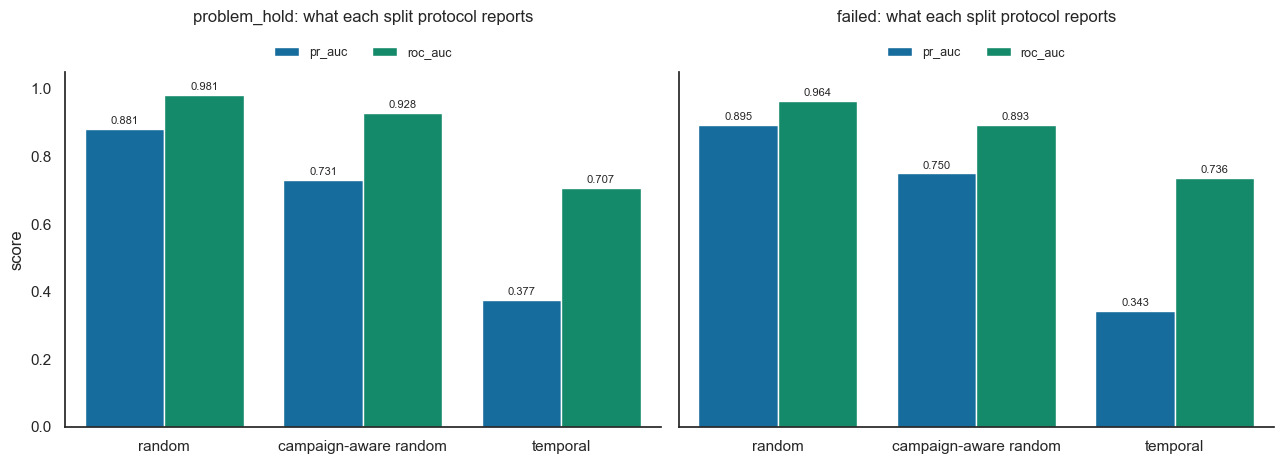

CPU times: user 23min 16s, sys: 24.4 s, total: 23min 40s
Wall time: 3min 47s


In [12]:
%%time
n_test_t = int((month2 >= 5).sum())
rng = np.random.default_rng(42)

splits2 = {"temporal": (np.where(month2 <= 4)[0], np.where(month2 >= 5)[0])}
perm = rng.permutation(len(month2))
splits2["random"] = (perm[n_test_t:], perm[:n_test_t])

counts = np.bincount(gkey)
order = rng.permutation(len(counts))
k = int(np.searchsorted(np.cumsum(counts[order]), n_test_t))
test_flag = np.zeros(len(counts), dtype=bool)
test_flag[order[:k + 1]] = True
mask = test_flag[gkey]
splits2["campaign-aware random"] = (np.where(~mask)[0], np.where(mask)[0])

proto_rows = []
for pname in ["random", "campaign-aware random", "temporal"]:
    tr, te = splits2[pname]
    for tname in ["problem_hold", "failed"]:
        y = y2[tname]
        spw = float((y[tr] == 0).sum() / max((y[tr] == 1).sum(), 1))
        m = XGBClassifier(eval_metric="logloss", scale_pos_weight=spw, **XGB_KW2)
        m.fit(X2[tr], y[tr])
        p = m.predict_proba(X2[te])[:, 1]
        proto_rows.append({"protocol": pname, "target": tname,
                           "n_train": len(tr), "n_test": len(te),
                           "base_rate": float(y[te].mean()),
                           "pr_auc": average_precision_score(y[te], p),
                           "roc_auc": roc_auc_score(y[te], p)})
        print(f"{pname:22s} {tname:13s} PR-AUC {proto_rows[-1]['pr_auc']:.3f}  "
              f"ROC-AUC {proto_rows[-1]['roc_auc']:.3f}", flush=True)
        del m
        gc.collect()

proto2 = pd.DataFrame(proto_rows)
print()
print(proto2.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

PAL_METRIC = {"pr_auc": "#0072B2", "roc_auc": "#009E73"}
PROTO_ORDER = ["random", "campaign-aware random", "temporal"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
for ax, tname in zip(axes, ["problem_hold", "failed"]):
    d = (proto2[proto2.target == tname]
         .melt(id_vars=["protocol"], value_vars=["pr_auc", "roc_auc"],
               var_name="metric", value_name="value"))
    sns.barplot(data=d, x="protocol", y="value", hue="metric", order=PROTO_ORDER,
                palette=PAL_METRIC, ax=ax)
    for cont in ax.containers:
        ax.bar_label(cont, fmt="%.3f", padding=2, fontsize=8)
    ax.set_title(f"{tname}: what each split protocol reports", pad=36)
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.005), ncol=2, frameon=False, fontsize=9)
    ax.set_xlabel("")
    ax.set_ylim(0, 1.05)
axes[0].set_ylabel("score")
sns.despine()
plt.tight_layout()
plt.show()

### Expanded-benchmark verdict

*(superseded by the model comparison below)*

## Model comparison: XGBoost vs CatBoost vs LightGBM (campaign-aware split)

The pre-GPU benchmark. What this section fixes in place:

- **Split**: a single campaign-aware random split (whole campaigns — batches for user jobs — go
  to train or test; seeded; test ≈ one third of jobs). As measured above, this protocol removes
  campaign memorization but still shares time periods between train and test, so scores are
  *within-period* estimates — higher than rolling-origin numbers would be. It is the agreed
  protocol for this comparison; the GPU runs will use the same split rule.
- **Features**: the full expanded set (match-time audit columns, `stage_type`, cyclical clocks,
  `proxy_hours_left`). The two settings differ **only in the concurrency features** — cyclical
  and campaign-type features are in both, so the labels just read `baseline` and
  `baseline+concurrency`.
- **Targets**: all four, with the revised labels defined above.
- **Models**: XGBoost, CatBoost, LightGBM, matched where the libraries allow (200 trees, depth 8,
  learning rate 0.1). Binary targets use `scale_pos_weight`; multiclass targets use balanced
  per-class sample weights. All categorical features are integer-coded the same way for all
  three libraries, so no library gets a categorical-handling advantage.
- Binary metrics: PR-AUC / ROC-AUC (threshold-free) plus precision/recall/F1 at the default 0.5
  (no calibration month exists inside a random split — thresholds would be tuned on a
  campaign-aware carve-out in deployment). Multiclass metrics: macro precision/recall/F1 and
  one-vs-rest ROC-AUC. Models are saved to `../models/hold-failure/` as
  `{lib}_{target}_{features}.{ext}`, replacing the fold models.

In [7]:
%%time
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             precision_recall_fscore_support)

MODELS_DIR = "../models/hold-failure"
os.makedirs(MODELS_DIR, exist_ok=True)

# campaign-aware split, seeded: whole groups into train or test
rng = np.random.default_rng(42)
n_test_t = int(len(month2) / 3)
counts = np.bincount(gkey)
order = rng.permutation(len(counts))
kk = int(np.searchsorted(np.cumsum(counts[order]), n_test_t))
tflag = np.zeros(len(counts), dtype=bool)
tflag[order[:kk + 1]] = True
te_mask = tflag[gkey]
TR, TE = np.where(~te_mask)[0], np.where(te_mask)[0]
print(f"train {len(TR):,}  test {len(TE):,} (campaign-aware)")


def make_model(lib, task, spw=None):
    if lib == "xgboost":
        kw = dict(tree_method="hist", n_estimators=200, max_depth=8, learning_rate=0.1,
                  n_jobs=-1, eval_metric="logloss" if task == "binary" else "mlogloss")
        if spw is not None:
            kw["scale_pos_weight"] = spw
        return XGBClassifier(**kw)
    if lib == "lightgbm":
        kw = dict(n_estimators=200, num_leaves=255, max_depth=8, learning_rate=0.1,
                  n_jobs=-1, verbose=-1)
        if spw is not None:
            kw["scale_pos_weight"] = spw
        return LGBMClassifier(**kw)
    kw = dict(iterations=200, depth=8, learning_rate=0.1, thread_count=-1, verbose=False,
              allow_writing_files=False, random_seed=42,
              loss_function="Logloss" if task == "binary" else "MultiClass")
    if spw is not None:
        kw["scale_pos_weight"] = spw
    return CatBoostClassifier(**kw)


def save_model(m, lib, path_base):
    if lib == "xgboost":
        m.save_model(path_base + ".ubj")
    elif lib == "lightgbm":
        m.booster_.save_model(path_base + ".txt")
    else:
        m.save_model(path_base + ".cbm")


MULTI2 = {"failure_type": (y_ftype, FTYPE_NAMES), "hold_type": (y_htype, HOLD_NAMES)}

# training-loss capture: one curve per (target, library), recorded only on the
# baseline+concurrency setting. Each boosting round the model scores a fixed 500k-row
# sample of the TRAINING split, so the curves show optimization progress on comparable
# data, not test performance.
LOSS_EVAL_N = 500_000
rng_loss = np.random.default_rng(7)
cmp_loss = {}


def extract_loss(m, lib):
    if lib == "xgboost":
        r = m.evals_result()["validation_0"]
    elif lib == "lightgbm":
        r = m.evals_result_["valid_0"]
    else:
        r = m.get_evals_result()["validation"]
    return [float(v) for v in r[next(iter(r))]]

cmp_rows, cmp_class_rows = [], []
cmp_pooled = {}
for lib in ["xgboost", "lightgbm", "catboost"]:
    for fs_name, cols in FEATURE_SETS2.items():
        fs_tag = fs_name.replace("+", "-")
        ci = np.array([ALL2.index(c) for c in cols])

        for tname in ["problem_hold", "failed"]:
            y = y2[tname]
            spw = float((y[TR] == 0).sum() / max((y[TR] == 1).sum(), 1))
            m = make_model(lib, "binary", spw)
            if fs_name == "baseline+concurrency":
                ev = rng_loss.choice(TR, size=min(LOSS_EVAL_N, len(TR)), replace=False)
                fit_kw = {} if lib == "lightgbm" else {"verbose": False}
                m.fit(X2[np.ix_(TR, ci)], y[TR],
                      eval_set=[(X2[np.ix_(ev, ci)], y[ev])], **fit_kw)
                cmp_loss[(tname, lib)] = extract_loss(m, lib)
            else:
                m.fit(X2[np.ix_(TR, ci)], y[TR])
            p = np.asarray(m.predict_proba(X2[np.ix_(TE, ci)]))[:, 1]
            yp = (p >= 0.5).astype(np.int8)
            pr_, rc_, f1_, _ = precision_recall_fscore_support(y[TE], yp, average="binary",
                                                               zero_division=0)
            cmp_rows.append({"model": lib, "features": fs_name, "target": tname,
                             "base_rate": float(y[TE].mean()),
                             "pr_auc": average_precision_score(y[TE], p),
                             "roc_auc": roc_auc_score(y[TE], p),
                             "precision": pr_, "recall": rc_, "f1": f1_})
            if fs_name == "baseline+concurrency":
                cmp_pooled[(tname, lib)] = (y[TE], p.astype(np.float32))
            save_model(m, lib, f"{MODELS_DIR}/{lib}_{tname}_{fs_tag}")
            del m
            gc.collect()

        for tname, (yt, names) in MULTI2.items():
            K = len(names)
            trm = TR[yt[TR] >= 0]
            tem = TE[yt[TE] >= 0]
            y_tr3, y_te3 = yt[trm].astype(np.int64), yt[tem].astype(np.int64)
            cw = len(y_tr3) / (K * np.bincount(y_tr3, minlength=K).astype(float))
            m = make_model(lib, "multi")
            if fs_name == "baseline+concurrency":
                evi = rng_loss.choice(len(trm), size=min(LOSS_EVAL_N, len(trm)), replace=False)
                fit_kw = {} if lib == "lightgbm" else {"verbose": False}
                m.fit(X2[np.ix_(trm, ci)], y_tr3, sample_weight=cw[y_tr3],
                      eval_set=[(X2[np.ix_(trm[evi], ci)], y_tr3[evi])], **fit_kw)
                cmp_loss[(tname, lib)] = extract_loss(m, lib)
            else:
                m.fit(X2[np.ix_(trm, ci)], y_tr3, sample_weight=cw[y_tr3])
            p3 = np.asarray(m.predict_proba(X2[np.ix_(tem, ci)]))
            pred3 = p3.argmax(axis=1)
            mp, mr, mf, _ = precision_recall_fscore_support(y_te3, pred3, average="macro",
                                                            zero_division=0)
            aucs = [roc_auc_score((y_te3 == k).astype(np.int8), p3[:, k])
                    for k in range(K) if 0 < (y_te3 == k).sum() < len(y_te3)]
            cmp_rows.append({"model": lib, "features": fs_name, "target": tname,
                             "base_rate": np.nan, "pr_auc": np.nan, "roc_auc": float(np.mean(aucs)),
                             "precision": mp, "recall": mr, "f1": mf})
            _, _, f1k, supk = precision_recall_fscore_support(y_te3, pred3, labels=range(K),
                                                              zero_division=0)
            for k, cname in enumerate(names):
                cmp_class_rows.append({"model": lib, "features": fs_name, "target": tname,
                                       "class": cname, "f1": f1k[k], "support": int(supk[k])})
            if fs_name == "baseline+concurrency":
                cmp_pooled[(tname, lib)] = (y_te3, p3)
            save_model(m, lib, f"{MODELS_DIR}/{lib}_{tname}_{fs_tag}")
            del m
            gc.collect()
        print(f"{lib:9s} {fs_name:22s} done", flush=True)

cmp = pd.DataFrame(cmp_rows)
cmp_cls = pd.DataFrame(cmp_class_rows)
print()
print("=== model comparison (binary: at threshold 0.5; multiclass: macro) ===")
print(cmp.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

train 8,215,654  test 4,108,319 (campaign-aware)


xgboost   baseline               done


xgboost   baseline+concurrency   done


/Users/allison/anaconda3/envs/tachyon/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/Users/allison/anaconda3/envs/tachyon/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


...

/Users/allison/anaconda3/envs/tachyon/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


lightgbm  baseline+concurrency   done


catboost  baseline               done


catboost  baseline+concurrency   done



=== model comparison (binary: at threshold 0.5; multiclass: macro) ===
   model             features       target  base_rate  pr_auc  roc_auc  precision  recall    f1
 xgboost             baseline problem_hold      0.066   0.717    0.910      0.451   0.722 0.555
 xgboost             baseline       failed      0.182   0.691    0.849      0.589   0.617 0.603
 xgboost             baseline failure_type        NaN     NaN    0.907      0.674   0.737 0.692
 xgboost             baseline    hold_type        NaN     NaN    0.970      0.834   0.870 0.849
 xgboost baseline+concurrency problem_hold      0.066   0.715    0.906      0.473   0.702 0.565
 xgboost baseline+concurrency       failed      0.182   0.692    0.847      0.609   0.606 0.607
 xgboost baseline+concurrency failure_type        NaN     NaN    0.908      0.683   0.743 0.699
 xgboost baseline+concurrency    hold_type        NaN     NaN    0.970      0.835   0.872 0.850
lightgbm             baseline problem_hold      0.066   0.711   

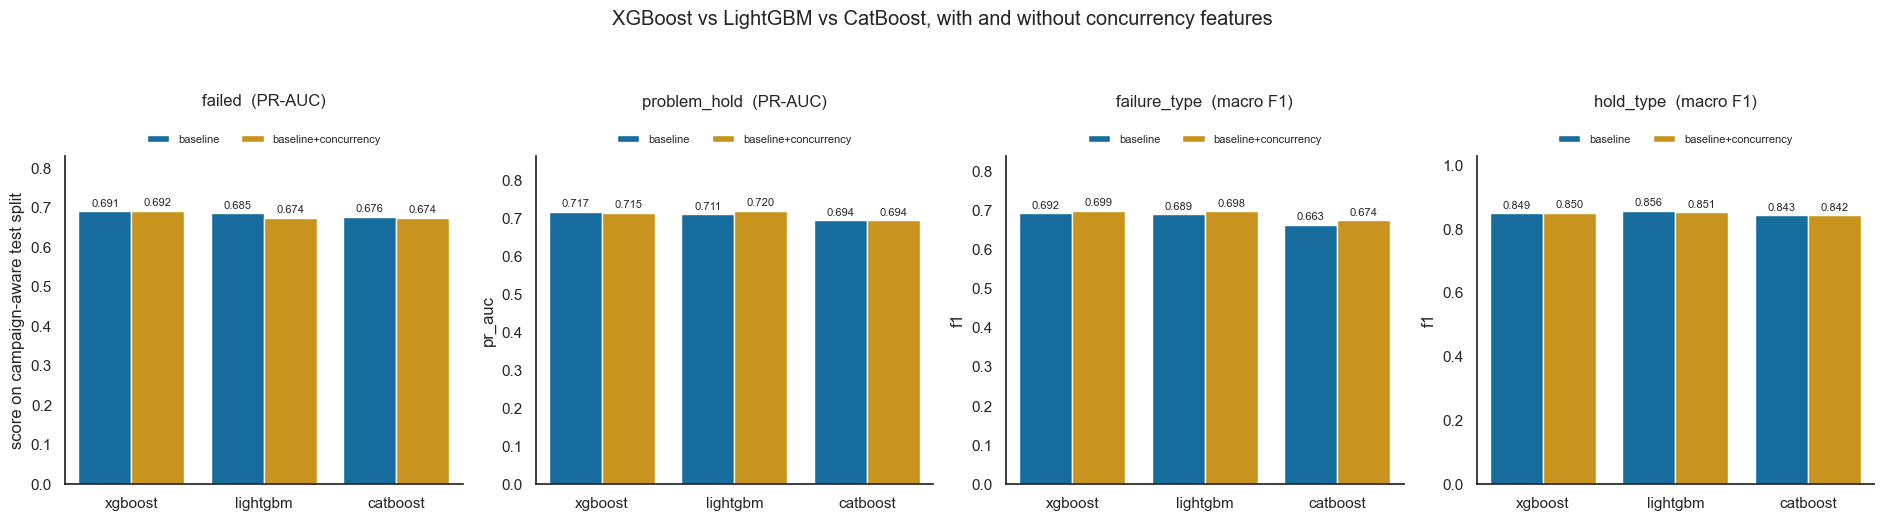

In [8]:
PAL_FS = {"baseline": "#0072B2", "baseline+concurrency": "#E69F00"}
MODEL_ORDER = ["xgboost", "lightgbm", "catboost"]

fig, axes = plt.subplots(1, 4, figsize=(19, 4.9))
for ax, tname in zip(axes, ["failed", "problem_hold", "failure_type", "hold_type"]):
    is_bin = tname in ("failed", "problem_hold")
    metric = "pr_auc" if is_bin else "f1"
    d = cmp[cmp.target == tname]
    sns.barplot(data=d, x="model", y=metric, hue="features", order=MODEL_ORDER,
                palette=PAL_FS, ax=ax)
    for cont in ax.containers:
        ax.bar_label(cont, fmt="%.3f", padding=2, fontsize=8)
    ax.set_title(f"{tname}  ({'PR-AUC' if is_bin else 'macro F1'})", pad=36)
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.005), ncol=2, frameon=False, fontsize=8)
    ax.set_xlabel("")
    ax.set_ylim(0, max(0.05, d[metric].max()) * 1.2)
axes[0].set_ylabel("score on campaign-aware test split")
sns.despine()
plt.suptitle("XGBoost vs LightGBM vs CatBoost, with and without concurrency features", y=1.06)
plt.tight_layout()
plt.show()

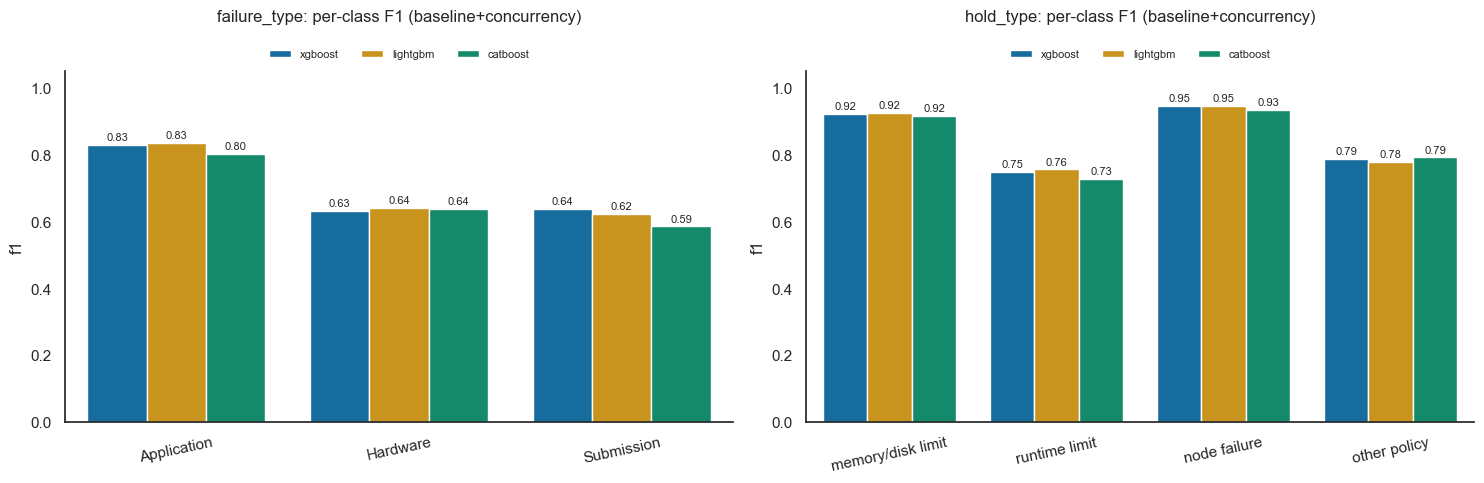

In [9]:
PAL_MODEL = {"xgboost": "#0072B2", "lightgbm": "#E69F00", "catboost": "#009E73"}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, tname in zip(axes, ["failure_type", "hold_type"]):
    d = cmp_cls[(cmp_cls.target == tname) & (cmp_cls.features == "baseline+concurrency")]
    sns.barplot(data=d, x="class", y="f1", hue="model", hue_order=MODEL_ORDER,
                palette=PAL_MODEL, ax=ax)
    for cont in ax.containers:
        ax.bar_label(cont, fmt="%.2f", padding=2, fontsize=8)
    ax.set_title(f"{tname}: per-class F1 (baseline+concurrency)", pad=36)
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.005), ncol=3, frameon=False, fontsize=8)
    ax.set_xlabel("")
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis="x", rotation=12)
sns.despine()
plt.tight_layout()
plt.show()

### Cell: precision and recall per model — binary targets

Companion to the per-class F1 bars above, for the two binary tasks. Each panel is one target
(`problem_hold`, `failed`); within a panel the bars group by metric (precision, recall) and each
bar is one library, all on the baseline+concurrency feature set at a fixed 0.5 decision
threshold. Precision is the fraction of predicted positives that really are positive; recall is
the fraction of true positives the model catches. Reading them together shows *how* each library
trades the two off at the same threshold, which a single F1 number hides.

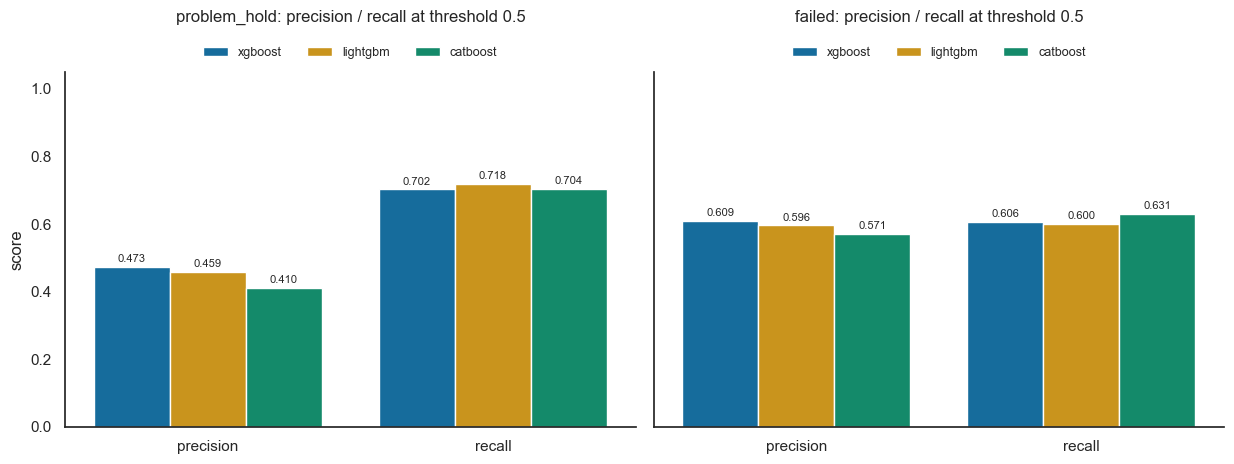

In [10]:
prc = cmp[(cmp.features == "baseline+concurrency") &
          cmp.target.isin(["problem_hold", "failed"])]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), sharey=True)
for ax, tname in zip(axes, ["problem_hold", "failed"]):
    d = (prc[prc.target == tname]
         .melt(id_vars=["model"], value_vars=["precision", "recall"],
               var_name="metric", value_name="value"))
    sns.barplot(data=d, x="metric", y="value", hue="model", hue_order=MODEL_ORDER,
                palette=PAL_MODEL, ax=ax)
    for c in ax.containers:
        ax.bar_label(c, fmt="%.3f", padding=2, fontsize=8)
    ax.set_title(f"{tname}: precision / recall at threshold 0.5", pad=36)
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.005), ncol=3, frameon=False, fontsize=9)
    ax.set_xlabel("")
    ax.set_ylim(0, 1.05)
axes[0].set_ylabel("score")
sns.despine()
plt.tight_layout()
plt.show()

### Cell: training loss per library

One panel per target; within a panel, one line per library (baseline+concurrency feature set).
Every boosting round, each model scores a fixed 500k-row sample of its training split with its
own log-loss objective (binary log loss for the two binary targets, multiclass log loss for the
two type targets), so the lines show how quickly each library's optimizer drives the objective
down under the matched budget (200 trees, depth 8, learning rate 0.1). Absolute levels are
comparable within a panel because the loss function and evaluation sample distribution are the
same; a lower curve means a better fit to training data, not necessarily better generalization —
compare against the test-set bars above for that.

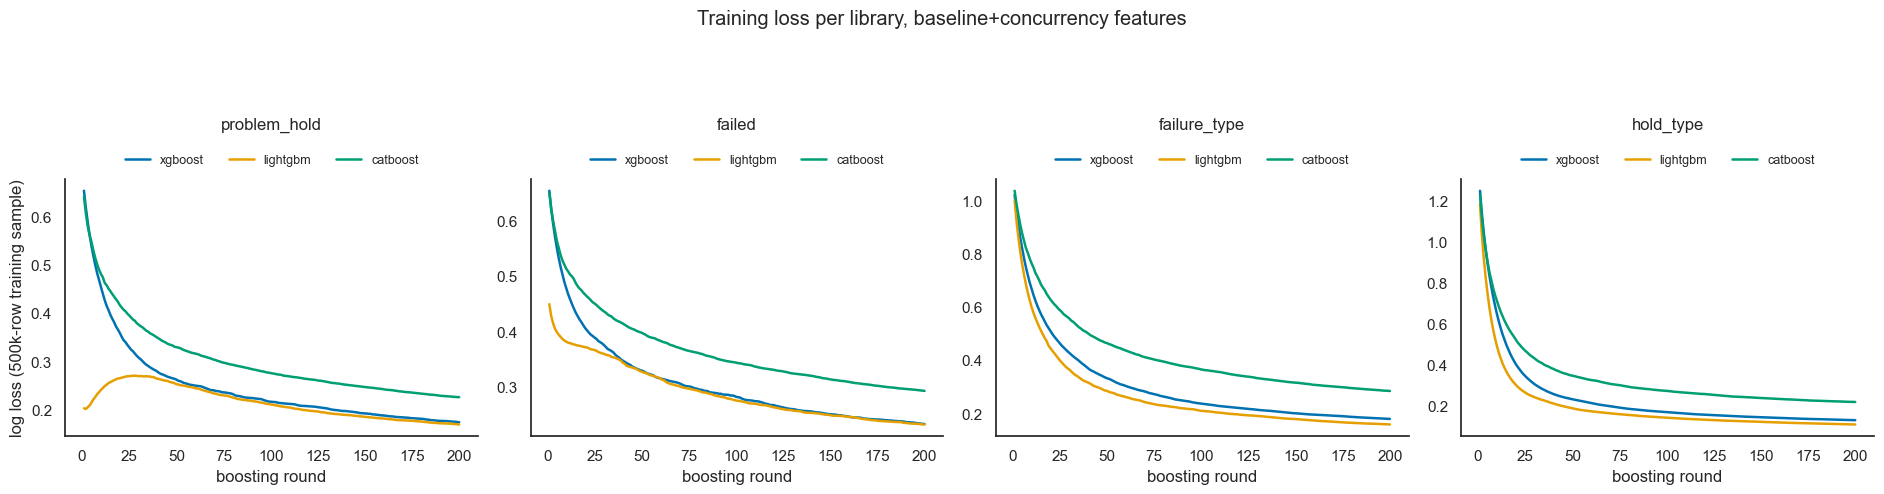

In [11]:
TARGETS_LOSS = ["problem_hold", "failed", "failure_type", "hold_type"]

fig, axes = plt.subplots(1, 4, figsize=(19, 4.4))
for ax, tname in zip(axes, TARGETS_LOSS):
    for lib in MODEL_ORDER:
        curve = cmp_loss.get((tname, lib))
        if curve is None:
            continue
        ax.plot(range(1, len(curve) + 1), curve, color=PAL_MODEL[lib], label=lib,
                linewidth=1.8)
    ax.set_title(tname, pad=36)
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.005), ncol=3, frameon=False,
              fontsize=9)
    ax.set_xlabel("boosting round")
axes[0].set_ylabel("log loss (500k-row training sample)")
sns.despine()
plt.suptitle("Training loss per library, baseline+concurrency features", y=1.12)
plt.tight_layout()
plt.show()

### Cell: confusion matrices per model

For each multiclass target, one column per library on the campaign-aware test set
(baseline+concurrency features). Top row: raw counts — cell (i, j) is the number of test jobs
whose true class is i and predicted class is j, so off-diagonal cells show exactly which classes
get mistaken for which, weighted by how often it actually happens. Bottom row: the same matrix
with each row divided by its row total, so the diagonal is per-class recall and rows are
comparable across classes with very different sizes.

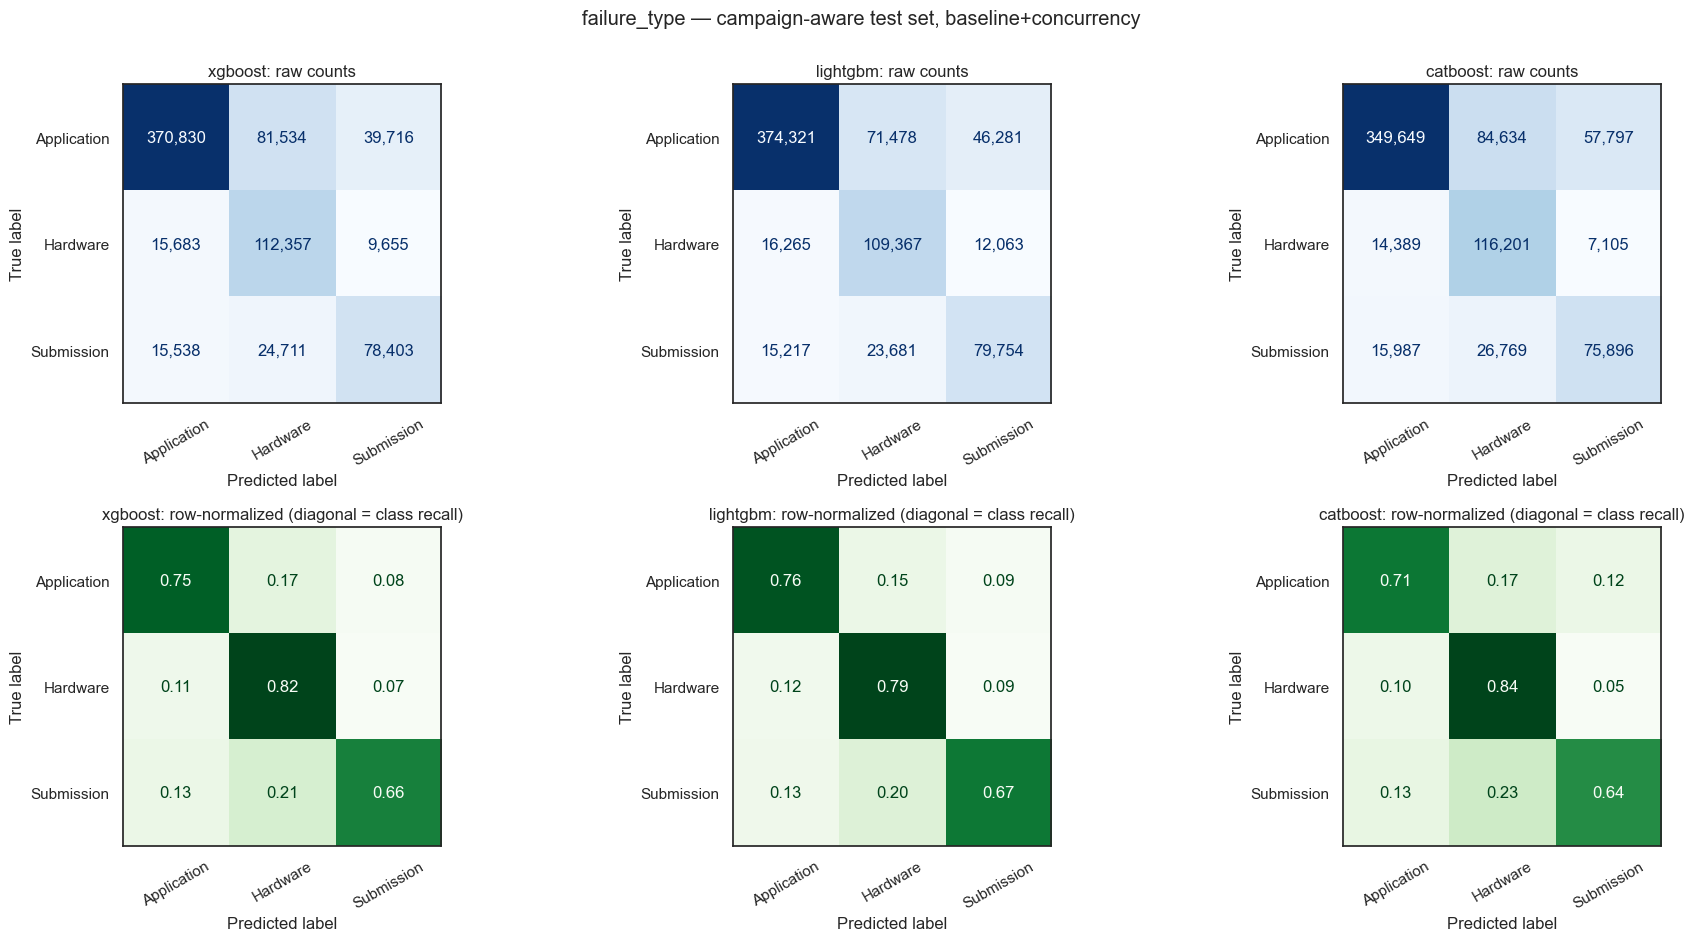

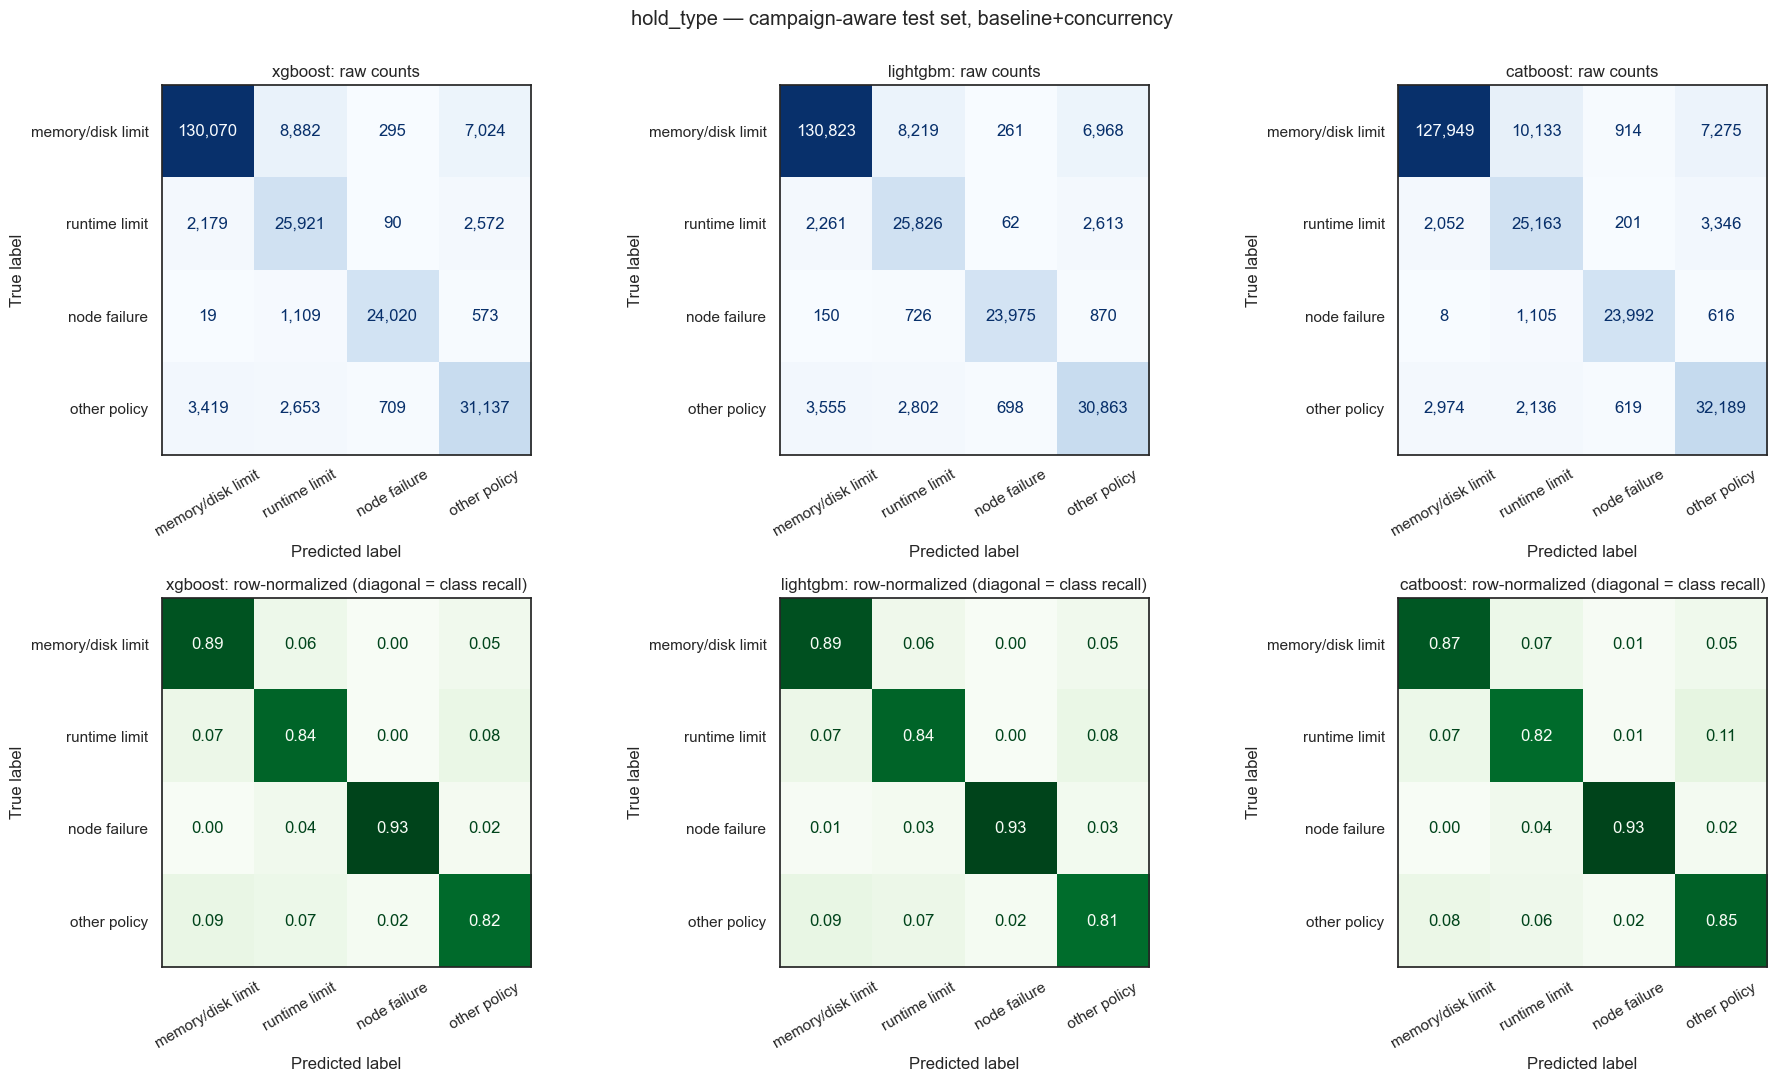

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

for tname, names in [("failure_type", FTYPE_NAMES), ("hold_type", HOLD_NAMES)]:
    K = len(names)
    fig, axes = plt.subplots(2, 3, figsize=(19, 5.2 + 1.4 * K))
    for j, lib in enumerate(MODEL_ORDER):
        y_te, p3 = cmp_pooled[(tname, lib)]
        pred = np.asarray(p3).argmax(axis=1)
        cm = confusion_matrix(y_te, pred, labels=range(K))
        cmn = confusion_matrix(y_te, pred, labels=range(K), normalize="true")
        ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=names).plot(
            ax=axes[0, j], cmap="Blues", values_format=",d", xticks_rotation=30,
            colorbar=False)
        axes[0, j].set_title(f"{lib}: raw counts")
        ConfusionMatrixDisplay(confusion_matrix=cmn, display_labels=names).plot(
            ax=axes[1, j], cmap="Greens", values_format=".2f", xticks_rotation=30,
            colorbar=False)
        axes[1, j].set_title(f"{lib}: row-normalized (diagonal = class recall)")
    plt.suptitle(f"{tname} — campaign-aware test set, baseline+concurrency", y=1.0)
    plt.tight_layout()
    plt.show()

### Cell: ROC curves

Four panels on the campaign-aware test set (baseline+concurrency features). For the two binary
targets, one curve per library — the curves nearly coincide, which is the ROC view of the
"library choice is a wash" result. For the two multiclass targets, one-vs-rest curves per class:
each class's curve treats that class as positive and everything else as negative. These are
shown for XGBoost only, since the per-class curves of the other two libraries differ by less
than the line width (OvR AUC spread < 0.01). Curves are thinned (every 300th point) purely to
keep the notebook file small; AUC values in the legends are computed on the full curves.

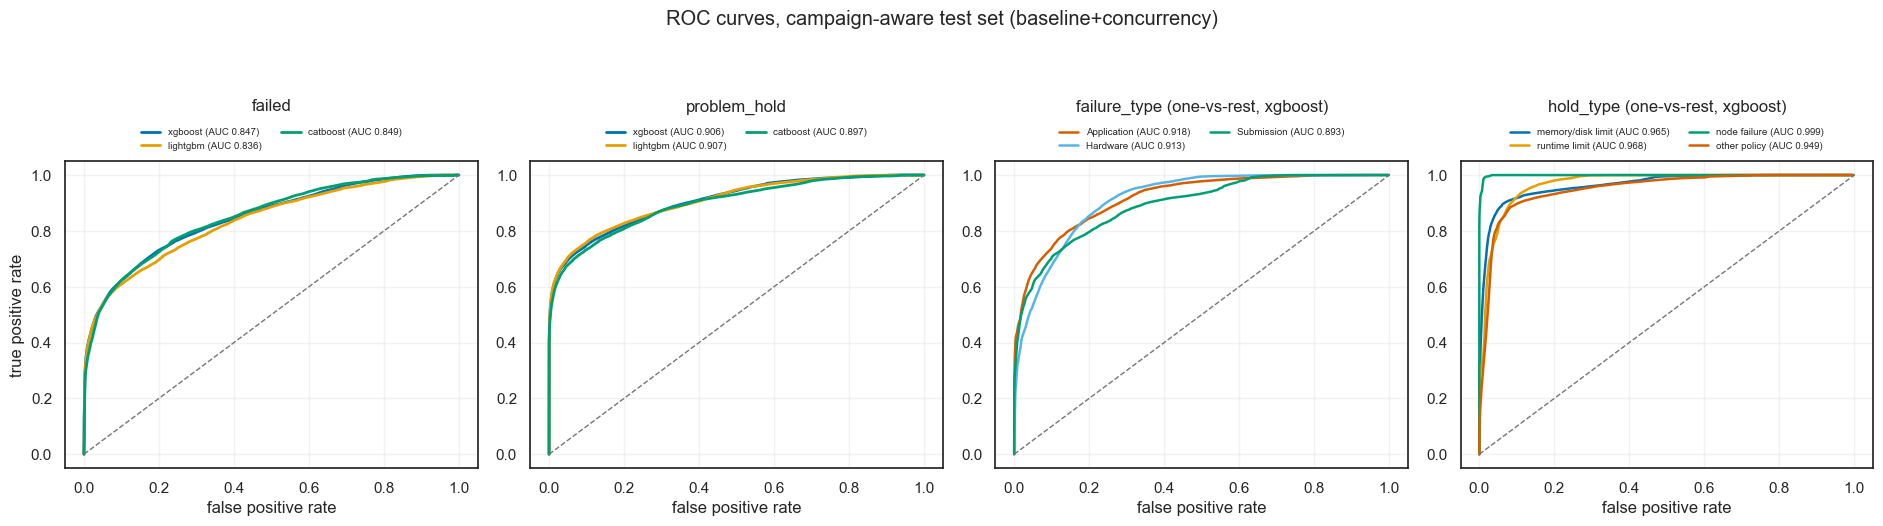

In [13]:
from sklearn.metrics import roc_curve, auc

PAL_FTYPE = {"Application": "#D55E00", "Hardware": "#56B4E9", "Submission": "#009E73"}
PAL_HOLD = ["#0072B2", "#E69F00", "#009E73", "#D55E00"]

fig, axes = plt.subplots(1, 4, figsize=(19, 4.9))
for ax, tname in zip(axes[:2], ["failed", "problem_hold"]):
    for lib in MODEL_ORDER:
        y_te, p = cmp_pooled[(tname, lib)]
        fpr, tpr, _ = roc_curve(y_te, p)
        ax.plot(fpr[::300], tpr[::300], lw=2, color=PAL_MODEL[lib],
                label=f"{lib} (AUC {auc(fpr, tpr):.3f})")
    ax.set_title(tname, pad=36)

for ax, (tname, names, pal) in zip(axes[2:], [("failure_type", FTYPE_NAMES, None),
                                              ("hold_type", HOLD_NAMES, PAL_HOLD)]):
    y_te, p3 = cmp_pooled[(tname, "xgboost")]
    p3 = np.asarray(p3)
    for k, cname in enumerate(names):
        y_k = (y_te == k).astype(np.int8)
        fpr, tpr, _ = roc_curve(y_k, p3[:, k])
        color = PAL_FTYPE[cname] if pal is None else pal[k]
        ax.plot(fpr[::300], tpr[::300], lw=1.8, color=color,
                label=f"{cname} (AUC {auc(fpr, tpr):.3f})")
    ax.set_title(f"{tname} (one-vs-rest, xgboost)", pad=36)

for ax in axes:
    ax.plot([0, 1], [0, 1], "--", color="#767676", lw=1)
    ax.set_xlabel("false positive rate")
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.005), ncol=2, frameon=False,
              fontsize=7)
    ax.grid(alpha=0.25)
axes[0].set_ylabel("true positive rate")
plt.suptitle("ROC curves, campaign-aware test set (baseline+concurrency)", y=1.07)
plt.tight_layout()
plt.show()

### Cell: decision-threshold analysis

Same construction as the discrimination-threshold chart in `baseline-prediction.ipynb`, applied
to both binary targets and all three libraries. Each panel sweeps the decision threshold from 0
to 1 and plots the precision, recall, and F1 the model would achieve on the campaign-aware test
set if positives were declared at that cutoff (from `precision_recall_curve`). The dotted gray
line marks the default 0.5 threshold used in the tables above; the dash-dot pink line marks the
threshold that maximizes F1, with its value annotated. The gap between the two lines shows how
much of the precision/recall trade-off is recoverable by tuning the cutoff alone — for
problem_hold the best-F1 threshold sits well above 0.5 because scale_pos_weight inflates the
positive scores of this 6.6%-base-rate class.

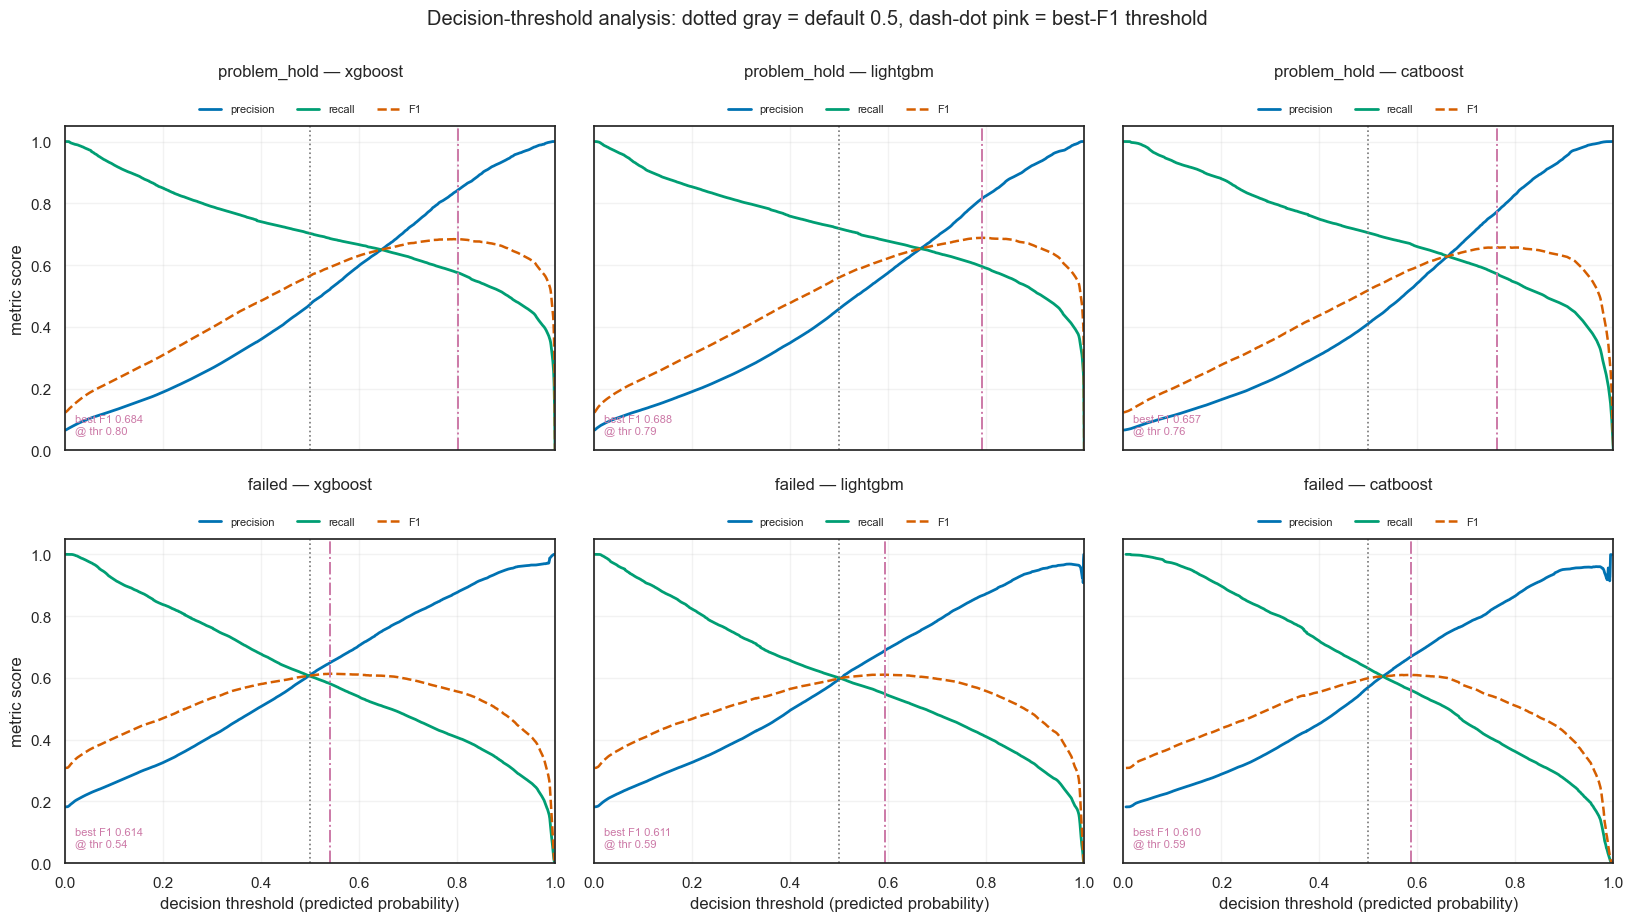

In [14]:
from sklearn.metrics import precision_recall_curve

fig, axes = plt.subplots(2, 3, figsize=(16.5, 9.2), sharex=True, sharey=True)
for r, tname in enumerate(["problem_hold", "failed"]):
    for jc, lib in enumerate(MODEL_ORDER):
        ax = axes[r, jc]
        y_te, p = cmp_pooled[(tname, lib)]
        pr, rc, th = precision_recall_curve(y_te, p)
        f1 = 2 * pr * rc / (pr + rc + 1e-10)
        step = max(1, len(th) // 2000)
        ax.plot(th[::step], pr[:-1][::step], color="#0072B2", lw=2, label="precision")
        ax.plot(th[::step], rc[:-1][::step], color="#009E73", lw=2, label="recall")
        ax.plot(th[::step], f1[:-1][::step], color="#D55E00", lw=1.8, ls="--", label="F1")
        best = int(f1[:-1].argmax())
        ax.axvline(0.5, color="#767676", ls=":", lw=1.2)
        ax.axvline(th[best], color="#CC79A7", ls="-.", lw=1.4)
        ax.annotate(f"best F1 {f1[best]:.3f}\n@ thr {th[best]:.2f}",
                    (0.02, 0.05), xycoords="axes fraction", fontsize=8, color="#CC79A7")
        ax.set_title(f"{tname} — {lib}", pad=36)
        ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.005), ncol=3, frameon=False,
                  fontsize=8)
        ax.grid(alpha=0.25)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.05)
for ax in axes[1]:
    ax.set_xlabel("decision threshold (predicted probability)")
for ax in axes[:, 0]:
    ax.set_ylabel("metric score")
plt.suptitle("Decision-threshold analysis: dotted gray = default 0.5, "
             "dash-dot pink = best-F1 threshold", y=1.0)
plt.tight_layout()
plt.show()

## Which features does each model rely on?

**Why `MachineAttrMachine0` and `LastRemoteHost` are not in the feature set.** They identify the
physical worker node (56,964 and 270,577 distinct values in one month). A gradient-boosted tree
has no notion of node identity — the label encoder turns each hostname into an arbitrary integer,
so the only thing a split on that integer can do is memorize "these specific host IDs failed
during the training window." Section above showed why that does not survive out-of-time: which
hosts/sites fail reshuffles month to month (per-site node-fail rate correlates 0.11 between
January and June). So the raw host column is a leakage-shaped identity feature, deliberately left
out. Its *useful* content — how a host/site has been behaving recently — is what the planned
trailing state features will extract, using the host column as an aggregation **key** rather than
a model input.

**What this cell shows.** For each target and library, the model's native importance
(XGBoost/LightGBM total split gain; CatBoost prediction-values-change), normalized so each
model's importances sum to 100%. Rows are the 50 features, ordered by mean importance across all
models; columns are grouped by target, three libraries each. Read a column top-to-bottom to see
what that model leans on. Caveat for the two multiclass targets (`failure_type`, `hold_type`):
gain importance is **global across the classes**, so it tells you which features drive the
hold-type model overall, not which features specifically flag the *node-failure* class — a
per-class attribution (one-vs-rest or SHAP) is deferred to the state-feature experiment, where
node failure is the class we are trying to move.

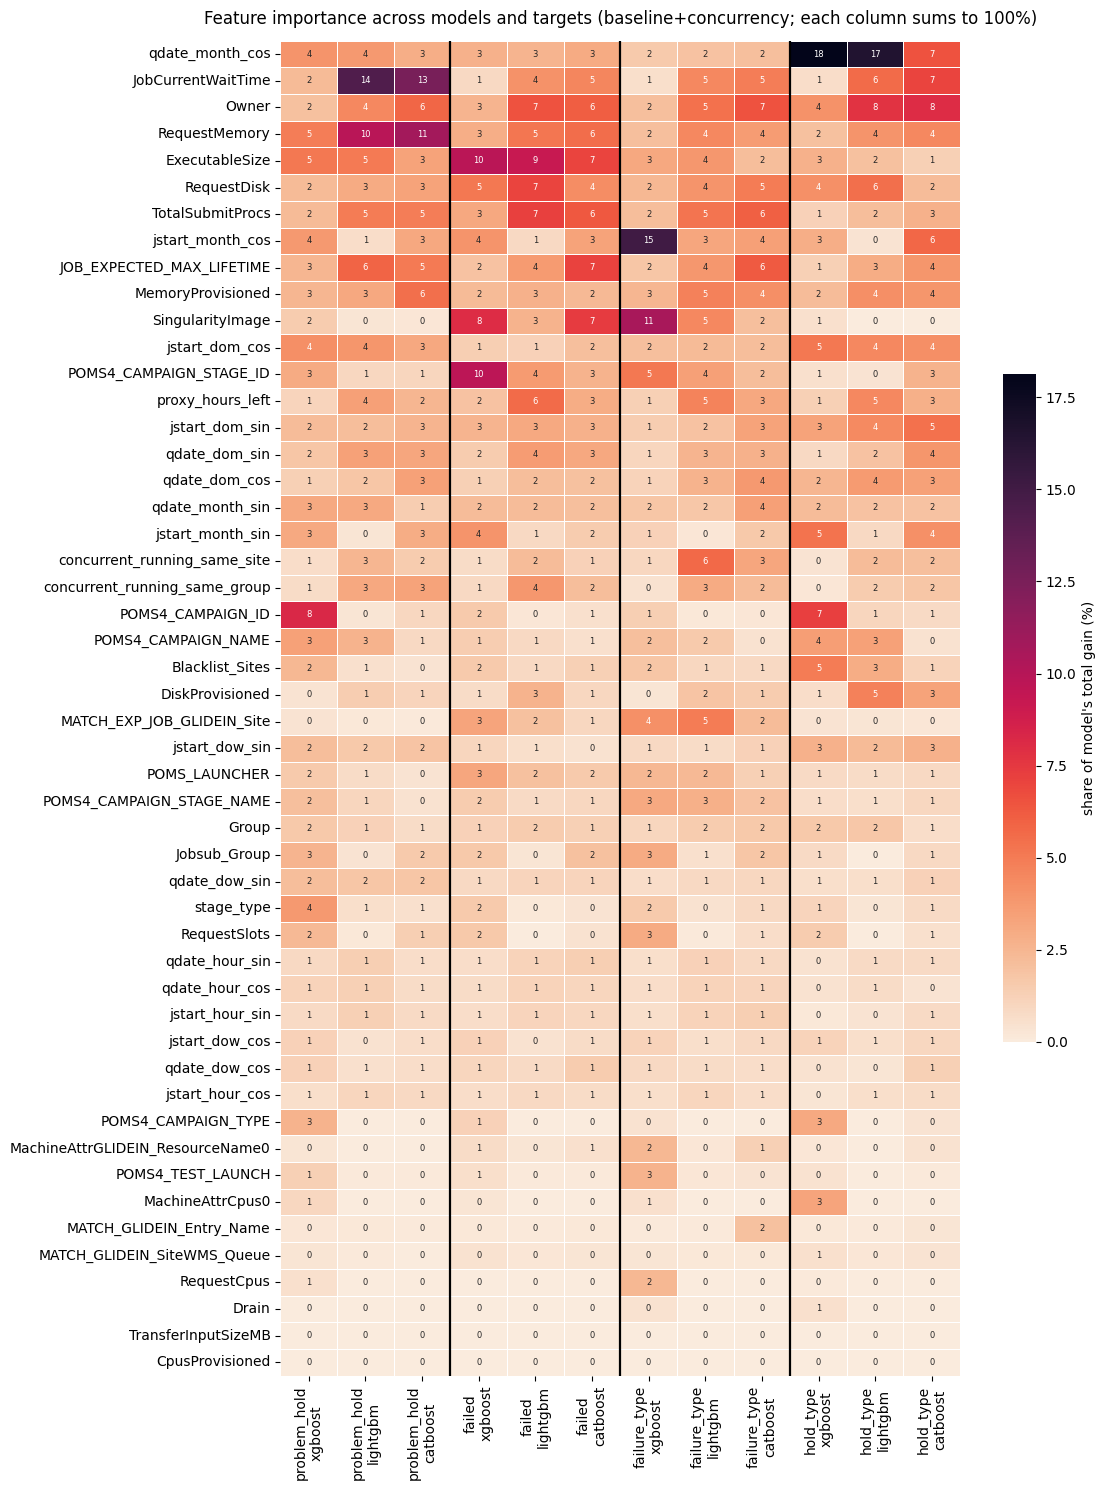

Top 5 features per model for hold_type (node failure is one of its 4 classes):
  xgboost   qdate_month_cos 18%, POMS4_CAMPAIGN_ID 7%, jstart_month_sin 5%, jstart_dom_cos 5%, Blacklist_Sites 5%
  lightgbm  qdate_month_cos 17%, Owner 8%, JobCurrentWaitTime 6%, RequestDisk 6%, DiskProvisioned 5%
  catboost  Owner 8%, JobCurrentWaitTime 7%, qdate_month_cos 7%, jstart_month_cos 6%, jstart_dom_sin 5%


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

MODELS_DIR = "../models/hold-failure"

FEAT_CAT2 = ["Group", "Owner", "POMS_LAUNCHER", "POMS4_CAMPAIGN_NAME", "POMS4_CAMPAIGN_STAGE_NAME",
             "POMS4_CAMPAIGN_ID", "POMS4_CAMPAIGN_STAGE_ID", "MATCH_EXP_JOB_GLIDEIN_Site",
             "Jobsub_Group", "SingularityImage", "POMS4_CAMPAIGN_TYPE", "POMS4_TEST_LAUNCH",
             "Drain", "MATCH_GLIDEIN_Entry_Name", "MATCH_GLIDEIN_SiteWMS_Queue",
             "MachineAttrGLIDEIN_ResourceName0", "MachineAttrCpus0", "Blacklist_Sites",
             "stage_type"]
FEAT_NUM2 = ["RequestCpus", "RequestDisk", "RequestMemory", "RequestSlots",
             "CpusProvisioned", "DiskProvisioned", "MemoryProvisioned", "ExecutableSize",
             "TransferInputSizeMB", "JOB_EXPECTED_MAX_LIFETIME", "JobCurrentWaitTime",
             "TotalSubmitProcs", "proxy_hours_left"]
CYC_COLS = [f"{t}_{p}_{tr}" for t in ["qdate", "jstart"]
            for p in ["hour", "dow", "dom", "month"] for tr in ["sin", "cos"]]
CONC_COLS = ["concurrent_running_same_site", "concurrent_running_same_group"]
ALL2 = FEAT_CAT2 + FEAT_NUM2 + CYC_COLS + CONC_COLS
NF = len(ALL2)

TARGETS = ["problem_hold", "failed", "failure_type", "hold_type"]
LIBS = ["xgboost", "lightgbm", "catboost"]


def load_importance(lib, target):
    """Native gain importance for one saved (baseline+concurrency) model, aligned to ALL2."""
    base = f"{MODELS_DIR}/{lib}_{target}_baseline-concurrency"
    imp = np.zeros(NF)
    if lib == "xgboost":
        import xgboost as xgb
        m = xgb.XGBClassifier()
        m.load_model(base + ".ubj")
        for k, v in m.get_booster().get_score(importance_type="gain").items():
            imp[int(k[1:])] = v                       # keys are f0..fN in ALL2 order
    elif lib == "lightgbm":
        import lightgbm as lgb
        bst = lgb.Booster(model_file=base + ".txt")
        imp = np.asarray(bst.feature_importance(importance_type="gain"), dtype=float)
    else:
        from catboost import CatBoostClassifier
        m = CatBoostClassifier()
        m.load_model(base + ".cbm")
        imp = np.asarray(m.get_feature_importance(), dtype=float)
    s = imp.sum()
    return imp / s if s > 0 else imp


cols = {(t, lib): load_importance(lib, t) for t in TARGETS for lib in LIBS}
imp_df = pd.DataFrame(cols, index=ALL2)
imp_df.columns = pd.MultiIndex.from_tuples(imp_df.columns, names=["target", "model"])
order = imp_df.mean(axis=1).sort_values(ascending=False).index
imp_df = imp_df.loc[order]

plot_df = imp_df * 100
plot_df.columns = [f"{t}\n{lib}" for t, lib in imp_df.columns]

fig, ax = plt.subplots(figsize=(11.5, 15))
sns.heatmap(plot_df, cmap="rocket_r", annot=True, fmt=".0f", annot_kws={"size": 6},
            cbar_kws={"label": "share of model's total gain (%)", "shrink": 0.5},
            linewidths=0.4, linecolor="white", ax=ax)
for x in (3, 6, 9):
    ax.axvline(x, color="black", lw=1.6)
ax.set_title("Feature importance across models and targets "
             "(baseline+concurrency; each column sums to 100%)", pad=12)
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

print("Top 5 features per model for hold_type (node failure is one of its 4 classes):")
for lib in LIBS:
    top = imp_df[("hold_type", lib)].sort_values(ascending=False).head(5)
    print(f"  {lib:9s} " + ", ".join(f"{f} {v*100:.0f}%" for f, v in top.items()))